# <center>AI 大模型 API 快速上手指南</center>

<!-- CELL_BREAK -->

&emsp;&emsp;今天我们聚焦的是 AI 大模型 API 调用这个领域——一个在 2026 年后已经从"技术前沿"迅速演变为"刚需技能"的方向。无论是构建智能客服、开发 AI 助手，还是为产品注入生成式 AI 能力，掌握如何调用大模型 API 都已成为开发者的必修课。

&emsp;&emsp;结合当前的技术现状与实际需求，我们会重点抓住三个关键问题：<font color=red>理解 API 调用的核心概念与通用范式、看清全球大模型的真实生态与可用路径、掌握国内外平台的快速接入方法</font>。这三个问题解决好了，后续无论是切换模型、优化成本，还是应对封锁限制，都能做到心中有数。

&emsp;&emsp;为了把这些内容讲清楚，接下来我们会按照"先建立核心概念、再了解平台生态、最后动手实践"的主线展开。首先深入理解 Token、API-Key、SDK 这三个基础概念，然后看清全球 AI 模型的版图与选型逻辑，最后进入实战调用环节。这样的安排可以让我们在动手实践之前，先建立起完整的技术认知。

## <center>必要的基础知识：什么是 Token？

**Token 是大模型处理文本的基本单位**,可以简单理解为"文本片段"。大模型不是按字符或单词来处理文本的,而是将文本切分成一个个 Token。

* **Token 与字符的关系**：

    • 对于**英文**：1个 Token ≈ 4个字符,或约 0.75 个单词

    • 对于**中文**：1个 Token ≈ 1-2 个汉字（取决于分词算法）




&emsp;&emsp;举个例子：

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123104753794.png" width=50%></div>


**为什么 Token 很重要？**

**① 计费依据**：<font color=red>几乎所有官方 AI 平台（OpenAI、Anthropic、Google、DeepSeek、阿里云、智谱AI等）都按 Token 数量计费</font>,而不是按字符或请求次数。输入（prompt）和输出（completion）通常分开计价,输出Token价格更高。

**② 上下文限制**：每个模型都有最大 Token 限制。例如 GPT-5.2 支持 128K tokens,意味着输入+输出的总和不能超过这个数字。

**③ 成本控制**：理解 Token 计数可以帮你优化 prompt,避免不必要的开销。


> &emsp;**注意**：部分第三方中转平台可能采用按次数计费或打包套餐模式,但底层仍基于Token消耗,只是计费展示方式不同。


&emsp;&emsp;**如何估算 Token 数量？**

* 快速估算公式：

    * • 中文文本：字数 × 0.5 ~ 1

    * • 英文文本：字数 × 0.25
    
    * • 代码：字符数 / 4

&emsp;&emsp;精确计算我们可以使用在线工具或通过 API 直接查询

> &emsp;<font color=red>记住</font>：在后续学习中,每当提到"Token 消耗"、"Token 限制"、"Token 价格"时,都是指这个概念。掌握了 Token,你就能准确估算 API 调用的成本和限制。

## API-Key：你的"数字身份证"与安全红线



&emsp;&emsp;`API-Key` 本质上是一个用于身份认证的密钥字符串,通常以 `sk-` 或 `ak-` 开头,长度在 40-60 个字符左右。当我们调用大模型 API 时,每个请求都需要在 HTTP 头部携带这个 Key,服务端通过验证 Key 来确认调用者的身份、权限和计费账户。

* 从技术角度看,API-Key 承担了三个关键职能：

    * **身份认证**：证明"你是谁",区分不同用户的请求。这意味着一旦 Key 泄露,他人可以冒用你的身份调用 API。

    * **权限控制**：决定"你能做什么",包括可访问的模型列表、速率限制（QPS）、上下文长度限制等。不同等级的账户可能拿到不同权限的 Key。

    * **费用归属**：所有通过该 Key 发起的调用产生的费用,都会计入对应的账户。这是最危险的一点——<font color=red>Key 泄露意味着你的账户可能被恶意消耗</font>。

&emsp;&emsp;因此,API-Key 的安全管理至关重要。在开发过程中,**绝对禁止**将 Key 硬编码在代码中、提交到 Git 仓库、或在日志中明文输出。正确的做法是使用**环境变量**存储：

In [ ]:
import os
from openai import OpenAI

# ✅ 正确：从环境变量读取
client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY")
)

# ❌ 错误：硬编码在代码中
# client = OpenAI(api_key="sk-abc123...")

&emsp;&emsp;这段代码展示了安全读取 API-Key 的标准范式。通过 `os.getenv()` 从系统环境变量中读取密钥,可以确保敏感信息不会出现在代码仓库中。


**环境变量配置的完整流程**：


 - **步骤 1：创建 `.env` 文件（推荐）**

在项目根目录创建 `.env` 文件,存储所有 API 密钥：


```bash
    # .env 文件示例
    OPENROUTER_API_KEY=sk-or-v1-xxxxxxxxxxxxxxxx
    DEEPSEEK_API_KEY=sk-xxxxxxxxxxxxxxxx
    DASHSCOPE_API_KEY=sk-xxxxxxxxxxxxxxxx
    MOONSHOT_API_KEY=sk-xxxxxxxxxxxxxxxx
```

<font color=red>重要</font>：务必将 `.env` 添加到 `.gitignore` 文件中,防止密钥泄露到代码仓库（Git仓库中应用，没有请忽略）。

- **步骤 2：永久加载环境变量**


根据不同操作系统,选择对应的配置方式：


 **1. macOS / Linux 系统**


```bash
    # 1.先查看当前使用的shell
    !echo $SHELL
```

&emsp;&emsp;编辑 shell 配置文件（zsh 用户编辑 `vim ~/.zshrc`，bash 用户编辑 `vim ~/.bashrc`）：



```bash
    # 2.在 ~/.zshrc 或 ~/.bashrc 文件末尾添加以下内容
    if [ -f "/你的项目路径/.env" ]; then
        export $(grep -v '^#' "/你的项目路径/.env" | grep -v '^$' | xargs)
    fi
```


```bash
    # 3.重新加载配置：
    source ~/.zshrc  # 或 source ~/.bashrc
```


 **2. Windows 系统（PowerShell）**


1. 首先找到 PowerShell 配置文件路径：

```powershell
    echo $PROFILE
```

2. 如果文件不存在,先创建它：

```powershell
    New-Item -Path $PROFILE -Type File -Force
```

3. 然后用记事本打开并编辑：

```powershell
    notepad $PROFILE
```

4. 在文件末尾添加以下内容（替换为你的实际路径）：

```powershell
    # 自动加载 .env 文件中的环境变量
    $envFile = "C:\你的项目路径\.env"
    if (Test-Path $envFile) {
        Get-Content $envFile | ForEach-Object {
            if ($_ -match "^\s*([^#][^=]+)=(.*)$") {
                [System.Environment]::SetEnvironmentVariable($matches[1], $matches[2], "Process")
            }
        }
    }
```



5. 重新加载配置：

```powershell
    . $PROFILE
```


 **3. Windows 系统（系统环境变量，适合不熟悉命令行的用户）**



1. 右键"此电脑" → "属性" → "高级系统设置" → "环境变量"

2. 在"用户变量"区域点击"新建"

3. 变量名：`OPENROUTER_API_KEY`，变量值：你的 API Key

4. 重复步骤 2-3 添加其他 API Key



> &emsp;<font color=red>注意</font>：通过系统环境变量设置后,需要重启终端或 IDE 才能生效。这种方式的缺点是密钥会永久存储在系统中,建议仅在个人电脑上使用。

&emsp;&emsp;验证是否生效：

```bash
    # macOS / Linux
    echo $OPENROUTER_API_KEY

    # Windows PowerShell
    $env:OPENROUTER_API_KEY

    # 应该输出你的 API Key
```


- **步骤 3：在 Python 项目中使用（推荐）**


&emsp;&emsp;对于 Python 项目,也可以使用 `python-dotenv` 库动态加载 `.env` 文件：


In [43]:
from dotenv import load_dotenv
import os

# 加载 .env 文件
load_dotenv(override=True)

# 读取环境变量
api_key = os.getenv("OPENROUTER_API_KEY")

&emsp;&emsp;采用这种方式后,<font color=red>所有的 API 密钥都集中管理在 `.env` 文件中,代码仓库中不会出现任何敏感信息</font>,既安全又便于维护。

##  OpenAI SDK 兼容格式



&emsp;&emsp;**什么是 SDK？**

&emsp;&emsp;在正式讲解之前,先理解一个术语：**SDK（Software Development Kit，软件开发工具包）**。SDK 是对 API 的封装,让开发者不需要手写复杂的 HTTP 请求,而是用简洁的代码就能调用 API。

&emsp;&emsp;**用 SDK vs 不用 SDK 的区别**：

In [2]:
# 安装需要的依赖
!pip install requests python-dotenv openai

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached python_dotenv-1.2.1-py3-none-any.whl.metadata (25 kB)
  Using cached charset_normalizer-3.4.4-cp312-cp312-macosx_10_13_universal2.whl.metadata (37 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.41.5-cp312-cp312-macosx_11_0_arm

In [4]:
# 不用 SDK（手写 HTTP 请求）
import requests
import os
from dotenv import load_dotenv

# 加载环境变量
load_dotenv(override=True)
# 获取 API Key
api_key = os.getenv("OPENROUTER_API_KEY")

# 使用 OpenRouter 的 base_url
response = requests.post(
    "https://openrouter.ai/api/v1/chat/completions",  # OpenRouter 地址
    headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"},
    json={"model": "openai/gpt-5", "messages": [{"role": "user", "content": "你好"}]}
)

result = response.json()
print("不用 SDK 的结果：", result['choices'][0]['message']['content'])


不用 SDK 的结果： 你好！我在这里为你提供帮助。请问你想了解或解决什么问题？


In [5]:
# 使用 SDK（简洁明了）
from openai import OpenAI

client = OpenAI(
    api_key=api_key,
    base_url="https://openrouter.ai/api/v1"  # 添加 base_url
)

response = client.chat.completions.create(
    model="openai/gpt-5",
    messages=[{"role": "user", "content": "你好"}]
)
print("使用 SDK 的结果：", response.choices[0].message.content)

使用 SDK 的结果： 你好！我在这里随时帮你。需要我做什么？例如：查资料、写作润色、翻译、学习辅导、代码解释或头脑风暴等。


&emsp;&emsp;可以看到,<font color=red>SDK 帮我们处理了 HTTP 头部、JSON 序列化、错误处理等细节</font>,让代码更简洁易读。`openai` 就是 OpenAI 官方提供的 Python SDK。


&emsp;&emsp;在大模型 API 领域,一个有趣的现象是：<font color=red>几乎所有的平台都声称"兼容 OpenAI API 格式"</font>。这意味着什么？

&emsp;&emsp;OpenAI 在 2020 年发布 GPT-3 API 时,设计了一套简洁的调用接口。其核心是 `chat.completions.create()` 方法,接受 `model`（模型名称）和 `messages`（对话消息列表）两个必填参数。这个设计因其简洁性和扩展性,逐渐成为了行业事实标准。

&emsp;&emsp;目前,DeepSeek、阿里百炼、智谱清言、OpenRouter 等平台都支持这套格式。这带来了巨大的便利性——我们只需要修改两个配置项,就能在不同平台之间无缝切换。

<!-- CELL_BREAK -->

# 一、 全球 AI 模型版图与平台选型

&emsp;&emsp;在建立了 Token、API-Key、SDK 三个核心概念的认知基础后，现在我们需要回答一个更现实的问题：<font color=red>当前可用的大模型有哪些？它们各自的特点和使用门槛是什么？</font>

&emsp;&emsp;这个问题看似简单，但对于国内开发者而言，实际情况比想象中复杂——不仅要了解技术能力，还要面对封锁限制、支付障碍等现实问题。这一章我们会从三个维度展开：国外模型生态、国内模型生态、以及如何在封锁环境下做出合理选择。通过这种对比，我们可以建立起一个清晰的"模型选型决策树"，为后续的实际接入打下基础。

<!-- CELL_BREAK -->

## 1. 国外模型生态：技术前沿与访问障碍

&emsp;&emsp;在全球大模型领域，三大头部厂商构成了技术创新的第一梯队。`OpenAI` 的 GPT 系列（`GPT-5.2`、`GPT-5.2 Pro`）在多模态理解和自主 Agent 能力上保持领先，`Anthropic` 的 `Claude` 系列（`Claude 4.5 Sonnet/Opus`）以最强代码能力和复杂推理著称，而 `Google` 的 `Gemini` 系列（`Gemini 3.0 Pro`）则在超长上下文（1M+ tokens）和原生多模态融合上有独特优势。

&emsp;&emsp;但对于国内开发者，<font color=red>这些模型的访问门槛极高</font>。`OpenAI` 和 `Anthropic` 不对中国大陆用户开放注册，即使通过技术手段访问，也面临需要海外手机号验证、海外信用卡支付等障碍。`Google Gemini` 虽然在部分地区可访问，但同样存在支付限制。更严重的是，这些限制不仅体现在注册环节，在 API 调用时也会进行 IP 检测和区域封锁。

&emsp;&emsp;这种封锁并非技术问题，而是政策与商业策略的结果。因此，国内开发者需要在"技术先进性"和"可访问性"之间做出权衡——<font color=red>要么选择国产替代方案，要么通过中转平台间接访问</font>。

<!-- CELL_BREAK -->

### 1.2 OpenRouter：突破封锁的中转平台

&emsp;&emsp;那我们如何才能快速接入这些顶尖的大模型呢？解决方案之一就是使用聚合平台，例如我们接下来要介绍的 `OpenRouter`。通过中间平台来调用这些模型，可以绕过地域和支付限制，让国内开发者也能便捷地体验 `GPT、Claude、Gemini` 等模型的强大能力。


&emsp;&emsp;对于确实需要使用 GPT-5.2 或 Claude 4.5 的场景，API 中转平台成为了国内开发者的"救命稻草"。其中最值得推荐的是 OpenRouter——一个聚合了 300+ 模型的 API 网关服务。但它绝不仅仅是"卖号的中转商"，而是在合规架构、商业利益和技术实现之间找到了微妙平衡的 **"AI模型路由聚合器"**。

&emsp;&emsp;**OpenRouter 的核心定位：去中心化的"算力券商"**

&emsp;&emsp;OpenRouter 的定位非常清晰：它不生产模型，而是像"券商"一样，左手连接各大模型厂商（OpenAI、Anthropic、Google、Qwen、DeepSeek），右手连接全球开发者。开发者只需要写一套代码（OpenAI 兼容格式），就可以随意切换后台模型。更聪明的是，它会自动帮你路由到当前价格最低或速度最快的供应商——因为同一个开源模型（如 Qwen2.5-72B）可能在 Together AI、Groq 或 Fireworks （推理服务商，直接调 API）上都有部署，OpenRouter 会帮你挑最优的。

* 与普通中转商的本质区别

| 特性         | **OpenRouter**                                          | **普通中转商 / 壳站**                    |
| :----------- | :------------------------------------------------------ | :--------------------------------------- |
| **稳定性**   | 极高。正规企业运营，有 SLA 保障                         | 低。多为"逆向工程"或"号池"轮询，随时跑路 |
| **模型来源** | 正规 Enterprise API，是 OpenAI/Anthropic 的企业级大客户 | 通常是普通账号池，甚至盗刷信用卡         |
| **隐私政策** | 透明。提供"Zero Retention"零留存选项                    | 黑盒。你的数据极大概率被截获留存         |
| **支付方式** | 支持微信/支付宝/加密货币，无需外卡                      | 微信转账，风险高，无保障                 |



为什么它能"无视"封锁，被官方默许？很多人会问：OpenAI 和 Anthropic 不知道 OpenRouter 在做什么吗？答案是：它们不仅知道，而且是战略性默许。原因有三：

* **法律责任隔离**：OpenRouter 是 OpenAI/Anthropic 的"企业级客户"，签署的是 B2B 企业服务协议。这种协议并不要求 OpenRouter 像官方那样对终端用户的 IP 属地进行 100% 阻断。同时，OpenRouter 的服务条款将合规责任转嫁给用户——"用户必须遵守其所在地的法律"。

* **利益共同体**：OpenAI 和 Anthropic 不想放弃中国市场的巨额收入，但直接服务中国用户会面临美国政府监管压力。OpenRouter 充当了"白手套"——官方赚到了钱（OpenRouter 支付巨额 API 费用），却不需要处理中国用户的合规问题、发票问题和客服成本。这是一种双赢的灰色地带。

* **开源生态特殊性**：OpenRouter 大量分发的是 Llama、DeepSeek、Qwen 等开源模型，这些模型本身没有国界限制。一旦用户养成了使用习惯，顺便调用 Claude 或 GPT-5，官方也就睁一只眼闭一只眼了。

**它如何解决国内开发者的痛点？**

* 打通支付鸿沟：OpenAI 必须绑定欧美信用卡，而 OpenRouter 支持微信/支付宝/加密货币充值，无需外卡即可使用。

* 解决 Claude 难民问题：Anthropic 的封号策略极其激进，中国 IP 几乎秒封。OpenRouter 是目前国内开发者稳定使用 Claude 4.5 的唯一靠谱正规通道。

* API 连通性优化：OpenRouter 的 API 域名经过优化，接入难度极低，比官方 API 的高墙阻断友好得多。

* 价格透明低廉：它能拿到模型厂商的批发价，并自动路由到免费/低价的开源模型托管商。搜索"free"即可找到可免费调用的模型。

**总结：它的定位是什么？**

&emsp;&emsp;OpenRouter 是 "全球 AI 模型的流量批发商"。它构建了一套"企业级协议 + 责任下放 + 支付便利"的防御体系——在官方眼中，它是年消费额巨大的顶级客户；在开发者眼中，它是通向自由 AI 世界的稳定桥梁。对于需要体验 GPT-5.2 或 Claude 4.5 能力，但无法直接访问官方 API 的国内开发者，OpenRouter 是目前最正规、最稳定、最具性价比的选择


&emsp;&emsp;但需要注意的是，中转平台也存在一定风险：服务稳定性依赖第三方、存在一定的价格加成、以及潜在的数据隐私问题。因此，在选择时需要在<font color=red>便利性与安全性之间做出权衡</font>。对于生产环境，建议优先使用官方 API 或国产平台；对于学习和测试，OpenRouter 是一个性价比较高的选择。

### 1.3 OpenRouter 平台简介与优势

&emsp;&emsp;通过 `OpenRouter`，开发者只需注册一个账号、获取一个 `API Key`，便可调用数百种不同的大模型，包括 `OpenAI` 的 `GPT` 系列、`Anthropic` 的 `Claude` 系列、`Google` 的 `Gemini` 系列，甚至国内外各种开源模型等。`OpenRouter` 将繁杂的多模型接入流程统一在一个接口下，实现了与 `OpenAI` 官方 `API` 兼容的调用格式。

&emsp;&emsp;`OpenRouter` 访问地址：https://openrouter.ai/

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301130285.png" width=70%></div>

&emsp;&emsp;首先，`OpenRouter` 消除了地域和账户限制。作为国内的开发者，不再需要分别注册 `OpenAI`、`Anthropic`、`Google` 等多个账号，也不用担心国内网络无法访问，因为 `OpenRouter` 作为中间层，可以实现代理请求。其次，它提供了终极灵活性和成本优化：只需改一个模型名称，就能无缝切换底层模型，例如从 `GPT` 换成 `Claude`，无需修改其他代码。同时不同模型的价格一目了然，方便选择性价比最高的方案。另外，`OpenRouter`上新速度快，许多前沿模型（包括最新的开源模型）都会第一时间上架，方便我们尝鲜最新技术。最后，`OpenRouter` 内置了高可用性机制：当某个模型提供商服务不稳定时，它可以自动切换到其它备用提供商，确保请求成功率。总之，对国内开发者而言，<font color=red>OpenRouter 提供了一个稳定、高效且统一的渠道来访问全球顶尖的大模型</font>。

> 注意：OpenRouter 平台本身无需额外代理即可访问。但若遇到官网无法打开的情况，可尝试更换网络或使用科学上网手段搜索 "OpenRouter" 进入平台。

### 1.4 OpenRouter 接入步骤

&emsp;&emsp;下面我们将详细演示如何注册 OpenRouter 账号、获取 API Key，以及如何查看可用模型。注意，这一节我们<font color=red>只讲注册和准备工作，不会展示具体的 API 调用代码</font>——所有代码调用示例将统一放在第三章。

**步骤一：注册 OpenRouter 账号**

&emsp;&emsp;首先进入 `OpenRouter` 官方网站注册账户（支持使用 `Google、GitHub` 等第三方登录）。访问地址：https://openrouter.ai/

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301136063.png" width=70%></div>

&emsp;&emsp;目前 OpenRouter 平台对中国用户友好，没有特别的地区限制。如果官网加载较慢，可以耐心等待或稍后重试。注册完成后，登录进入 `OpenRouter` 控制台。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301136064.png" width=70%></div>

&emsp;&emsp;登录成功后，我们可以浏览 `OpenRouter` 的模型广场（`Model Marketplace`）。在这里列出了所有可用的模型以及提供商信息和价格等。初次使用的同学建议选择一些<span style="color:green;">免费模型</span>进行测试。在搜索框中输入"free"即可筛选出可免费调用的模型。鼠标悬停在某个模型条目右侧的剪贴板图标，可以看到该模型的调用名称并点击复制它。例如，`GPT-5.2` 模型对应的调用名称可能是 `openai/gpt-5.2`，`Google Gemini` 图像模型可能是 `google/gemini-3-pro-image-preview` 等等。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301138840.png" width=80%></div>

**步骤二：绑定支付方式并购买积分**

&emsp;&emsp;`OpenRouter` 采用预付费使用模式。大部分高性能模型的调用是计费的，因此在调用付费模型前需要先充值 `Credits`（积分）。点击控制台中的"Credits"或"充值"页面，可使用信用卡等方式购买一定额度的积分（建议先小额充值，例如 $5 美金，用于测试）。购买的 Credits 将用于抵扣不同模型的调用费用。如果只调用免费模型，可以暂时跳过充值，但需注意免费模型会有并发和速率限制。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301141722.png" width=80%></div>

&emsp;&emsp;然后点击`Add Credit`按钮，选择`Credit Card`，然后输入您的信用卡信息，点击`Add Credit`按钮，即可完成充值。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301141723.png" width=80%></div>

&emsp;&emsp;注意，国内用户可以直接使用微信或者支付宝进行支付。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301143351.png" width=80%></div>

&emsp;&emsp;根据自己的支付方式灵活选择即可。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301143352.png" width=80%></div>

**步骤三：创建 API Key**

&emsp;&emsp;接下来，在右上角头像菜单中找到 "Keys"（密钥）选项，进入 `API Key` 管理页面。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301145108.png" width=80%></div>

&emsp;&emsp;点击 "Create Key"（创建密钥）按钮，新建一个 `API Key`。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301146172.png" width=80%></div>

&emsp;&emsp;系统会生成一串以 `sk-` 开头的密钥字符串。<font color=red>请务必在此时复制保存好您的 `API Key`</font>，因为安全原因，密钥只会在创建时显示一次，之后无法再次查看。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301147483.png" width=80%></div>

> 注意：API Key 相当于账号令牌，拥有它就能调用账户下的所有模型服务。不要公开 API Key，避免造成滥用损失。一旦泄漏，请及时在平台撤销重建。


### 1.5 GPT-5 模型调用示例

&emsp;&emsp;`OpenRouter` 上提供了最新的 `GPT-5` 模型。`GPT-5` 是 `OpenAI` 提供的新一代通用大语言模型，具有更强的理解和生成能力。假设我们希望利用 `GPT-5` 来完成一个对话任务，比如回答用户的提问。通过 `OpenRouter`，我们可以很方便地调用 `GPT-5`。下面的代码演示了如何在本地使用 `Python` 调用 `OpenRouter` 接口，让 `GPT-5` 来回答问题：

* <font color=red>**注意**：目前使用openRouter平台调用GPT-4或5系列模型，全部需要开科学上网（国外的梯子）！否则将无法正常调用模型！科学上网工具可以参考LetsVPN这个工具（付费铂金会员），或者其他工具也可以，最好是**美国节点**</font>

&emsp;&emsp;模型地址：https://openrouter.ai/openai/gpt-5/api

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301201248.png" width=80%></div>

In [80]:
from openai import OpenAI
import os

client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=os.getenv("OPENROUTER_API_KEY")  # 这里替换为你的 OpenRouter API Key

)

# 构造聊天对话请求（推理模式）
response = client.chat.completions.create(
  model="openai/gpt-5.2",
  messages=[
          {
            "role": "user",
            "content": "你好，请你介绍一下你自己！"
          }
        ],
  #extra_body={"reasoning": {"enabled": True}}  # 如果不需要推理模式，注销此行代码
)

# 输出模型回复
print(response.choices[0].message.content)

你好！我是 ChatGPT，一个由 OpenAI 训练的人工智能助手。你可以把我当作一个可以对话的“通用型工具”，擅长用文字帮你完成很多事情，比如：

- **解答问题**：学习、工作、生活常识、概念解释、知识梳理等  
- **写作与润色**：写邮件/报告/文案/论文提纲，改写、扩写、降重、优化表达  
- **翻译与双语支持**：中英互译、语气风格调整、术语统一  
- **编程与排错**：写代码、解释代码、找 bug、提供思路（支持多种语言）  
- **计划与建议**：学习计划、旅行规划、面试准备、项目拆解、头脑风暴

我没有自己的情绪和个人经历；我会根据你提供的信息和我掌握的通用知识来生成回答。为了更贴合你的需求，你可以告诉我：你想用我来做什么（比如写作、学习、代码、规划），以及你偏好的风格（简洁/详细、正式/口语）。

你现在想聊点什么？


&emsp;&emsp;这段代码通过 `OpenAI` 的 `SDK` 直接调用了 `OpenRouter` 中的 `GPT-5` 模型。首先设置 `api_base` 指向 `OpenRouter` 的统一接口地址，并提供我们的 `OpenRouter API`密钥。然后使用 `ChatCompletion.create` 方法，指定 `model="openai/gpt-5` 来选择 `GPT-5` 模型，并传入一个对话消息列表（这里我们仅提供了一个用户提问）。执行后，`GPT-5`模型会返回一个回答，我们通过 `response.choices[0].message.content` 获取并打印出回复内容。

&emsp;&emsp;通过这种方式，我们无需直接访问 `OpenAI` 的服务，就成功调用了最新的 `GPT` 模型。相信看到这里，大家已经掌握了通过 `OpenRouter` 使用 `OpenAI` 模型的方法。

<!-- CELL_BREAK -->

## 2. 国内模型生态：性价比与可用性的平衡

&emsp;&emsp;在国外模型面临重重障碍的背景下，国产大模型在 2024-2026 年迎来了爆发式增长。目前可直接使用的主流平台包括：

&emsp;&emsp;**`DeepSeek`（深度求索）** 是当前性价比最高的选择。其最新的 `DeepSeek-V3.2` 模型在数学推理、代码生成及工具调用（Thinking in Tool-Use）等任务上已对齐 GPT-5 水平，但 API 定价极为亲民。更重要的是，DeepSeek 提供了较为慷慨的免费额度，非常适合新手练习和小规模项目测试。

&emsp;&emsp;**阿里云的`通义千问`**（Qwen）是企业级应用的优选。通过`百炼平台`（DashScope），可以访问 Qwen-Max 系列的文本、视觉（Qwen-VL）、音频（Qwen-Audio）等多模态模型。阿里云生态的优势在于与云资源的深度整合，以及完善的技术支持体系。

&emsp;&emsp;**智谱 AI 的`GLM`系列**则体现了学术背景的技术积累。基于清华大学研发的 GLM 架构，其在长文本理解和知识推理上有独特优势。`GLM-Next` 已支持超长上下文窗口，并通过开放平台提供了 OpenAI 兼容的 API 格式。

&emsp;&emsp;此外，还有月之暗面的 `Moonshot`、MiniMax 等多个可选平台。这些国产模型的共同特点是：<font color=red>无需翻墙、支持国内支付、提供免费额度、响应速度快</font>。虽然在某些细分能力上与 GPT-5 仍有差距，但对于绝大多数应用场景已经完全够用。

&emsp;&emsp;接下来，我们将详细介绍这三个平台的注册流程和 API Key 获取方法。同样地，这一节我们<font color=red>只讲注册准备工作，不展示 API 调用代码</font>。

### 2.1 DeepSeek 国产模型介绍

&emsp;&emsp;除了借助像 `OpenRouter` 这样的第三方平台，国内开发者也可以直接使用国产大模型提供商的 `API` 服务。这里我们以 `DeepSeek` 深度求索 的官方 `API` 为例，介绍如何快速接入。`DeepSeek` 是国内开源的大语言模型，在国内有自己的部署服务.

&emsp;&emsp;**DeepSeek 的价值在于极致性价比**。DeepSeek通过四大技术创新来实现这一目标。

1. **MoE 稀疏激活架构** —— 解决"大脑太贵"的问题

* 面临的问题：

    * 传统大模型要聪明，就得有很多参数（相当于大脑神经元），但参数多了，计算成本就飙升

* DeepSeek 的解决方案：

    * 比喻：就像公司有 671 个专家，但每次只让 37 个最相关的专家出来干活

    * 具体做法：

        * 总参数 671B（6710 亿），但每次推理只激活 37B（370 亿）

        * 相当于只用 5.5% 的"员工"就能完成任务

    * 效果：拥有巨大知识库，但计算成本等于小模型 → 性价比爆表

2. **MLA 多头潜在注意力** —— 解决"记忆太占空间"的问题

* 面临的问题：

    * 传统模型要记住长对话，就得用大存储（相当于大脑容量），但存储大了，成本就飙升

* DeepSeek 的解决方案：

    * 比喻：就像把厚厚的笔记本压缩成一张小卡片，核心信息都在，但体积缩小 90%

    * 具体做法：

        * 用"低秩压缩"技术把缓存数据大幅压缩

    * 效果：内存占用大幅降低 → 推理更快、成本更低

3. **mHC 流形约束超链接** —— 解决"模型越大越不稳定"的问题

* 面临的问题：

    * 传统模型越大越不稳定，因为参数越多，训练时的随机性越大

* DeepSeek 的解决方案：

    * 比喻：给摩天大楼加了"减震器"和"钢筋约束"，保证再高也稳如磐石

    * 具体做法：

        * 用数学方法（流形投影 + Sinkhorn 算法）约束模型内部的连接

    * 效果：可以训练更大规模的模型而不崩溃，这是 Transformer 架构的基础性突破

4. **FP8 混合精度 + 量化技术** —— 解决"训练和推理太慢"的问题

* 面临的问题：

    * 模型计算默认用高精度数字（像用小数点后 10 位计算），虽然准确但很慢，推理时需要大量内存和算力

* DeepSeek 的解决方案：

    * 比喻：就像从"4K 超高清"降到"1080P 高清"，肉眼看不出差别，但文件小了一半

    * 具体做法：

        * FP8 训练：训练时用 8 位浮点数代替 32 位（精度够用，速度飞快）

        * INT8/INT4 量化：推理时进一步压缩到整数计算

    * 效果：训练成本大幅降低，推理速度提升最高 4 倍，不影响模型质量




<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>DeepSeek性价比对比表格</font></p>
<div class="center">

| 模型                  | 输入价格（元）                          | 输出价格（元） | 对比 DeepSeek                      |
| :-------------------- | :--------------------------------- | :------- | :--------------------------------- |
| **DeepSeek V3.2** 🏆   | ¥2.0（缓存未命中）¥0.2（缓存命中） | ¥3.0     | **基准**                           |
| **GPT-5.2**           | ¥12.6 / $1.75                           | ¥100.8 /$14.00  | 输入贵 **6 倍**，输出贵 **33 倍**  |
| **GPT-5.2 Pro**       | ¥151.2 /$21.00                           | ¥1209.6/$168.00  | **输入贵 75 倍输出贵 400 倍** |
| **Claude 4.5 Sonnet** | ¥21.6  /$3.00                            | ¥108.0 /$15.00  | 输入贵 **11 倍**，输出贵 **36 倍** |
| **Gemini 3.0 Pro**    | ¥14.4/$2.00                              | ¥86.4/$12.00    | 输入贵 **7 倍**，输出贵 **29 倍**  |

**结论**：DeepSeek V3.2 相比 GPT-5.2 输入便宜 6 倍，输出便宜 33 倍；若使用缓存命中，DeepSeek 输入成本仅 $0.028，比 GPT-5.2 便宜 62 倍；GPT-5.2 Pro（专业版）价格极高，适合对准确性要求极高的场景。

- **步骤一：注册 DeepSeek 开发者账号**

&emsp;&emsp;访问 `DeepSeek` 官方的开发者平台网站 ([platform.deepseek.com](https://platform.deepseek.com/usage))，使用邮箱注册一个开发者账号并登录。`DeepSeek` 平台可能会要求进行手机号或邮箱验证，以及实名认证等，请根据提示完成（目前个人开发者使用 `DeepSeek` 需要遵守相关规定）。注册完成后，进入 `DeepSeek` 平台的控制台。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301214393.png" width=80%></div>

&emsp;&emsp;`DeepSeek`计费方式以 百万 `Token` 为单位，例如每 `100` 万 `Token` 若干元人民币。具体价格会在官网显示，不同模型（如对话模型`V3.2`或`Thinking`推理模型）收费标准不同。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301215946.png" width=80%></div>

* **DeepSeek 注册流程**

并且DeepSeek注册流程极为简洁：访问 `platform.deepseek.com`,使用手机号或邮箱即可完成注册,无需实名认证。注册后会自动获得一定免费额度（通常为 500 万 tokens 左右）,足够完成学习和小规模测试。在控制台的"API 密钥"板块可创建 Key,建议为不同项目创建独立 Key 以便追踪用量。`API` 接口设计与 `OpenAI` 接口兼容。这意味着我们可以用非常相似的方式调用 `DeepSeek` 模型。下面是具体步骤：

- **步骤二：创建 DeepSeek API Key**

&emsp;&emsp;登录 `DeepSeek` 平台控制台后，找到 "API Keys" 管理页面，然后点击"创建 API Key"按钮。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301216795.png" width=90%></div>

&emsp;&emsp;可以为这个 `Key` 添加一个名称标签（例如 `MyProject`），以方便日后管理。提交创建后，系统会生成一串唯一的 `API Key`（通常以 sk- 开头）。复制该 `Key` 并妥善保存到 .env 文件中，因为以后页面不再明文显示完整的 `Key` 值。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301216796.png" width=90%></div>

&emsp;&emsp;`DeepSeek` 的 `API Key` 就是访问 `DeepSeek` 模型服务的通行证。有了它，就可以通过 `API` 接口调用 `DeepSeek` 提供的各种模型能力，例如对话、问答等。

In [ ]:
import os
from openai import OpenAI
from dotenv import load_dotenv

# 重新加载环境变量
load_dotenv(override=True)

client = OpenAI(
    api_key = os.getenv("DEEPSEEK_API_KEY"),  # 注意：这里替换成你自己的api_key
    base_url="https://api.deepseek.com/v1")

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "system", "content": "你好，能介绍一下DeepSeek模型吗？"},
        {"role": "user", "content": "Hello"},
    ],
    stream=False
)

print(response.choices[0].message.content)

你好！很高兴见到你！😊

我是DeepSeek，一个由深度求索公司开发的AI助手。让我简单介绍一下自己：

**关于我：**
- 我是一个纯文本AI模型，擅长对话、问答、分析和创作
- 知识截止到2024年7月，拥有128K的上下文处理能力
- 完全免费使用，没有任何收费计划

**我能做什么：**
- 回答各种问题，提供信息和解释
- 协助写作、翻译、编程等任务
- 文件处理：支持上传图像、txt、pdf、ppt、word、excel文件并读取其中的文字信息
- 进行逻辑分析和问题解决

**使用方式：**
- 可以通过网页版直接使用
- 也可以通过官方应用商店下载App

有什么具体想了解的，或者需要我帮助解决的问题吗？我很乐意为你提供帮助！✨


### 2.2 阿里云百炼 API 快速接入

&emsp;&emsp;阿里云百炼是阿里云推出的大模型服务平台，汇聚了多种优秀模型，包括阿里自主研发的通义千问系列，以及诸如 `DeepSeek` 在内的第三方模型。通过百炼平台，我们可以方便地调用这些模型的 `API`，而且由于在阿里云基础设施上运行，通常在国内有更好的稳定性和速度。

&emsp;&emsp;**阿里百炼适合企业级应用**。它需要绑定阿里云账号,因此注册流程包含实名认证环节。开通`百炼`服务后,可在控制台获取 `API-Key`。百炼的优势在于与阿里云生态的深度整合——可以直接使用阿里云账户余额付费,支持发票开具,并提供详细的用量监控和成本分析工具。此外,百炼还提供了 Qwen-VL（视觉）、Qwen-Audio（音频）等多模态模型,适合复杂场景。下面我们介绍如何开通和使用百炼平台的大模型 `API`。

- **步骤一：开通阿里云百炼服务**

&emsp;&emsp;首先，需要一个阿里云账号。如果还没有，前往阿里云官网（aliyun.com）注册并登录账号。登录后，在阿里云首页的产品搜索栏中输入"大模型服务平台百炼"，找到相关入口并点击进入百炼控制台。首次进入百炼时，页面顶部会提示开通服务。点击"开通百炼模型服务"，根据引导完成开通流程。这个过程不会收取费用，仅是开通权限。开通时若要求实名认证且尚未完成，可按提示进行个人实名认证。完成后刷新页面即可正式使用百炼平台。访问地址：https://bailian.console.aliyun.com/?tab=model#/model-market

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301225423.png" width=90%></div>

&emsp;&emsp;开通百炼后，可以在百炼平台的"模型广场"中查看各模型的免费额度和定价。选择想用的模型时，点击其详情也能看到每百万 `Token` 的价格等信息。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301225611.png" width=90%></div>

- **步骤二：生成百炼 API Key**

&emsp;&emsp;在百炼平台调用模型，需要创建专属的 `API Key` 作为身份凭证。https://bailian.console.aliyun.com/?tab=model#/model-market/all


<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301229332.png" width=80%></div>


&emsp;&emsp;在`API-Key` 页面点击"创建"按钮，填写描述后确认，就会生成`API Key`:

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301229333.png" width=90%></div>

- **步骤三：调用百炼平台模型**

&emsp;&emsp;阿里云百炼支持多种调用方式，包括兼容 `OpenAI API` 的标准接口和阿里云自有的 `SDK`（如 `DashScope`）。这里我们采用`OpenAI`兼容接口来举例，因为与我们前面使用 `OpenRouter、DeepSeek` 的方式类似。百炼平台在北京地域的 `Base URL` 是 `https://dashscope.aliyuncs.com/compatible-mode/v1` 。模型名称方面，阿里云的通义千问大模型可以使用 `qwen-plus` 等名称来调用。下面代码展示了如何调用通义千问模型完成一次简单对话：

&emsp;&emsp;模型地址：https://bailian.console.aliyun.com/?tab=api#/api/?type=model&url=2712576

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301232288.png" width=80%></div>

In [51]:
from openai import OpenAI
import os
from dotenv import load_dotenv

# 加载环境变量
load_dotenv(override=True)

# 配置阿里云DashScope客户端
client = OpenAI(
    api_key=os.getenv("DASHSCOPE_API_KEY"), # 确保 .env 文件中有 DASHSCOPE_API_KEY
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1"
)

def get_embedding(text, model="text-embedding-v3"):
    """
    获取文本的 Embedding 向量
    Args:
        text: 输入文本
        model: 模型名称，默认使用 Qwen 的 text-embedding-v3
    """
    response = client.embeddings.create(
        model=model,
        input=text,
        dimensions=1024, # 可选参数：指定输出维度 (64, 512, 768, 1024)
        encoding_format="float"
    )
    return response.data[0].embedding

# 测试文本
text = "通义千问是阿里云推出的一个超大规模语言模型。"

# 获取向量
embedding = get_embedding(text)

# 打印结果信息
print(f"模型: text-embedding-v3 (Qwen系列)")
print(f"文本: {text}")
print(f"向量维度: {len(embedding)}")
print(f"前10位数值: {embedding[:10]}")

模型: text-embedding-v3 (Qwen系列)
文本: 通义千问是阿里云推出的一个超大规模语言模型。
向量维度: 1024
前10位数值: [-0.07368110120296478, 0.021907281130552292, -0.04597824439406395, -0.0014923610724508762, -0.09829298406839371, -0.019183360040187836, 0.004042414948344231, 0.01985950954258442, -0.013368464075028896, 0.02041974849998951]


&emsp;&emsp;通义千问是阿里云的中文大模型，擅长知识问答和内容创作等。通过这段代码，我们成功调用了阿里最新的 Qwen text-embedding-v3 模型。作为 Qwen 系列的最新一代向量模型，它不仅继承了通义千问强大的中文理解能力，还支持 **多语言、多维度（64-1024可选）** 的灵活输出。这意味着我们可以用它将任何文本转化为高维向量，用于构建知识库检索、语义搜索等高级应用。更重要的是，在阿里百炼平台上，所有 Qwen 系列模型（包括文本生成、视觉理解、语音模型）都遵循这一套完全兼容 OpenAI 的接口标准，真正实现了一次开发，全系通用。


### 2.3 智谱AI API快速接入


&emsp;&emsp;<font color=red>2026年1月8日，智谱AI在香港证券交易所成功上市</font>，成为全球首家以通用人工智能基座模型为核心业务的上市公司，被业界称为"全球大模型第一股"。这一里程碑事件不仅标志着智谱AI的商业化成功，更代表着中国AI产业在全球市场的重要突破。

&emsp;&emsp;智谱 GLM-4：国产大模型的"六边形战士"。作为智谱 AI 的当家旗舰，GLM-4 系列模型（尤其是最新的 GLM-4.7）在性能上已全面对齐 GPT-5，不仅在中文语境下的理解与生成能力上遥遥领先，更在逻辑推理、数学计算及代码编写等"硬核"指标上展现出卓越实力。

* 其核心优势在于：

    * 超长上下文记忆：支持 128K（约 20 万汉字）的超长上下文窗口，能够一次性处理长篇论文、财报分析或整本书籍，且大海捞针（Needle In A Haystack）准确率接近 100%；

    * All Tools 智能体能力：原生支持 Function Calling、代码解释器及联网搜索，能够像人类一样自主规划任务、调用工具解决复杂问题；

    * 多模态融合：GLM-4.6V 拥有强大的视觉理解能力，不仅能看图说话，还能精准识别图表数据、解析复杂截屏。

更值得一提的是，智谱推出了GLM-4-Flash高速模型，不仅速度极快，更宣布免费开放，成为了开发者构建高性价比应用的首选基座。

&emsp;&emsp;**智谱清言强调技术深度**。在 `open.bigmodel.cn` 完成注册后,可申请 API 访问权限。智谱的特色是基于 GLM 自研架构,在长文本理解（128K 上下文）和代码生成上有独特优势。其控制台提供了在线测试工具,可以在不写代码的情况下快速验证模型能力。

&emsp;&emsp;接下来，我们将通过五个步骤完整演示如何快速接入智谱AI的API服务：从注册账号、实名认证、获取API Key，到了解可用模型，最后实现代码调用。整个流程简洁高效，让我们开始吧。

- **步骤一： 注册智谱AI账号**

&emsp;&emsp;首先我们需要在智谱AI开放平台注册账号。访问官网 https://open.bigmodel.cn ，点击右上角的"控制台"按钮即可进入注册或登录页面。智谱AI支持手机号、微信等多种登录方式，注册过程相对简单快捷。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123103634770.png" width=70%></div>

&emsp;&emsp;从智谱AI开放平台的首页可以看到，平台提供了三款核心模型：**GLM-4.7**（旗舰通用模型）、**GLM-Image**（图像生成模型）和 **GLM-4.6V**（视觉理解模型）。平台界面简洁明了，<font color=red>新用户可以获得2000万Token的免费额度</font>，足够进行充分的学习和测试。

- **步骤二： 完成实名认证**

&emsp;&emsp;登录成功后，我们需要进行实名认证才能获取免费Token额度并使用API服务。进入"用户中心"，点击"实名认证"，根据提示完成个人或企业认证。<font color=red>个人认证非常简单</font>，只需上传身份证照片并填写相关信息，通常几分钟内就能完成审核。实名认证完成后，系统会自动发放免费Token额度。智谱AI的定价相对友好，对于学习用户来说，免费额度基本可以满足日常学习和小规模测试的需求。


<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123104105598.png" width=80%></div>

- **步骤三： 获取API Key**

&emsp;&emsp;实名认证通过后，在控制台点击"API Key"进入密钥管理页面。智谱AI会为每个用户创建一个默认的API Key，你也可以点击"+ 添加新的API Key"创建新的密钥。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123103634761.png" width=80%></div>

&emsp;&emsp;<font color=red>请妥善保管你的API Key</font>，它相当于你的账号凭证。智谱AI的API Key格式为 `{id}.{secret}`，页面上只会显示Key的部分内容。点击"查看"按钮可以看到完整的Key，<font color=red>建议立即复制保存</font>，因为出于安全考虑，刷新页面后将无法再次查看完整密钥。

- **步骤四： 了解可用模型**

&emsp;&emsp;在使用API之前，我们需要了解智谱AI提供了哪些模型。点击顶部导航栏的"大模型"菜单，可以看到完整的模型列表。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123103634742.png" width=80%></div>

&emsp;&emsp;智谱AI的模型分为几大类：

- **语言模型**：GLM-4系列，包括旗舰版GLM-4.7、快速版GLM-4.7-Flash等


- **多模态模型**：GLM-4.6V（视觉理解）、GLM-Image（图像生成）


- **音视频模型**：CogVideoX（视频生成）、CogView（图像生成）

In [52]:
import os
from openai import OpenAI
from dotenv import load_dotenv

# 加载环境变量
load_dotenv(override=True)

client = OpenAI(
    # 若没有配置环境变量，请用百炼API Key将下行替换为：api_key="sk-xxx"
    api_key = os.getenv("ZHIPUAI_API_KEY"),  # 这里替换成你自己的api_key
    base_url="https://open.bigmodel.cn/api/paas/v4/",
)

completion = client.chat.completions.create(
    # 模型列表：https://help.aliyun.com/zh/model-studio/getting-started/models
    model="glm-4.7",
    messages=[
        {"role": "user", "content": "你是谁？"},
    ]
)
print(completion.model_dump_json())

{"id":"20260204195255bcfcab7e391d4c86","choices":[{"finish_reason":"stop","index":0,"logprobs":null,"message":{"content":"我是由Z.ai训练的大型语言模型，你可以叫我GLM。我的任务是利用自然语言处理技术为用户提供信息、回答问题和协助完成各类语言任务。\n\n我会根据你的需求提供帮助，同时尊重你的隐私。请问有什么我可以为你做的吗？","refusal":null,"role":"assistant","annotations":null,"audio":null,"function_call":null,"tool_calls":null,"reasoning_content":"用户正在问“你是谁？”，这在中文里是“Who are you?”的意思。\n\n1.  **确定核心问题：** 用户想知道我的身份。\n2.  **回顾系统指令/身份：** 我是一个大型语言模型，具体来说是Z.ai训练的GLM（通用语言模型）。\n3.  **构思回答：**\n    *   说明我是什么：一个人工智能，一个大型语言模型。\n    *   说明我的创建者：Z.ai。\n    *   简要解释我的目的：协助用户，回答问题，生成文本，翻译语言等。\n    *   保持礼貌和乐于助人。\n4.  **起草回复（内心独白/尝试性措辞）：**\n    *   *选项 1（简单）：* 我是Z.ai的人工智能。（太简略）\n    *   *选项 2（标准）：* 我是一个由Z.ai训练的大型语言模型。你可以叫我GLM。（更好）\n    *   *选项 3（综合）：* 我是Z.ai开发的人工智能助手。基于大语言模型技术，我能够理解和生成人类语言，回答问题，提供信息，并进行创作。（很好，涵盖了“是什么”、“谁”和“做什么”。）\n5.  **润色回复（中文）：**\n    “我是Z.ai开发的人工智能助手，基于大语言模型技术。我可以回答你的问题、提供信息、协助写作、翻译语言等。很高兴为你服务！”（我是由Z.ai开发的人工智能助手，基于大语言模型技术。我可以回答你的问题，提供信息，协助写作，翻译语言等。很高兴为你服务！）\n6.  **最终打磨：** 使其听起来

&emsp;&emsp;其中 **GLM-4.7** 是最常用的通用大语言模型，支持128K上下文长度，在代码、数学、推理等任务上表现优异。<font color=red>智谱AI的API完全兼容OpenAI接口格式</font>，这意味着我们可以使用OpenAI的Python SDK直接调用智谱AI的模型。

- **强大的中文能力**：在中文理解、生成和推理任务上表现出色


- **长上下文支持**：支持128K tokens的上下文长度


- **多任务能力**：擅长代码生成、数学推理、知识问答等多种任务


- **高性价比**：免费额度充足，付费价格也相对合理

&emsp;&emsp;至此，我们已经讲解了利用第三方聚合平台 `OpenRouter` 以及直接对接官方 `API`（`DeepSeek`、阿里云百炼、智谱AI）来快速接入大语言模型的不同途径。<font color=red>在实际应用中，选择何种接入方式取决于项目需求</font>：如果需要灵活试用多家模型，`OpenRouter` 是理想选择；如果更看重本地部署或数据不出境，直接使用国内平台的 `API` 更加稳妥。建议大家根据自身情况先从最简单的方式入手，逐步尝试各种模型的能力。相信通过本节内容的学习，大家已经具备了快速接入并调用各类大模型的实战基础，我们在后续课程中会基于这些顶尖模型进行大模型技术的深入讲解。


### 2.4 模型选型决策图谱

&emsp;&emsp;在完成了各大平台的注册准备后，现在我们面临一个实际问题：<font color=red>面对这么多平台和模型，应该如何选择？</font>

&emsp;&emsp;这个问题没有标准答案，因为不同场景、不同预算、不同技术要求会导致完全不同的选择。但我们可以建立一个决策框架，帮助你在具体场景下做出合理判断。这一节我们会从多个维度对比主流平台，并给出新手建议路径。

#### 2.4.1 主流平台对比矩阵

&emsp;&emsp;我们从**访问门槛、技术能力、成本、稳定性、生态支持**五个维度，对比国内外主流平台的特点：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>国内外大模型平台对比</font></p>
<div class="center">

| 平台 | 访问门槛 | 技术能力 | 定价水平 | 免费额度 | 推荐场景 |
|------|---------|---------|---------|---------|---------|
| **OpenAI GPT** | ⚠️ 极高（需海外卡+手机） | ⭐⭐⭐⭐⭐ 最强 | 💰💰💰 贵 | ❌ 无 | 生产环境（海外） |
| **Anthropic Claude** | ⚠️ 极高（同 OpenAI） | ⭐⭐⭐⭐⭐ 代码最强 | 💰💰💰 贵 | ❌ 无 | 代码生成、复杂推理 |
| **OpenRouter** | ✅ 低（国内可注册） | ⭐⭐⭐⭐⭐ 聚合全部 | 💰💰 中等（有加价） | ⚠️ 部分模型免费 | 学习测试、多模型对比 |
| **DeepSeek** | ✅ 极低（手机号注册） | ⭐⭐⭐⭐ 对齐 GPT-5 | 💰 极低 | ✅ 慷慨 | 学习、开发、小项目 |
| **阿里百炼** | ✅ 低（需实名认证） | ⭐⭐⭐⭐ 多模态强 | 💰💰 中等 | ✅ 100万 Tokens | 企业应用、多模态 |
| **智谱 GLM** | ✅ 低（手机号注册） | ⭐⭐⭐ 长文本强 | 💰 低 | ✅ 2000万 Tokens | 知识推理、长文本 |

</div>

&emsp;&emsp;从表格可以看出几个关键结论：

**① 对于国内开发者，DeepSeek + OpenRouter 是最优组合**：DeepSeek 解决日常开发需求，OpenRouter 用于体验顶尖模型或做对比测试。

**② 企业应用优先阿里百炼**：如果项目需要稳定的 SLA 保障、技术支持，或需要与阿里云生态集成，百炼是首选。

**③ 学习阶段无需直接访问 OpenAI**：通过 OpenRouter 可以用更低成本体验 GPT 和 Claude，无需承担高昂的官方 API 费用和注册门槛。

&emsp;&emsp;下图展示了全球大模型的生态布局与国内开发者的可用路径：

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123151307200.png" width=70%></div>

&emsp;&emsp;通过这张图,我们可以清晰看到：对于国内开发者,<font color=red>国产平台 + OpenRouter 中转的组合,已经可以覆盖几乎所有应用场景</font>。


&emsp;&emsp;从实际使用角度看,<font color=red>建议新手先从 DeepSeek 开始练习</font>,熟悉 API 调用的基本流程后,再根据具体需求选择其他平台。这种"先易后难、由点及面"的学习路径,可以避免在初期被复杂的企业级配置所困扰。

#### 2.4.2 第三方平台避坑指南



&emsp;&emsp;**淘宝低价 Key 的风险揭示**：

你可能在淘宝或闲鱼上看到过"GPT-5 API Key,1元=10万Token"之类的低价商品。<font color=red>请务必警惕</font>,这些 Key 通常存在以下问题：

**① 盗用 Key**：卖家可能是通过钓鱼、社工等手段盗取他人的 Key。一旦原主人发现并重置,你购买的 Key 立即失效。

**② 共享 Key**：同一个 Key 被卖给多人使用。这会导致频繁触发速率限制,严重影响使用体验。

**③ 账号封禁风险**：OpenAI 等厂商会监控异常使用模式。使用来源不明的 Key 可能导致你的 IP 被加入黑名单。

**④ 资金损失**：部分卖家会在你充值后跑路,或者提供已被禁用的 Key。

&emsp;&emsp;**第三方代充的常见骗局**：

由于 OpenAI 等平台不支持国内支付方式,催生了"代充"市场。以下是常见的骗局模式：

**① 先款后跑**：收到转账后直接拉黑,不进行任何充值操作。

**② 虚假到账**：声称已充值成功,但实际使用的是试用额度或临时额度,几天后余额消失。

**③ 账号盗取**：以"需要登录你的账号才能充值"为由,获取你的账号密码后转移资产。

> &emsp;**安全原则**：宁可多花 20% 的钱使用正规渠道,也不要为了省钱而冒账号被封、资金被盗的风险。在 AI 开发中,<font color=red>稳定可靠的 API 访问比低价更重要</font>。

### 2.5 官方文档查阅

&emsp;&emsp;在前面的学习中，我们通过详细的教程完成了 `OpenRouter`、`DeepSeek`、阿里百炼、智谱 AI 等平台的注册和 API Key 获取。但实际开发中，你会遇到教程没有覆盖的场景：新平台的接入、参数的微调、错误的排查。这时候，官方文档就是你唯一可靠且永远最新的信息来源。

&emsp;&emsp;结合当前的学习需求，我们会重点解决三个问题：<font color=red>为什么要学会查阅官方文档、官方文档有哪些通用结构、如何从文档快速提取关键信息并转化为可运行代码</font>。这三个问题解决好了，你就能建立起"授人以渔"的能力——不再依赖碎片化的教程，而是可以独立接入任何新平台、快速验证任何新功能。

&emsp;&emsp;为了把这些内容讲清楚，接下来我们会按照"认知建立 → 结构解析 → 实战提取 → 举一反三"的主线展开。首先理解官方文档的不可替代性，然后以 `OpenRouter` 为例拆解文档的通用结构，接着通过 `DeepSeek` 演示从文档到代码的完整流程，最后通过平台对比建立迁移能力。这样的安排可以让我们在掌握方法论的同时，真正体会到"一次学会、终身受用"的价值。

#### 2.5.1 为什么官方文档是开发者的"第一信息源"

&emsp;&emsp;在进入具体的文档阅读技巧之前，我们需要先建立一个重要认知：<font color=red>官方文档不是"备选方案"，而是开发者的"第一信息源"</font>。很多初学者习惯于依赖教程、博客或视频课程，但这些内容都有一个致命缺陷——时效性问题。

&emsp;&emsp;大模型领域的更新速度极快。一个典型的场景是：你在某个教程中学到的调用方式，可能在三个月后就已经过时。比如 `OpenAI` 的 SDK 从 `v0.x` 升级到 `v1.x` 时，调用方式完全改变；`DeepSeek` 的模型从 `V2` 升级到 `V3` 时，推荐的参数配置也有调整。<font color=red>而官方文档永远与平台的最新版本保持同步</font>——这是任何第三方教程都无法做到的。

&emsp;&emsp;更重要的是，官方文档是唯一能提供**完整参数说明、权威最佳实践、官方支持保障**的渠道。当你遇到报错时，查阅官方文档中的错误码说明、API 限制说明，往往能直接定位问题；当你需要优化性能时，官方文档中的 Best Practices 板块会给出经过验证的方案。

&emsp;&emsp;<font color=red>掌握官方文档阅读能力，本质上是从"依赖教程"到"独立开发"的关键跨越</font>。一旦你学会了如何快速定位文档中的关键信息，接入新平台的时间可以从"几天"缩短到"几小时"，甚至"几分钟"。

#### 2.5.2 官方文档的通用结构解析（以 OpenRouter 为例）

&emsp;&emsp;虽然不同平台的文档在视觉设计上各有特色，但它们的**信息架构**其实非常相似。理解了这种通用结构，你就能在任何新平台的文档中快速找到需要的信息。这一节我们以 `OpenRouter` 为例，拆解一份典型的大模型 API 文档包含哪些核心板块。

##### 1. 核心板块功能映射表

&emsp;&emsp;`OpenRouter` 的官方文档地址是 https://openrouter.ai/docs 打开后，你会看到左侧导航栏列出了多个板块。我们需要理解核心板块的核心功能，以及在什么场景下应该查阅它。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123183325907.png" width=80%></div>

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>OpenRouter 文档核心板块功能映射</font></p>
<div class="center">

| 文档板块 | 核心内容 | 典型使用场景 |
|---------|---------|------------|
| **Quickstart** | 快速入门示例代码 | 第一次调用 API 时看这里 |
| **API Reference** | 完整接口文档（参数、返回值） | 深入了解参数含义和返回结构 |
| **Models** | 可用模型列表与调用名称 | 选择模型时查看 |
| **Pricing** | 价格和计费规则 | 成本估算和预算控制 |
| **FAQ** | 常见问题解答 | 遇到报错或限制时查看 |
| **Guides** | 最佳实践和进阶用法 | 性能优化、复杂场景实现 |

</div>

&emsp;&emsp;这个表格揭示了一个重要规律：<font color=red>官方文档的组织逻辑是"从入门到深入"，而不是"从基础到高级"</font>。也就是说，`Quickstart` 不是最简单的内容，而是最快让你跑通第一个调用的路径；`API Reference` 不是进阶内容，而是你在调试参数时的查询手册。

##### 2. 实操演示：如何在 OpenRouter 文档中找到模型调用名称

&emsp;&emsp;现在我们通过一个具体场景来演示如何使用文档。假设你想调用 `GPT-5.2` 模型，但不知道在代码中应该写什么模型名称。这时候的操作流程是：

&emsp;&emsp;**步骤 1**：进入 `OpenRouter` 官方文档首页 https://openrouter.ai/docs

&emsp;&emsp;**步骤 2**：点击左侧导航栏的 **Models** 板块，或者使用 `Ctrl+F` 全局搜索 "Models"

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123183325899.png" width=90%></div>

&emsp;&emsp;**步骤 3**：在模型列表中找到 `GPT-5.2`，查看其 **Model ID**

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123183325923.png" width=90%></div>

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123185238051.png" width=90%></div>

&emsp;&emsp;你会看到，`GPT-5.2` 的调用名称是 `openai/gpt-5.2`。这个格式遵循 `{提供商}/{模型名}` 的规则。<font color=red>理解了这个命名规则，你就能快速推断出其他模型的调用名称</font>——比如 `Claude 4.5 Sonnet` 对应 `anthropic/claude-4.5-sonnet`。

&emsp;&emsp;此外，在模型详情页你还能看到该模型的**上下文长度限制、价格、是否支持流式输出**等关键信息。这些都是调用前必须了解的参数。

##### 3. 从 Quickstart 页面复制示例代码

&emsp;&emsp;当你第一次接入一个平台时，<font color=red>最高效的方式不是从零写代码，而是复制官方的 Quickstart 示例并修改</font>。`OpenRouter` 的 `Quickstart` 页面提供了三种调用方式的示例代码，我们选择其中使用python语言来实现的代码。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123183325912.png" width=90%></div>

&emsp;&emsp;**方式 1：使用 OpenAI SDK**（推荐，兼容性最好）

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123183326159.png" width=90%></div>

In [8]:
from openai import OpenAI
import os

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),  # 替换成你自己的api_key
)

completion = client.chat.completions.create(
    model="openai/gpt-5.2",
    messages=[{"role": "user", "content": "What is the meaning of life?"}]
)

print(completion.choices[0].message.content)

There isn’t a single, provable “meaning of life” that everyone agrees on; it depends on what kind of answer you’re looking for. Here are the most common lenses:

- **Biological:** Life’s “meaning” is to survive and reproduce—genes propagating through time.
- **Psychological:** Meaning comes from **purpose, connection, and coherence**—feeling your life matters, belonging to others, and making sense of your experiences.
- **Existentialist:** Life has **no preset meaning**; you create it through choices, values, and responsibility.
- **Religious/spiritual:** Meaning is grounded in relationship to the divine, moral duty, salvation/enlightenment, or aligning with a cosmic order.
- **Humanistic:** Meaning is found in **reducing suffering, increasing well-being, and contributing**—love, work, learning, beauty, service.

A practical synthesis many people find workable is: **build a life centered on love/relationships, growth/mastery, and contribution**—and keep refining it as you change.

If y

&emsp;&emsp;**方式 2：直接使用 HTTP 请求**（适合任何语言）

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123190036880.png" width=90%></div>

In [13]:
import requests
import os

response = requests.post(
    url="https://openrouter.ai/api/v1/chat/completions",
    headers={"Authorization": f"Bearer {os.getenv('OPENROUTER_API_KEY')}"},  #替换成自己的OPENROUTER_API_KEY
    json={
        "model": "openai/gpt-5.2",
        "messages": [{"role": "user", "content": "What is the meaning of life?"}]
    }
)

print(response.json()["choices"][0]["message"]["content"])

There isn’t a single, provable meaning of life that everyone must share. Different frameworks answer it differently:

- **Biology:** to survive and reproduce—life continues life.
- **Psychology:** to seek well-being, connection, competence, and growth; to reduce suffering.
- **Philosophy/religion:** to align with God/dharma/virtue, awaken, love, or fulfill a purpose beyond the self.
- **Existentialism:** life has no preset meaning; **you create it** through choices and commitments.
- **Humanism:** to help each other flourish—build, learn, care, and leave the world better.

A practical way to phrase it: **the meaning of life is the meaning you reliably enact**—what you devote time, attention, and responsibility to, especially in service of what you love and what reduces suffering.

If you tell me what you value most (e.g., family, craft, faith, freedom, helping others), I can help translate that into a concrete “meaning statement” and steps that match it.


&emsp;&emsp;这两种方式的核心差异在于**封装程度**。使用 `OpenAI SDK` 是最推荐的方案，因为它已经被广泛验证，且代码更简洁。<font color=red>从文档复制示例代码后，你只需要替换两个地方：API Key 和提问内容</font>——这就是"从文档到代码"的最快路径。

#### 2.5.3 DeepSeek官方文档使用

&emsp;&emsp;在前面的课程中，我们学习了通用的官方文档阅读技巧（以 OpenRouter 为例）。现在我们将这些技巧应用到 <font color=red>DeepSeek</font> 平台，深入解析其文档结构，并通过实战演示如何从文档快速提取关键信息并转化为可运行代码。

&emsp;&emsp;DeepSeek 作为国内性价比最高的大模型平台之一，其官方文档设计简洁、信息完整，非常适合作为学习官方文档阅读的进阶案例。

&emsp;&emsp;DeepSeek官方文档与OpenRouter官方文档使用方式都很类似，只不过DeepSeek的官方文档是中文的，我们查询起来会更加的简单方便！官方文档地址：https://api-docs.deepseek.com/zh-cn/  可以直接点击查看

##### 1. DeepSeek 文档概览

&emsp;&emsp;DeepSeek 的官方 API 文档地址是：https://api-docs.deepseek.com/

&emsp;&emsp;与 OpenRouter 类似，DeepSeek 的文档也遵循"从入门到深入"的组织逻辑。让我们首先了解其核心板块结构。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123192337877.png" width=90%></div>

##### 2. DeepSeek 文档的独特优势

&emsp;&emsp;相比其他平台，DeepSeek 的文档有以下特点：

- **简洁直接**：页面数量少，信息密度高，新手可以很快找到需要的内容

- **完全兼容 OpenAI 格式**：文档明确说明 API 格式与 OpenAI 兼容，降低学习成本

- **多语言示例**：每个 API 都提供 curl、Python、Node.js 三种语言的示例代码

- **Beta 功能标注清晰**：实验性功能会明确标注 `(Beta)`，便于识别稳定性

##### 3. Step 1：定位 Base URL

&emsp;&emsp;所有兼容 OpenAI 格式的平台，接入时的第一个关键参数就是 `base_url`。打开 DeepSeek 文档首页 https://api-docs.deepseek.com/ ，你会在 **Your First API Call** 页面看到：

```
https://api.deepseek.com
```

&emsp;&emsp;文档中还特别说明了一个重要细节：

> <font color=red>你也可以使用 `https://api.deepseek.com/v1` 作为 base_url，但这里的 `v1` 与模型版本无关，仅仅是为了兼容 OpenAI 的 URL 格式。</font>

&emsp;&emsp;这个说明帮助我们避免了一个常见误解：不要误以为需要根据 DeepSeek-V3 的版本号来修改 URL。

In [ ]:
# DeepSeek 官方推荐的两种 Base URL 格式

# 方式 1：标准格式（推荐）
BASE_URL_STANDARD = "https://api.deepseek.com"

# 方式 2：兼容 OpenAI 格式（两种效果相同）
BASE_URL_COMPAT = "https://api.deepseek.com/v1"

print(f"推荐 Base URL: {BASE_URL_STANDARD}")
print(f"兼容 Base URL: {BASE_URL_COMPAT}")

##### 4. Step 2：确定模型名称

&emsp;&emsp;接下来，我们需要从文档中找到可用的模型名称。点击左侧导航的 **Models & Pricing** 板块。

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301215946.png" width=80%></div>

&emsp;&emsp;DeepSeek 目前提供两个主要模型：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>DeepSeek 可用模型列表</font></p>
<div class="center">

| 模型名称 | 底层模型 | 特点 | 适用场景 |
|---------|---------|------|--------|
| `deepseek-chat` | DeepSeek-V3.2 | 非思考模式，响应快 | 通用对话、问答 |
| `deepseek-reasoner` | DeepSeek-V3.2 | 思考模式，输出推理过程 | 复杂推理、数学问题 |

</div>

&emsp;&emsp;文档中明确说明：<font color=red>`deepseek-chat` 和 `deepseek-reasoner` 都已升级到 DeepSeek-V3.2</font>。区别在于：

- `deepseek-chat`：不输出思考过程，响应速度更快，适合大多数场景

- `deepseek-reasoner`：会输出详细的思考链路（类似 OpenAI 的 o1 模型），适合需要可解释推理的场景

In [10]:
# DeepSeek 可用模型定义

DEEPSEEK_MODELS = {
    "deepseek-chat": {
        "description": "通用对话模型，基于 DeepSeek-V3.2",
        "mode": "非思考模式",
        "use_case": "通用对话、问答、代码生成"
    },
    "deepseek-reasoner": {
        "description": "推理模型，基于 DeepSeek-V3.2",
        "mode": "思考模式",
        "use_case": "复杂推理、数学问题、需要解释思路的场景"
    }
}

for model_name, info in DEEPSEEK_MODELS.items():
    print(f"\n模型: {model_name}")
    print(f"  描述: {info['description']}")
    print(f"  模式: {info['mode']}")
    print(f"  适用: {info['use_case']}")


模型: deepseek-chat
  描述: 通用对话模型，基于 DeepSeek-V3.2
  模式: 非思考模式
  适用: 通用对话、问答、代码生成

模型: deepseek-reasoner
  描述: 推理模型，基于 DeepSeek-V3.2
  模式: 思考模式
  适用: 复杂推理、数学问题、需要解释思路的场景


### 2.6 文档阅读技巧总结

&emsp;&emsp;在完成了 `OpenRouter` 和 `DeepSeek` 的文档实战后，现在我们提炼一些通用的阅读技巧。这些技巧可以帮助你在面对任何新平台时，都能快速提取关键信息。

#### 2.6.1 快速定位三大法宝

&emsp;&emsp;**法宝一：Ctrl+F 全局搜索**

&emsp;&emsp;当你不确定某个信息在哪个板块时，直接使用浏览器的全局搜索功能或者文档内搜索功能。常用的搜索关键词包括：

- `base_url` 或 `endpoint`：查找 API 地址

- `model` 或 `model_name`：查找模型调用名称

- `stream` 或 `streaming`：查找流式输出说明

- `error` 或 `rate_limit`：查找错误码和限制说明

&emsp;&emsp;**法宝二：导航栏目录跳转**

&emsp;&emsp;几乎所有文档都有左侧导航栏。当你明确知道要查什么类型的信息时，直接点击目录跳转比滚动页面快得多。<font color=red>记住三个必看板块</font>：

1.  **Quickstart / Getting Started** → 第一次调用时看这里

2.  **Models / Pricing** → 选型和成本估算时看这里

3.  **API Reference** → 深入了解参数时看这里

&emsp;&emsp;**法宝三：代码示例优先原则**

&emsp;&emsp;在文档中看到大段文字说明时，<font color=red>先跳过，直接找 Examples 或 Code Samples</font>。通过代码示例，你可以快速理解接口的调用方式，然后再回头查阅文字说明中的参数细节。这种"先看代码，再读文字"的顺序，符合开发者的认知习惯。

### 2.7 举一反三：平台迁移能力的建立

&emsp;&emsp;学会阅读官方文档的最大价值，不是记住某个平台的具体参数，而是<font color=red>建立起"举一反三"的迁移能力</font>。当你理解了文档的通用结构和兼容 `OpenAI` 格式的本质后，切换平台将变得极其简单。

#### 2.7.1 核心发现：所有平台只需改两行代码

&emsp;&emsp;通过前面对 `OpenRouter` 和 `DeepSeek` 的文档分析，我们发现了一个惊人的规律：<font color=red>所有声称"兼容 OpenAI 格式"的平台，从技术角度看，只需要修改两个配置项就能完成切换</font>。

&emsp;&emsp;这两个配置项是：

1. `base_url`：API 的基础地址

2. `model`：模型的调用名称

&emsp;&emsp;下面这个对比表清晰展示了主流平台的这两个关键参数：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>主流平台接口参数对比</font></p>
<div class="center">

| 平台 | base_url | 模型名称格式示例 |
|------|----------|------------|
| **OpenAI（原版）** | `https://api.openai.com/v1` | `gpt-5` |
| **OpenRouter** | `https://openrouter.ai/api/v1` | `openai/gpt-5.2` |
| **DeepSeek** | `https://api.deepseek.com` | `deepseek-chat` |
| **阿里百炼** | `https://dashscope.aliyuncs.com/compatible-mode/v1` | `qwen-plus` |
| **智谱 AI** | `https://open.bigmodel.cn/api/paas/v4/` | `glm-4` |

</div>

&emsp;&emsp;这个表格揭示了一个强大的能力：<font color=red>当你学会了阅读一个平台的文档，你就等于学会了所有平台的接入方法</font>。因为你要做的，仅仅是：

1. 打开新平台的官方文档

2. 找到它的 `base_url`（通常在 Quickstart 页面）

3. 找到它的模型名称列表（通常在 Models 页面）

4. 修改这两行代码

### 2.8 建立独立解决问题的能力

&emsp;&emsp;在本章的最后，我们需要强调一个重要的学习理念：<font color=red>掌握官方文档阅读能力，本质上是建立"独立解决问题"的思维习惯</font>。

&emsp;&emsp;当你遇到以下场景时，第一反应应该是"去官方文档查"，而不是"去搜教程或问别人"：

- 不确定某个参数的默认值 → 查 API Reference

- 调用时报错 `Rate Limit Exceeded` → 查 FAQ 或 Limits 板块

- 想知道某个功能是否支持 → 查 Features 或 Guides 板块

- 不确定模型的上下文限制 → 查 Models / Pricing 板块

&emsp;&emsp;这种习惯的养成，会让你从"依赖教程的初学者"进化为"可以独立探索的开发者"。<font color=red>而这，正是从理论学习到实际开发的关键跨越</font>。

### 2.9 资金管理与成本控制

&emsp;&emsp;API 调用是按量计费的,如果不加监控,很容易在调试过程中产生意外费用。本节将介绍如何通过 BashAPI 和命令行工具查询账户状态,实现成本可控。

**1.余额查询 API**：

&emsp;&emsp;大多数平台都提供了余额查询接口。以 OpenRouter 为例,可以通过以下方式查询账户信息：




In [28]:
# 查询 OpenRouter 账户余额和用量，命令行方式，命令行也使用 jq 格式化 JSON 输出展示，感兴趣的可以自己安装一下
!curl -s --http1.1 https://openrouter.ai/api/v1/auth/key \
  -H "Authorization: Bearer $OPENROUTER_API_KEY"

{"data":{"label":"sk-or-v1-653...e82","is_provisioning_key":false,"limit":null,"limit_reset":null,"limit_remaining":null,"include_byok_in_limit":false,"usage":0.19716355,"usage_daily":0.0273552,"usage_weekly":0.0338327,"usage_monthly":0.19716355,"byok_usage":0.05679055,"byok_usage_daily":0.0273552,"byok_usage_weekly":0.0338327,"byok_usage_monthly":0.05679055,"is_free_tier":false,"expires_at":null,"rate_limit":{"requests":-1,"interval":"10s","note":"This field is deprecated and safe to ignore."}}}

In [ ]:
import requests
import json
import os

# requests方式查询账户余额信息
response = requests.get(
    "https://openrouter.ai/api/v1/auth/key",
    headers={"Authorization": f"Bearer {os.getenv('OPENROUTER_API_KEY')}"}
)

print(json.dumps(response.json(), indent=2, ensure_ascii=False))

{
  "data": {
    "label": "sk-or-v1-653...e82",
    "is_provisioning_key": false,
    "limit": null,
    "limit_reset": null,
    "limit_remaining": null,
    "include_byok_in_limit": false,
    "usage": 0.19716355,
    "usage_daily": 0.0273552,
    "usage_weekly": 0.0338327,
    "usage_monthly": 0.19716355,
    "byok_usage": 0.05679055,
    "byok_usage_daily": 0.0273552,
    "byok_usage_weekly": 0.0338327,
    "byok_usage_monthly": 0.05679055,
    "is_free_tier": false,
    "expires_at": null,
    "rate_limit": {
      "requests": -1,
      "interval": "10s",
      "note": "This field is deprecated and safe to ignore."
    }
  }
}


&emsp;&emsp;这条命令会返回一个 JSON 响应,包含账户的剩余额度、已使用金额、限额等信息。输出示例：

```json
{
  "data": {
    "label": "sk-or-v1-653...e82",              // API Key 标识（已脱敏）
    "is_provisioning_key": false,              // 是否为预配置 Key
    "limit": null,                             // 消费上限（null = 无限制）
    "limit_reset": null,                       // 限额重置时间
    "limit_remaining": null,                   // 剩余额度
    "include_byok_in_limit": false,            // BYOK 用量是否计入限额
    "usage": 0.16980835,                       // 总累计消费 ($)
    "usage_daily": 0,                          // 今日消费 ($)
    "usage_weekly": 0.0064775,                 // 本周消费 ($)
    "usage_monthly": 0.16980835,               // 本月消费 ($)
    "byok_usage": 0.02943535,                  // BYOK 总消费 ($)
    "byok_usage_daily": 0,                     // BYOK 今日消费 ($)
    "byok_usage_weekly": 0.0064775,            // BYOK 本周消费 ($)
    "byok_usage_monthly": 0.02943535,          // BYOK 本月消费 ($)
    "is_free_tier": false,                     // 是否免费套餐
    "expires_at": null,                        // Key 过期时间（null = 永不过期）
    "rate_limit": {
      "requests": -1,                          // 速率限制请求数（-1 = 无限制）
      "interval": "10s",                       // 速率限制时间窗口
      "note": "This field is deprecated and safe to ignore."  // 已废弃字段
    }
  }
}
```

**2.DeepSeek 余额查询**：


In [ ]:
# 查询 DeepSeek 账户余额和用量，命令行方式
!curl -s --http1.1 https://api.deepseek.com/user/balance \
  -H "Authorization: Bearer $DEEPSEEK_API_KEY"

{"is_available":true,"balance_infos":[{"currency":"CNY","total_balance":"35.91","granted_balance":"0.00","topped_up_balance":"35.91"}]}

In [ ]:
import requests
import json
import os

# requests方式查询账户余额信息
response = requests.get(
    "https://api.deepseek.com/user/balance",
    headers={"Authorization": f"Bearer {os.getenv('DEEPSEEK_API_KEY')}"}
)

print(json.dumps(response.json(), indent=2, ensure_ascii=False))

{
  "is_available": true,
  "balance_infos": [
    {
      "currency": "CNY",
      "total_balance": "35.91",
      "granted_balance": "0.00",
      "topped_up_balance": "35.91"
    }
  ]
}


&emsp;&emsp;返回结果包含 `balance_infos` 数组,其中 `total_balance` 为总余额,`granted_balance` 为赠送额度,`topped_up_balance` 为充值额度。


```json
{
  "is_available": true,                        // API 是否可用
  "balance_infos": [                           // 余额信息列表（支持多币种）
    {
      "currency": "CNY",                       // 货币类型（人民币）
      "total_balance": "35.91",                // 总余额
      "granted_balance": "0.00",               // 赠送余额
      "topped_up_balance": "35.91"             // 充值余额
    }
  ]
}
```

**3.Token 消耗监控技巧**：

&emsp;&emsp;每次 API 调用的响应中都会包含 `usage` 字段,记录了本次请求消耗的 Token 数：


In [27]:
import os
from openai import OpenAI

client = OpenAI(
    api_key = os.getenv("DEEPSEEK_API_KEY"), 
    base_url="https://api.deepseek.com")

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[{"role": "user", "content": "你好"}]
)

# 查看 Token 消耗
print(f"输入 Token: {response.usage.prompt_tokens}")
print(f"输出 Token: {response.usage.completion_tokens}")
print(f"总计 Token: {response.usage.total_tokens}")

输入 Token: 5
输出 Token: 96
总计 Token: 101


* **命令行 API 适用场景**

1. **自动化脚本 / CI/CD 流程**

```bash
    # 定时任务检查余额，低于阈值时发送告警

    if [ $(curl ... | jq '.data.usage') -gt 80 ]; then
        send_alert "API 额度即将用尽"
    fi
```

2. **批量账户管理**

- 企业管理多个 API Key，批量查询所有账户状态

- 定期生成用量报表

3. **快速调试 / 无需编写代码**

- 验证 API Key 是否有效

- 测试网络连通性

- 新接入服务时快速验证

4. **服务端健康检查**

- 部署后自动检测 API 可用性

- 监控系统集成

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>curl方式主要价值在于：</font></p>
<div class="center">

| 场景            | 官网       | curl/API   |
| :-------------- | :--------- | :--------- |
| 手动查一次余额  | ✅ 更直观   | 不必要     |
| 自动化/定时任务 | ❌ 无法操作 | ✅ 唯一选择 |
| 集成到代码/脚本 | ❌          | ✅          |

</div>

&emsp;&emsp;这一章的目标非常明确：让你能够独立编写代码，调用任意平台的大模型 API，理解核心参数的作用，并掌握基本的错误处理技巧。我们会从最简单的"Hello World"开始，逐步深入到参数调优、多平台切换、流式输出等实用技巧。
接下来，我们将通过讲解OpenAI的Chat Completions API的方式，展示如何调用大模型。

<!-- CELL_BREAK -->

## 3. Chat Completions API 接入大模型

&emsp;&emsp;在前两章中，我们建立了 API 调用的核心概念框架，并完成了多个平台的注册准备工作。现在，<font color=red>终于到了动手实践的时刻</font>——我们将通过实际代码来调用大模型 API，亲眼见证"输入文本，模型生成回复"的完整过程。

&emsp;&emsp;这一章的目标非常明确：让你能够独立编写代码，调用任意平台的大模型 API，理解核心参数的作用，并掌握基本的错误处理技巧。我们会从最简单的"Hello World"开始，逐步深入到参数调优、多平台切换、流式输出等实用技巧。

&emsp;&emsp;整个过程会严格遵循"概念前置、安全优先"的原则：所有代码示例都使用环境变量管理 API Key，绝不出现硬编码；每个参数的引入都会先解释"为什么需要它"，再展示"如何使用它"。通过这一章的学习，你将真正掌握大模型 API 调用的核心技能。

<!-- CELL_BREAK -->

### 3.1 环境准备与依赖安装

&emsp;&emsp;在开始编写 API 调用代码之前，我们需要先完成开发环境的准备工作。这包括检查 Python 版本、安装必要的依赖库，以及配置环境变量文件。虽然这些步骤看似简单，但<font color=red>正确的环境配置是后续所有实践的基础</font>。

**步骤一：检查 Python 版本**

&emsp;&emsp;大模型 API 的官方 SDK 通常要求 Python 3.8 或更高版本。我们可以通过以下命令检查当前 Python 版本：

In [1]:
import sys

print(f"Python 版本: {sys.version}")
print(f"版本号: {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")

# 检查是否满足最低要求
if sys.version_info >= (3, 8):
    print("✅ Python 版本符合要求")
else:
    print("❌ Python 版本过低，请升级到 3.8 或更高版本")

Python 版本: 3.12.0 | packaged by Anaconda, Inc. | (main, Oct  2 2023, 12:22:05) [Clang 14.0.6 ]
版本号: 3.12.0
✅ Python 版本符合要求


&emsp;&emsp;如果版本检查通过，我们就可以继续进行依赖安装。如果版本过低，建议使用 `pyenv` 或 `conda` 等工具安装更高版本的 Python。

**步骤二：安装核心依赖库**


In [2]:
# 安装依赖（如果已安装会自动跳过）
!pip install openai transformers tiktoken python-dotenv requests httpx


  Using cached filelock-3.20.3-py3-none-any.whl.metadata (2.1 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typer_slim-0.21.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached fsspec-2026.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 3.4 MB/s  0:00:03eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 4.2 MB/s  0:00:0036m-:--:--
Using cached hf_xet-1.2.0-cp37-abi3-macosx_11_0_arm64.whl (2.7 MB)
Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl (3.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

**包说明**：

- `openai`: OpenAI Python 官方 SDK，用于调用大模型 API

- `transformers`: Hugging Face Transformers 库，用于加载 tokenizer

- `tiktoken`: OpenAI 官方 tokenizer 工具

- `python-dotenv`: 环境变量加载工具,加载 .env 文件中的环境变量

- `requests`: HTTP 请求库

- `httpx`: HTTP 客户端库（支持异步）

**查看当前版本**：


In [3]:
# 查看已安装的依赖包版本
import importlib.metadata

# 定义需要检查的包列表
packages = ['openai', 'transformers', 'tiktoken', 'python-dotenv', 'requests', 'httpx']

# 循环检查每个包的版本
for package in packages:
    try:
        version = importlib.metadata.version(package)
        print(f'{package:<20} v{version}')
    except importlib.metadata.PackageNotFoundError:
        print(f'{package:<20} 未安装')


openai               v2.16.0
transformers         v5.0.0
tiktoken             v0.12.0
python-dotenv        v1.2.1
requests             v2.32.5
httpx                v0.28.1


&emsp;&emsp;如果导入成功并显示版本号，说明依赖库已经正确安装。`openai` 库的版本应该在 1.0 以上，这是支持最新 API 格式的版本。

**步骤三：配置 .env 文件**

&emsp;&emsp;现在我们需要在 `.env` 文件中，存储所有在第1章中获取的 API Key。这个文件应该放在项目根目录，内容如下：

In [ ]:
# 示例：创建 .env 文件（实际使用时请替换为真实的 API Key）
env_content = """
# OpenRouter API Key
OPENROUTER_API_KEY=sk-or-v1-xxxxxxxxxxxxxxxx

# DeepSeek API Key
DEEPSEEK_API_KEY=sk-xxxxxxxxxxxxxxxx

# 阿里云百炼 API Key
DASHSCOPE_API_KEY=sk-xxxxxxxxxxxxxxxx

# 智谱 AI API Key
ZHIPUAI_API_KEY=xxxxxxxxxxxxxxxx
"""

# 写入 .env 文件
with open('.env', 'w', encoding='utf-8') as f:
    f.write(env_content.strip())

print("✅ .env 文件已创建，请替换为你的真实 API Key")

&emsp;&emsp;创建完成后，<font color=red>务必用你在第1章获取的真实 API Key 替换示例中的占位符</font>。然后加载环境变量：

In [2]:
from dotenv import load_dotenv
import os

# 加载环境变量
load_dotenv(override=True)

# 验证环境变量是否加载成功
keys_to_check = ["OPENROUTER_API_KEY", "DEEPSEEK_API_KEY", "DASHSCOPE_API_KEY", "ZHIPUAI_API_KEY"]

for key_name in keys_to_check:
    key_value = os.getenv(key_name)
    if key_value and not key_value.startswith("xxx"):
        print(f"✅ {key_name}: {key_value[:10]}... (已加载)")
    else:
        print(f"⚠️ {key_name}: 未配置或使用占位符")

✅ OPENROUTER_API_KEY: sk-or-v1-b... (已加载)
✅ DEEPSEEK_API_KEY: sk-f236425... (已加载)
✅ DASHSCOPE_API_KEY: sk-03359b5... (已加载)
✅ ZHIPUAI_API_KEY: 96404ec85b... (已加载)


&emsp;&emsp;如果看到 ✅ 标记，说明环境变量已成功加载。如果显示 ⚠️ 警告，请检查 `.env` 文件中对应的 Key 是否正确填写。至此，环境准备工作全部完成，我们可以开始第一个 API 调用了。

<!-- CELL_BREAK -->

### 3.2 第一个 API 调用：Hello World

&emsp;&emsp;现在环境已经准备就绪，我们将编写第一个真正的 API 调用代码。我们选择 DeepSeek 作为起点，因为它<font color=red>注册简单、免费额度充足、响应速度快</font>，非常适合新手练习。

&emsp;&emsp;这一节我们会完成一个最简单的"问答"任务：向模型提问"你是谁？"，并接收模型的回复。通过这个例子，你将理解 API 调用的核心流程、消息结构，以及如何解析响应结果。

#### 3.2.1 最简单的调用示例

&emsp;&emsp;下面是一个完整的 API 调用示例。我们会使用 DeepSeek 的 `deepseek-chat` 模型，向它提问"你是谁？"：

In [54]:
from openai import OpenAI

# 创建客户端，指向 DeepSeek 平台
client = OpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

# 调用 API
response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "user", "content": "你是谁？"}
    ]
)

# 提取回复内容
answer = response.choices[0].message.content
print("模型回复：")
print(answer)

模型回复：
你好！我是DeepSeek，由深度求索公司创造的AI助手！😊

我是一个纯文本模型，虽然不支持多模态识别功能，但我有文件上传功能，可以帮你处理图像、txt、pdf、ppt、word、excel等文件，从中读取文字信息进行分析处理。我完全免费使用，拥有128K的上下文长度，还支持联网搜索功能（需要你在Web/App中手动点开联网搜索按键）。

你可以通过官方应用商店下载我的App来使用。我很乐意为你解答问题、协助处理各种任务，无论是学习、工作还是日常生活中的疑问，我都会热情地为你提供帮助！

有什么我可以为你做的吗？✨


&emsp;&emsp;这段代码完成了以下几个关键步骤：

1. **创建客户端**：使用 `OpenAI()` 创建一个客户端对象，通过 `api_key` 指定身份凭证，通过 `base_url` 指定 DeepSeek 的 API 地址。

2. **构造请求**：调用 `client.chat.completions.create()`，指定模型名称和消息列表。

3. **解析响应**：从 `response.choices[0].message.content` 中提取模型生成的文本。

&emsp;&emsp;运行后，你应该会看到类似"我是 DeepSeek，一个由深度求索开发的 AI 助手..."这样的回复。这标志着你已经成功完成了第一次 API 调用！

#### 3.2.2 计算Token调用量

&emsp;&emsp;我们可以通过不同的方式来对调用api后大模型的输入以及输出来计算Token，能够通过Token的控制，来管理上下文的长度，从而控制大模型的输出和成本的控制。那么有很多框架内部集成了Token计算的功能，能直接通过UI看板的形式来观察Token的使用情况。

**方法一：通过 API 直接获取（推荐）**

&emsp;&emsp;所有国内平台的 API 响应都会返回实际消耗的 Token 数量，这是最准确的方式：

In [7]:
from openai import OpenAI

# 以 DeepSeek 为例（Qwen、GLM 用法相同，只需替换 base_url）
client = OpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"  # 或其他平台地址
)

text = "你好,世界!Hello World!"
response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[{"role": "user", "content": text}],
    max_tokens=1  # 只生成1个token以节省费用
)

# 提取回复内容
answer = response.choices[0].message.content
print("模型回复：")
print(answer)

# 直接从响应中获取 Token 消耗
print(f"输入 Token: {response.usage.prompt_tokens}")
print(f"输出 Token: {response.usage.completion_tokens}")
print(f"总计 Token: {response.usage.total_tokens}")
# 输出示例: 输入 Token: 7, 输出 Token: 1, 总计 Token: 8

模型回复：
你好
输入 Token: 11
输出 Token: 1
总计 Token: 12


**方法二：使用各平台官方 Tokenizer（本地计算）**

In [8]:
# DeepSeek: 使用 Hugging Face transformers
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-V3.2")
text = "你好,世界!Hello World!"
tokens = tokenizer.encode(text)
print(f"Token 数量: {len(tokens)}")
# 中文约 1 字 ≈ 0.6 token

# Qwen (通义千问): 使用 Qwen tokenizer
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B")
tokens = tokenizer.encode(text)
print(f"Token 数量: {len(tokens)}")
# 中文约 1.5-1.8 字 ≈ 1 token

/opt/anaconda3/envs/llm-playground/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
You are using a model of type deepseek_v32 to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


Token 数量: 7
Token 数量: 7


**方法三：OpenAI 模型使用 tiktoken**

In [ ]:
# 仅适用于 OpenAI / GPT 系列模型
import tiktoken

encoding = tiktoken.encoding_for_model("gpt-5")
text = "你好,世界!Hello World!"

tokens = encoding.encode(text)
print(f"Token 数量: {len(tokens)}")

Token 数量: 7


> &emsp;**建议**：对于国内平台（DeepSeek、Qwen、GLM），<font color=red>优先使用方法一（API直接查询）</font>，既准确又无需安装额外依赖。仅在需要离线批量计算时才考虑方法二。


#### 3.2.3 理解消息结构：三角色对话模型

&emsp;&emsp;在上面的代码中，`messages` 参数是一个列表，包含了对话中的所有消息。<font color=red>每条消息都是一个字典，必须包含 `role` 和 `content` 两个字段</font>。

&emsp;&emsp;OpenAI API 定义了三种角色：

- **`system`**：系统角色，用于设定 AI 的行为规范、角色定位、回复风格等。这是"幕后导演"，用户看不到，但会影响整个对话的基调。

- **`user`**：用户角色，代表人类的提问或输入。

- **`assistant`**：助手角色，代表 AI 的回复。在构造多轮对话时，需要手动添加历史回复。

&emsp;&emsp;让我们通过一个更完整的例子来理解这三种角色的作用：

In [10]:
# 使用三角色构造一个完整的对话
response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "system", "content": "你是一位专业的 Python 编程导师，擅长用简洁明了的语言解释复杂概念。"},
        {"role": "user", "content": "什么是列表推导式？"},
    ]
)

print("模型回复：")
print(response.choices[0].message.content)

模型回复：
**列表推导式（List Comprehension）** 是 Python 中一种简洁、高效地创建列表的方法。它可以用一行代码代替多行的 `for` 循环，让代码更易读、更优雅。

---

### 基本结构：
```python
[表达式 for 变量 in 可迭代对象 if 条件]
```
- **表达式**：对变量进行处理或直接使用变量。
- **for 变量 in 可迭代对象**：循环遍历可迭代对象（如列表、字符串、range 等）。
- **if 条件**（可选）：筛选满足条件的元素。

---

### 举例说明：

#### 1. 基本用法（无筛选条件）
```python
# 用 for 循环生成平方列表
squares = []
for x in range(5):
    squares.append(x ** 2)
print(squares)  # [0, 1, 4, 9, 16]

# 用列表推导式实现
squares = [x ** 2 for x in range(5)]
print(squares)  # [0, 1, 4, 9, 16]
```

#### 2. 带筛选条件
```python
# 只保留偶数平方
even_squares = [x ** 2 for x in range(10) if x % 2 == 0]
print(even_squares)  # [0, 4, 16, 36, 64]
```

#### 3. 嵌套循环
```python
# 生成坐标对 (x, y)
pairs = [(x, y) for x in range(3) for y in range(2)]
print(pairs)  # [(0,0), (0,1), (1,0), (1,1), (2,0), (2,1)]
```

#### 4. 处理字符串
```python
words = ["hello", "world", "python"]
upper_words = [word.upper() for word in words]
print(upper_words)  # ['HELLO', 'WORLD', 'PYTHON']
```

---

### 优点：
- **简洁**：减少代码行数。
- **可读性强

&emsp;&emsp;在这个例子中，我们通过 `system` 消息告诉模型："你是一位 Python 导师"。这会影响模型的回复风格——它会倾向于用教学的口吻、提供代码示例、避免过于学术化的表达。

&emsp;&emsp;`system` 消息的作用非常强大，可以用来：

- 设定角色（如"你是一位律师"、"你是一位翻译专家"）

- 规定输出格式（如"请用 JSON 格式回复"、"只回答是或否"）

- 限制回复范围（如"只回答 Python 相关问题"）

- 设定语言和风格（如"用口语化的方式回复"、"用英文回复"）

&emsp;&emsp;在实际应用中，<font color=red>合理使用 `system` 消息可以显著提升 AI 的回复质量和可控性</font>。

#### 3.2.4 解析响应结果：理解 response 对象

&emsp;&emsp;API 返回的 `response` 对象包含了丰富的信息。让我们完整地查看一下它的结构：

In [7]:
# 完整查看 response 对象
response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[{"role": "user", "content": "用一句话介绍 Python"}]
)

print("=" * 60)
print("Response 对象结构：")
print("=" * 60)
print(f"模型名称: {response.model}")
print(f"响应 ID: {response.id}")
print(f"创建时间: {response.created}")
print(f"对象类型: {response.object}")
print()
print("消息内容:")
print(f"  角色: {response.choices[0].message.role}")
print(f"  内容: {response.choices[0].message.content}")
print()
print("Token 使用情况:")
print(f"  输入 Token: {response.usage.prompt_tokens}")
print(f"  输出 Token: {response.usage.completion_tokens}")
print(f"  总计 Token: {response.usage.total_tokens}")

Response 对象结构：
模型名称: deepseek-chat
响应 ID: 56505e88-6414-4a61-8359-8b0fa6387852
创建时间: 1769137073
对象类型: chat.completion

消息内容:
  角色: assistant
  内容: Python 是一门简洁易读、功能强大的高级编程语言。

Token 使用情况:
  输入 Token: 8
  输出 Token: 13
  总计 Token: 21


<!-- CELL_BREAK -->

### 3.3 核心参数调优：temperature 与 max_tokens

&emsp;&emsp;在掌握了基本的 API 调用流程后，现在我们需要学习如何通过参数来控制模型的行为。<font color=red>最重要的两个参数是 `temperature` 和 `max_tokens`</font>——前者控制输出的随机性和创造性，后者限制输出的最大长度。

&emsp;&emsp;理解并合理使用这两个参数，可以让你精确控制模型的输出风格和成本。不同的应用场景需要不同的参数配置：严肃的文档生成需要低 temperature，创意写作需要高 temperature；简短回复需要小 max_tokens，长文本生成需要大 max_tokens。

#### 3.3.1 temperature：控制输出的随机性

&emsp;&emsp;`temperature` 参数控制模型输出的随机性，取值范围通常是 0 到 2（有些平台支持更高值）：

- **temperature = 0**：输出最确定，每次运行结果几乎相同，适合需要稳定输出的场景（如数据提取、代码生成）

- **temperature = 0.7**（默认值）：平衡了创造性和稳定性，适合大多数场景

- **temperature = 1.5 或更高**：输出高度随机和创造性，适合创意写作、头脑风暴

&emsp;&emsp;让我们通过对比实验来理解 temperature 的影响：

In [56]:
# 对比不同 temperature 的输出
prompt = "用一句话描述春天"

# 定义待测试的不同温度值，用于对比输出的随机性
temperatures = [0, 0.7, 1.5]

for temp in temperatures:
    # 调用 API，传入不同的 temperature 参数
    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=[{"role": "user", "content": prompt}],
        temperature=temp
    )
    
    # 格式化打印输出结果，便于观察对比
    print(f"\n{'='*60}")
    print(f"Temperature = {temp}")
    print(f"{'='*60}")
    print(response.choices[0].message.content)


Temperature = 0
春天是万物从冻土中醒来，用新绿与暖风重写世界的季节。

Temperature = 0.7
春天是万物抖开冬被、争先恐后向光生长的季节。

Temperature = 1.5
春天是万物醒来，风与阳光都变得温柔，让所有生长都理直气壮的季节。


&emsp;&emsp;在实际应用中，推荐的 temperature 配置：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>不同场景的 Temperature 推荐值</font></p>
<div class="center">

| 应用场景 | 推荐值 | 原因 |
|---------|-------|------|
| 数据提取、信息查询 | 0 - 0.3 | 需要准确、一致的结果 |
| 代码生成、翻译 | 0.3 - 0.5 | 需要确定性，但允许少量灵活性 |
| 对话、问答 | 0.7 - 1.0 | 平衡准确性和自然度 |
| 创意写作、头脑风暴 | 1.2 - 2.0 | 需要多样性和创造性 |

</div>

#### 3.3.2 max_tokens：控制输出长度

&emsp;&emsp;`max_tokens` 参数限制模型生成的最大 Token 数量。<font color=red>这是控制成本的关键参数</font>，因为输出 Token 的价格通常比输入高 3-5 倍。

&emsp;&emsp;需要注意的是：
- `max_tokens` 只是**上限**，模型可能生成更短的内容

- 如果回复在达到 `max_tokens` 时被截断，`response.choices[0].finish_reason` 会是 `"length"`

- 不同语言的 Token 消耗不同（回顾第1.1节：中文约 1.5-2 Token/字，英文约 0.75 Token/词）

&emsp;&emsp;让我们通过实验来理解 `max_tokens` 的作用：

In [57]:
# 测试不同 max_tokens 的效果
prompt = "详细介绍 Python 的历史发展"

# 定义不同的最大 token 限制进行测试
token_limits = [50, 200, 500]

for max_tok in token_limits:
    # 调用 API，通过 max_tokens 参数限制生成内容的长度上限
    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tok      # 注意：max_tokens 仅为上限，模型可能提前结束生成
    )
    
    # 解析响应中的内容、结束原因及实际消耗的 token 数
    content = response.choices[0].message.content
    finish_reason = response.choices[0].finish_reason
    actual_tokens = response.usage.completion_tokens
    
    # 打印格式化的输出结果及元数据
    print(f"\n{'='*60}")
    print(f"max_tokens = {max_tok}")
    print(f"实际输出 Token: {actual_tokens}")
    print(f"结束原因: {finish_reason}")
    print(f"{'='*60}")
    print(content)
    
    # 判断是否因达到 token 上限而导致内容未生成完毕
    if finish_reason == "length":
        print("\n⚠️ 输出被截断！考虑增加 max_tokens")


max_tokens = 50
实际输出 Token: 50
结束原因: length
## Python 的历史发展

### 一、诞生与早期阶段（1980年代末-1990年代）

**1. 起源（1989年）**
- **创始人**：吉多·范罗苏姆（Guido van

⚠️ 输出被截断！考虑增加 max_tokens

max_tokens = 200
实际输出 Token: 200
结束原因: length
## Python 的历史发展

### 一、起源与诞生（1980年代末-1991年）

**创始人**：吉多·范罗苏姆（Guido van Rossum）
- 荷兰程序员，当时在荷兰国家数学与计算机科学研究所（CWI）工作
- 曾参与ABC语言开发，从中汲取经验

**诞生背景**：
- 1989年圣诞节期间，吉多为打发时间开始编写新语言
- 设计目标：创建一种**易于阅读、易于学习、易于维护**的语言
- 名称来源：取自英国喜剧团体Monty Python的《飞翔的马戏团》

**首次发布**：1991年2月（版本0.9.0）
- 已包含类、继承、异常处理、函数等核心特性
- 采用模块系统，支持函数式编程和面向对象编程

### 二、早期发展（1990年代）

**重要里程碑**：
- **199

⚠️ 输出被截断！考虑增加 max_tokens

max_tokens = 500
实际输出 Token: 500
结束原因: length
## Python 的历史发展

### **诞生背景（1980年代末）**
Python 由荷兰程序员 **吉多·范罗苏姆（Guido van Rossum）** 于 **1989年圣诞节期间** 在荷兰数学和计算机科学研究所（CWI）开始开发。其设计初衷是：
- 替代 **ABC 语言**（一种教学语言），解决其扩展性不足的问题
- 提供一种**易于阅读、简洁明了**的脚本语言
- 吸收 Unix shell 和 C 语言的优点，同时避免它们的复杂性

### **关键版本演进**

#### **1. Python 0.x 时代（1991-1994）**
- **1991年2月**：发布第一个公开版本 Python 0.9.0
- 已包含**类、继承、异常处理、函数、核心数据类型**（list, dict

&emsp;&emsp;从输出可以看到：

- 当 `max_tokens=50` 时，回复明显被截断，`finish_reason` 为 `"length"`

- 当 `max_tokens=200` 时，可能刚好够用，或仍然被截断

- 当 `max_tokens=500` 时，回复通常能够完整，`finish_reason` 为 `"stop"`（模型主动结束）



&emsp;&emsp;在实际应用中，推荐的 `max_tokens` 配置策略：

- **简短回复（摘要、标题）**：50-100 tokens

- **中等回复（问答、对话）**：200-500 tokens

- **长文本生成（文章、报告）**：1000-4000 tokens

- **如果不确定长度**：可以设置较大值（如 2000），让模型自行决定何时结束

> &emsp;**成本优化技巧**：如果只需要简短回复，务必设置合理的 `max_tokens`，避免模型生成不必要的长文本浪费费用。

<!-- CELL_BREAK -->

### 3.4 多平台无缝切换：一套代码调用所有模型

&emsp;&emsp;在第1.3节中，我们学习了 OpenAI SDK 兼容格式的概念。现在是时候实践这个强大的特性了——<font color=red>通过修改 `api_key`、`base_url` 和 `model` 三个参数，我们可以用同一套代码调用不同平台的模型</font>。

&emsp;&emsp;这一节我们会演示如何快速切换 DeepSeek、OpenRouter、阿里百炼、智谱 AI 等平台，并通过配置字典的方式实现批量测试。掌握这个技巧后，你可以轻松对比不同模型的能力和价格。

#### 3.4.1 平台配置字典

&emsp;&emsp;我们可以创建一个配置字典，存储所有平台的连接信息。这样切换平台时只需修改一个键名：

In [58]:
# 多平台配置字典
PLATFORM_CONFIGS = {
    "deepseek": {
        "api_key": os.getenv("DEEPSEEK_API_KEY"),
        "base_url": "https://api.deepseek.com",
        "model": "deepseek-chat"
    },
    "openrouter": {
        "api_key": os.getenv("OPENROUTER_API_KEY"),
        "base_url": "https://openrouter.ai/api/v1",
        "model": "openai/gpt-5-mini"  # 使用免费或低价模型
    },
    "dashscope": {
        "api_key": os.getenv("DASHSCOPE_API_KEY"),
        "base_url": "https://dashscope.aliyuncs.com/compatible-mode/v1",
        "model": "qwen-turbo"
    },
    "zhipu": {
        "api_key": os.getenv("ZHIPUAI_API_KEY"),
        "base_url": "https://open.bigmodel.cn/api/paas/v4",
        "model": "glm-4"
    }
}

print("✅ 平台配置字典已创建")

✅ 平台配置字典已创建


&emsp;&emsp;有了这个配置字典，我们可以编写一个通用的调用函数：

In [60]:
def call_llm(platform_name, prompt, temperature=0.7, max_tokens=200):
    """
    通用的大模型调用函数
    
    Args:
        platform_name: 平台名称（deepseek/openrouter/dashscope/zhipu）
        prompt: 用户输入
        temperature: 温度参数
        max_tokens: 最大输出 Token 数
    
    Returns:
        模型回复内容
    """
    # 获取对应平台的配置信息
    config = PLATFORM_CONFIGS[platform_name]
    
    # 初始化 OpenAI 客户端（大多数国产大模型 API 均兼容 OpenAI 格式）
    client = OpenAI(
        api_key=config["api_key"],
        base_url=config["base_url"]
    )
    
    # 调用大模型聊天接口
    response = client.chat.completions.create(
        model=config["model"],
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        max_tokens=max_tokens
    )
    
    # 返回模型生成的文本内容
    return response.choices[0].message.content

# 测试：使用相同 prompt 调用不同平台
test_prompt = "用一句话解释什么是 AI"

print("使用 dashscope:")
print(call_llm("dashscope", test_prompt))
print("\n" + "="*60 + "\n")

使用 dashscope:
AI是模拟人类智能的计算机系统，能够执行需要人类智慧的任务，如学习、推理、感知和决策。




&emsp;&emsp;现在切换平台变得非常简单，只需修改第一个参数即可。这个函数封装了所有平台差异，让你可以专注于业务逻辑。

#### 3.4.2 批量对比测试

&emsp;&emsp;利用配置字典和通用函数，我们可以轻松实现批量测试，对比不同平台的输出质量：

In [ ]:
# 批量测试多个平台
test_prompt = "写一首关于程序员的打油诗"

platforms_to_test = ["deepseek", "openrouter", "dashscope"]  # 可以继续添加其他平台

for platform in platforms_to_test:
    try:
        print(f"\n{'='*60}")
        print(f"平台: {platform.upper()}")
        print(f"模型: {PLATFORM_CONFIGS[platform]['model']}")
        print(f"{'='*60}")
        
        result = call_llm(platform, test_prompt, temperature=1.0, max_tokens=150)
        print(result)
        
    except Exception as e:
        print(f"❌ 调用失败: {e}")


平台: DEEPSEEK
模型: deepseek-chat
《码农吟》
键盘敲落月三更，咖啡半冷bug生。
屏前忽有灵光现，秃顶换来代码成。
晨昏颠倒寻常事，需求变更心不惊。
若问此身何所寄，一行注释半生情。

注：打油诗以幽默笔触勾勒程序员日常，押工整韵脚。首联以“键盘敲月”“咖啡bug”点出熬夜常态；颔联“秃顶换代码”用夸张手法写职业付出；颈联写需求变更之无奈；尾联“注释寄情”双关，既指代码注释，亦隐喻职业生涯。全篇多用编程术语，贴合身份又显诙谐。

平台: OPENROUTER
模型: openai/gpt-4o-mini
代码如诗行，键盘敲出光，
夜深人未眠，debug伴孤芳。
思维似电流，逻辑绽放强，
一行错千里，汗水浇成章。

循环与条件，数据飞舞前，
算法藏玄机，创新藏心间。
白帽黑客斗，安全筑高墙，
程序员的梦，代码写辉煌。

平台: DASHSCOPE
模型: qwen-turbo
程序员夜半忙，键盘敲得叮当响。  
代码写到天发白，咖啡喝成河里淌。  

逻辑错乱如迷宫，调试半天没头绪。  
编译报错像火山，一碰就炸心发慌。  

项目上线像登天，测试一遍又一遍。  
用户一用就出错，程序员泪流满面。  

虽然辛苦也自豪，代码能改世界貌。  
愿你早日睡好觉，别让bug追到老！


<!-- CELL_BREAK -->

### 3.5 流式输出：打字机效果

&emsp;&emsp;在前面的所有示例中，我们都是等待模型生成完整回复后才显示结果。但在实际应用中（如聊天机器人、AI 助手），<font color=red>用户更希望看到"打字机效果"——文字逐字逐句出现</font>，而不是长时间等待后突然显示一大段文字。

&emsp;&emsp;OpenAI API 提供了 **流式输出（Streaming）** 功能，通过设置 `stream=True`，可以让模型边生成边返回内容。这不仅提升了用户体验，还能让用户在生成过程中提前终止，节省成本。

#### 3.5.1 基础流式输出

&emsp;&emsp;启用流式输出非常简单，只需在调用时加上 `stream=True` 参数：

In [62]:
import time

# 创建客户端
client = OpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

# 流式调用
print("模型正在生成回复（流式输出）：\n")

stream = client.chat.completions.create(
    model="deepseek-chat",
    messages=[{"role": "user", "content": "用三句话介绍人工智能的发展历程"}],
    stream=True  # 启用流式输出
)

# 逐块接收并打印
for chunk in stream:
    # 提取增量内容
    delta_content = chunk.choices[0].delta.content
    
    if delta_content:
        print(delta_content, end="", flush=True)  # 实时打印，不换行
        time.sleep(0.1)  # 模拟打字机效果（可选）

print("\n\n✅ 流式输出完成")

模型正在生成回复（流式输出）：

人工智能自20世纪50年代诞生，经历了从符号推理的萌芽，到专家系统的实用化探索。90年代后，随着算力提升与数据爆发，机器学习特别是深度学习取得突破性进展。如今，AI已融入生产生活，正朝着通用人工智能与伦理协同的新阶段演进。

✅ 流式输出完成


&emsp;&emsp;这段代码的关键点：

1. **`stream=True`**：告诉 API 使用流式模式返回结果

2. **迭代 stream 对象**：返回值是一个迭代器，每次返回一小块内容

3. **`chunk.choices[0].delta.content`**：提取增量内容（注意是 `delta` 而不是 `message`）

4. **`print(..., end="", flush=True)`**：实时打印不换行，`flush=True` 确保立即显示

&emsp;&emsp;运行后，你会看到文字逐字出现，体验类似 ChatGPT 的打字机效果。

#### 3.5.2 流式输出的完整处理

&emsp;&emsp;在实际应用中，我们通常需要在流式输出的同时保存完整内容，以便后续处理。下面是一个更完整的示例：

In [63]:
def stream_chat(prompt, model="deepseek-chat"):
    """
    流式聊天函数，边生成边显示，同时返回完整内容
    
    Args:
        prompt: 用户输入
        model: 模型名称
    
    Returns:
        完整的生成内容
    """
    # 初始化 OpenAI 客户端，配置 DeepSeek 的 API Key 和 Base URL
    client = OpenAI(
        api_key=os.getenv("DEEPSEEK_API_KEY"),
        base_url="https://api.deepseek.com"
    )
    
    # 发起流式对话请求，开启 stream 模式
    stream = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        stream=True
    )
    # 用于保存完整内容
    full_content = ""  
    
    print("AI: ", end="", flush=True)
    
    # 遍历流式响应
    for chunk in stream:
        delta_content = chunk.choices[0].delta.content
        
        # 如果有内容，打印并保存
        if delta_content:
            print(delta_content, end="", flush=True)
            full_content += delta_content
    
    print("\n")  # 换行
    
    return full_content

# 测试
user_input = "写一个 Python 的 Hello World 程序"
result = stream_chat(user_input)

print(f"完整内容已保存，共 {len(result)} 个字符")

AI: 以下是几种常见的 Python Hello World 程序写法：

## 1. 基础版本
```python
print("Hello, World!")
```

## 2. 使用变量
```python
message = "Hello, World!"
print(message)
```

## 3. 使用函数
```python
def say_hello():
    print("Hello, World!")

say_hello()
```

## 4. 带用户输入的版本
```python
name = input("请输入你的名字: ")
print(f"Hello, {name}!")
```

## 5. 多行输出
```python
print("""
Hello, World!
Welcome to Python programming.
""")
```

## 6. 使用 f-string（Python 3.6+）
```python
greeting = "Hello"
target = "World"
print(f"{greeting}, {target}!")
```

## 运行方法
1. 将代码保存为 `hello.py`
2. 在终端中运行：
```bash
python hello.py
# 或
python3 hello.py
```

最简单的版本就是第一行代码：`print("Hello, World!")`

完整内容已保存，共 643 个字符


&emsp;&emsp;这个封装后的函数同时实现了：
- 实时显示流式输出（用户体验）
- 保存完整内容（便于后续处理）
- 返回生成结果（可用于日志、数据库存储等）

&emsp;&emsp;流式输出特别适合以下场景：
- **聊天机器人**：用户看到逐字生成，体验更自然
- **长文本生成**：用户可以边看边等，不会觉得卡顿
- **交互式应用**：用户可以在生成过程中判断是否继续等待

> &emsp;**注意**：流式模式下无法直接获取 `usage` 信息（Token 统计），如果需要统计成本，建议在非流式模式下测试，或使用第1.1节介绍的 tiktoken 本地估算。

<!-- CELL_BREAK -->

### 3.6 错误处理：优雅应对异常

&emsp;&emsp;在实际应用中，API 调用可能遇到各种异常：<font color=red>API Key 错误、余额不足、网络超时、请求频率超限</font>等。如果不做错误处理，程序会直接崩溃，用户体验极差。

&emsp;&emsp;这一节我们会学习如何优雅地处理这些异常，包括分类捕获不同错误、实现自动重试机制，以及提供友好的错误提示。掌握这些技巧后，你的应用将更加健壮和可靠。

#### 3.6.1 常见错误类型与分类捕获

&emsp;&emsp;OpenAI SDK 定义了多种异常类型，我们可以分类捕获并给出不同的处理方式：

In [64]:
from openai import (
    OpenAI,
    AuthenticationError,  # 认证错误（API Key 无效）
    RateLimitError,       # 速率限制错误（请求过快）
    APIConnectionError,   # 网络连接错误
    APIError              # 通用 API 错误
)

def safe_call_llm(prompt, max_retries=3):
    """
    带错误处理的 API 调用
    
    Args:
        prompt: 用户输入
        max_retries: 最大重试次数
    
    Returns:
        模型回复或错误信息
    """
    # 初始化 OpenAI 客户端，配置 DeepSeek 的 API Key 和 Base URL
    client = OpenAI(
        api_key=os.getenv("DEEPSEEK_API_KEY"),
        base_url="https://api.deepseek.com"
    )
    
    # 循环尝试 API 调用，最多重试 max_retries 次
    for attempt in range(max_retries):
        try:
            # 发起 API 调用
            response = client.chat.completions.create(
                model="deepseek-chat",
                messages=[{"role": "user", "content": prompt}],
                timeout=30.0  # 设置超时时间（秒）
            )
            return response.choices[0].message.content
        
        except AuthenticationError as e:
            # 认证错误，无需重试
            return f"❌ API Key 无效或已过期，请检查环境变量配置"
        
        except RateLimitError as e:
            # 速率限制，等待后重试
            wait_time = 2 ** attempt  # 指数退避：1秒、2秒、4秒...
            print(f"⚠️ 请求过快，等待 {wait_time} 秒后重试...")
            time.sleep(wait_time)
            continue
        
        except APIConnectionError as e:
            # 网络错误，重试
            print(f"⚠️ 网络连接失败（第 {attempt+1}/{max_retries} 次），重试中...")
            time.sleep(1)
            continue
        
        except APIError as e:
            # 通用 API 错误
            return f"❌ API 调用失败: {str(e)}"
        
        except Exception as e:
            # 其他未知错误
            return f"❌ 未知错误: {str(e)}"
    
    return f"❌ 重试 {max_retries} 次后仍然失败，请检查网络或稍后再试"

# 测试错误处理
test_prompt = "用一句话介绍一下 Python"
result = safe_call_llm(test_prompt)
print(result)

Python 是一门简洁易读、功能强大的高级编程语言，广泛应用于数据分析、人工智能、Web开发等领域。


&emsp;&emsp;这个函数实现了以下错误处理策略：

- **AuthenticationError**：API Key 无效，直接返回错误提示，不重试（因为重试也无意义）

- **RateLimitError**：请求频率超限，使用**指数退避**策略重试（等待时间逐次翻倍）

- **APIConnectionError**：网络连接失败，等待 1 秒后重试

- **APIError**：通用 API 错误，返回具体错误信息

- **Exception**：兜底捕获所有未知错误

&emsp;&emsp;指数退避（Exponential Backoff）是一种常用的重试策略：首次重试等待 1 秒，第二次等待 2 秒，第三次等待 4 秒……这样可以避免在高峰期持续发送请求加剧服务器压力。

#### 3.6.2 常见错误场景与排查方法

&emsp;&emsp;在实际使用中，你可能会遇到以下错误场景。我们通过一个对比表格来总结常见错误及其解决方法：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>常见 API 错误与排查方法</font></p>
<div class="center">

| 错误类型 | 典型提示 | 可能原因 | 解决方法 |
|---------|---------|---------|---------|
| **401 Unauthorized** | Invalid API Key | API Key 错误或过期 | 检查 .env 文件，确认 Key 正确 |
| **429 Rate Limited** | Rate limit exceeded | 请求频率过快 | 降低请求频率，或升级套餐 |
| **400 Bad Request** | Invalid model name | 模型名称错误 | 查阅平台文档，确认模型名 |
| **500 Internal Server Error** | Server error | 平台服务异常 | 等待一段时间后重试 |
| **Timeout** | Request timeout | 网络慢或模型响应慢 | 增加 timeout 参数，或优化网络 |
| **Insufficient Balance** | Quota exceeded | 余额不足或免费额度用完 | 充值或等待额度刷新 |

</div>

&emsp;&emsp;当遇到错误时，推荐的排查步骤：

**步骤一：查看完整错误信息**

&emsp;&emsp;不要只看错误类型，完整的错误信息通常包含了具体原因。可以通过 `str(e)` 打印完整错误：

```python
except APIError as e:
    print(f"完整错误信息: {str(e)}")
```

**步骤二：检查基础配置**

- API Key 是否正确（复制时没有多余空格）

- base_url 是否正确（注意 http/https、末尾是否有斜杠）

- model 名称是否正确（区分大小写）


**步骤三：测试网络连接**

&emsp;&emsp;可以用简单的测试验证网络是否通畅：


In [65]:
import requests
import os

# 获取 API Key (建议从环境变量获取，或者直接填入)
# api_key = "sk-xxxxxxxxxxxx" 
api_key = os.getenv("DEEPSEEK_API_KEY") 

if not api_key:
    print("错误：未找到 API Key")
else:
    # DeepSeek 基础 URL
    base_url = "https://api.deepseek.com"
    
    # 构造请求头，注意 Bearer 后面的空格
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }

    try:
        # 尝试访问 /models 端点，这是标准的验证连接方式
        response = requests.get(f"{base_url}/models", headers=headers)
        
        print(f"状态码: {response.status_code}")
        
        if response.status_code == 200:
            print("连接成功！可用模型列表:", response.json())
        else:
            print("连接失败:", response.text)
            
    except Exception as e:
        print(f"发生错误: {e}")

状态码: 200
连接成功！可用模型列表: {'object': 'list', 'data': [{'id': 'deepseek-chat', 'object': 'model', 'owned_by': 'deepseek'}, {'id': 'deepseek-reasoner', 'object': 'model', 'owned_by': 'deepseek'}]}




**步骤四：查看平台控制台**

&emsp;&emsp;登录平台控制台，查看：
- 余额是否充足

- API Key 是否被禁用

- 是否有调用记录（如果有，说明网络和认证都正常）

&emsp;&emsp;通过这些步骤，大部分问题都能快速定位和解决。

<!-- CELL_BREAK -->

## 4. Chat Completions API进阶使用

&emsp;&emsp;在掌握了基础的 API 调用流程后，现在我们需要解锁更高级的功能，让你的应用能够实现更复杂、更智能的交互。<font color=red>这一章我们会学习五个进阶能力：多轮对话、Function Calling、多模态输入、提示词工程、异步批处理</font>。

&emsp;&emsp;这些能力是构建实用 AI 应用的关键。

* 多轮对话让 AI 能够记住上下文，实现连贯的交流；

* Function Calling 让 AI 能够调用外部工具，突破纯文本生成的限制；

* 多模态输入让 AI 能够"看图说话"，理解视觉信息；

* 提示词工程教你如何写出高质量的 Prompt，最大化模型能力；

* 异步批处理则通过并发调用大幅提升效率。

&emsp;&emsp;掌握这些技能后，你将能够构建真正实用的 AI 应用——从简单的聊天机器人，到能查询天气、搜索信息的智能助手，再到能分析图片、生成报告的多模态应用。让我们开始这段进阶之旅。

<!-- CELL_BREAK -->

### 4.1 多轮对话：让 AI 记住上下文

&emsp;&emsp;在第3章的所有示例中，我们都是单轮对话——提一个问题，得到一个回答，然后结束。但在实际应用中，<font color=red>用户往往希望 AI 能够记住之前的对话内容，实现连贯的多轮交互</font>。

&emsp;&emsp;例如，用户可能先问"北京的天气怎么样？"，然后问"那上海呢？"。第二个问题中的"上海"指的是"上海的天气"，需要结合上文理解。如果 AI 没有上下文记忆，就无法正确回答。

&emsp;&emsp;实现多轮对话的核心思路是：<font color=red>将历史对话以 `messages` 列表的形式传递给 API</font>。每次调用时，都把之前的所有消息（包括用户的提问和 AI 的回复）一起发送，这样模型就能"看到"完整的对话历史。

#### 4.1.1 基础多轮对话实现

&emsp;&emsp;让我们通过一个完整的例子来理解多轮对话的实现逻辑：

In [66]:
# 初始化对话历史
conversation_history = [
    {"role": "system", "content": "你是一位友好的 AI 助手，擅长回答各种问题。"}
]

# 创建客户端
client = OpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

# 第一轮对话
user_message_1 = "我叫张三，今年25岁"
conversation_history.append({"role": "user", "content": user_message_1})

# 调用 API 获取第一轮对话回复
response_1 = client.chat.completions.create(
    model="deepseek-chat",
    messages=conversation_history
)

# 提取并保存 AI 的回复内容
assistant_message_1 = response_1.choices[0].message.content

# 将 AI 的回复添加到对话历史中，以维持上下文连贯性
conversation_history.append({"role": "assistant", "content": assistant_message_1})

# 打印第一轮对话的用户输入和 AI 回复
print(f"用户: {user_message_1}")
print(f"AI: {assistant_message_1}\n")

# 第二轮对话（测试是否记住了用户信息）
user_message_2 = "我叫什么名字？"
conversation_history.append({"role": "user", "content": user_message_2})

# 调用 API 获取第二轮对话回复
response_2 = client.chat.completions.create(
    model="deepseek-chat",
    messages=conversation_history
)

# 提取并保存 AI 的回复内容
assistant_message_2 = response_2.choices[0].message.content
conversation_history.append({"role": "assistant", "content": assistant_message_2})

print(f"用户: {user_message_2}")
print(f"AI: {assistant_message_2}\n")

# 查看完整的对话历史
print("=" * 60)
print("完整对话历史：")
print("=" * 60)
for i, msg in enumerate(conversation_history):
    print(f"{i}. [{msg['role']}] {msg['content']}")

用户: 我叫张三，今年25岁
AI: 你好张三！很高兴认识你。25岁正是充满活力和无限可能的年纪呢！😊  
最近在忙些什么呢？工作、学习，还是有什么特别的计划或爱好吗？

用户: 我叫什么名字？
AI: 你刚才告诉我，你叫**张三**！😊  
需要我帮你记住什么其他信息吗？或者想聊聊名字相关的趣事？

完整对话历史：
0. [system] 你是一位友好的 AI 助手，擅长回答各种问题。
1. [user] 我叫张三，今年25岁
2. [assistant] 你好张三！很高兴认识你。25岁正是充满活力和无限可能的年纪呢！😊  
最近在忙些什么呢？工作、学习，还是有什么特别的计划或爱好吗？
3. [user] 我叫什么名字？
4. [assistant] 你刚才告诉我，你叫**张三**！😊  
需要我帮你记住什么其他信息吗？或者想聊聊名字相关的趣事？


&emsp;&emsp;这段代码展示了多轮对话的核心逻辑：

1. **初始化对话历史**：创建一个列表 `conversation_history`，包含 system 消息

2. **每次用户提问前**：将用户消息追加到 `conversation_history`

3. **调用 API**：将完整的 `conversation_history` 传递给模型

4. **收到回复后**：将 AI 的回复也追加到 `conversation_history`

&emsp;&emsp;这样，每次调用 API 时，模型都能"看到"完整的对话历史，从而实现上下文记忆。在第二轮对话中，AI 能够正确回答"你叫张三"，说明它成功记住了第一轮对话的内容。

#### 4.1.2 交互式多轮对话

&emsp;&emsp;在实际应用中，我们通常需要一个循环，让用户可以持续输入，AI 持续回复。下面是一个更实用的交互式多轮对话示例：

In [67]:
def chat_loop(system_prompt="你是一位友好的 AI 助手。", max_rounds=5):
    """
    交互式多轮对话函数
    
    Args:
        system_prompt: 系统提示词
        max_rounds: 最大对话轮数
    """
    # 初始化对话历史
    conversation_history = [
        {"role": "system", "content": system_prompt}
    ]
    
    client = OpenAI(
        api_key=os.getenv("DEEPSEEK_API_KEY"),
        base_url="https://api.deepseek.com"
    )
    
    print("=" * 60)
    print("多轮对话开始（输入 'quit' 退出）")
    print("=" * 60)
    
    for round_num in range(1, max_rounds + 1):
        # 获取用户输入
        user_input = input(f"\n[轮次 {round_num}] 你: ").strip()
        
        # 检查是否退出
        if user_input.lower() in ['quit', 'exit', '退出']:
            print("\n对话已结束")
            break
        
        if not user_input:
            print("输入不能为空，请重新输入")
            continue
        
        # 添加用户消息到历史
        conversation_history.append({"role": "user", "content": user_input})
        
        # 调用 API
        try:
            response = client.chat.completions.create(
                model="deepseek-chat",
                messages=conversation_history,
                max_tokens=300
            )
            
            assistant_message = response.choices[0].message.content
            
            # 添加 AI 回复到历史
            conversation_history.append({"role": "assistant", "content": assistant_message})
            
            print(f"\nAI: {assistant_message}")
            print(f"\n[Token 消耗] 输入: {response.usage.prompt_tokens}, "
                  f"输出: {response.usage.completion_tokens}, "
                  f"总计: {response.usage.total_tokens}")
        
        except Exception as e:
            print(f"\n❌ 错误: {e}")
            # 移除刚才添加的用户消息
            conversation_history.pop()
            continue
    
    return conversation_history

# 运行对话（在 Jupyter Notebook 中可以交互）
# 注意：这个函数需要用户输入，如果在 Notebook 中运行，会弹出输入框
# history = chat_loop(max_rounds=3)

print("✅ 交互式对话函数已定义，可以调用 chat_loop() 开始对话")

✅ 交互式对话函数已定义，可以调用 chat_loop() 开始对话


In [68]:
history = chat_loop(max_rounds=3)

多轮对话开始（输入 'quit' 退出）

AI: 你好张三！很高兴认识你！😊

我是DeepSeek，一个由深度求索公司开发的AI助手。我是一个纯文本模型，可以帮你解答各种问题、进行对话交流、协助处理文本任务等等。

我支持文件上传功能，可以读取图像、txt、pdf、ppt、word、excel等文件中的文字信息来帮助你。虽然我不支持多模态识别，但能处理上传文件中的文字内容。另外我还有128K的上下文长度，可以进行较长的对话。

完全免费使用，你可以通过官方应用商店下载App，或者直接在网页上使用。有什么我可以帮助你的吗？

[Token 消耗] 输入: 17, 输出: 127, 总计: 144

AI: 哈哈，虽然作为AI我没有真实的“喜好”，但我的设计目标就是**特别喜欢帮助人们编程和学习编程**！😄

我可以帮你：
- 解释编程概念和算法
- 调试代码错误
- 编写代码示例
- 学习新的编程语言
- 优化代码性能
- 讨论技术架构设计

你最近在学什么编程语言或技术栈呢？或者有没有什么编程项目需要帮助？我很乐意和你一起探讨！

[Token 消耗] 输入: 157, 输出: 96, 总计: 253

AI: 你刚才告诉我你叫**张三**，而且你提到你喜欢**编程**！😊

我记得很清楚呢：
- **姓名**：张三
- **爱好**：编程

不过如果你有其他爱好想补充，或者想聊聊具体的编程方向（比如Python、Web开发、算法等等），我都很乐意听你分享！你最近在做什么编程项目吗？

[Token 消耗] 输入: 264, 输出: 76, 总计: 340


&emsp;&emsp;这个函数实现了一个完整的多轮对话循环，包括：

- **输入验证**：检查用户输入是否为空

- **退出机制**：用户输入 `quit` 或 `exit` 可以退出

- **错误处理**：如果 API 调用失败，撤销刚才添加的消息

- **Token 统计**：每轮对话后显示 Token 消耗

&emsp;&emsp;使用这个函数，你可以快速构建一个简单的聊天机器人。只需调用 `chat_loop()`，然后在弹出的输入框中与 AI 对话即可。

#### 4.1.3 上下文长度管理：滑动窗口与摘要压缩

&emsp;&emsp;多轮对话虽然强大，但也带来了一个严重的问题：<font color=red>随着对话轮数增加，`conversation_history` 会越来越长，消耗的 Token 也会急剧增加</font>。

&emsp;&emsp;假设每轮对话平均消耗 100 个 Token（输入 + 输出），那么：

- 第 1 轮：100 tokens

- 第 2 轮：200 tokens（包含第 1 轮的历史）

- 第 3 轮：300 tokens

- 第 10 轮：1000 tokens

&emsp;&emsp;可以看到，<font color=red>Token 消耗呈线性增长，成本也随之上升</font>。更严重的是，当对话历史超过模型的上下文限制（如 128K tokens），API 调用会直接失败。

&emsp;&emsp;解决这个问题有两种常用策略：

**策略一：滑动窗口（Sliding Window）**

&emsp;&emsp;只保留最近 N 轮对话，丢弃更早的历史。这是最简单的方法：

In [22]:
def manage_conversation_history(history, max_turns=5):
    """
    使用滑动窗口管理对话历史
    
    Args:
        history: 对话历史列表
        max_turns: 保留的最大对话轮数（不包括 system 消息）
    
    Returns:
        压缩后的对话历史
    """
    # 提取 system 消息（通常是第一条）
    system_messages = [msg for msg in history if msg["role"] == "system"]
    
    # 提取对话消息（user 和 assistant）
    dialog_messages = [msg for msg in history if msg["role"] != "system"]
    
    # 只保留最近 max_turns 轮对话（每轮包含 user + assistant）
    # 每轮 = 2 条消息，所以保留 max_turns * 2 条
    recent_messages = dialog_messages[-(max_turns * 2):]
    
    # 重新组合：system + 最近的对话
    return system_messages + recent_messages

# 示例：模拟一个很长的对话历史
long_history = [
    {"role": "system", "content": "你是 AI 助手"},
    {"role": "user", "content": "第1轮用户消息"},
    {"role": "assistant", "content": "第1轮AI回复"},
    {"role": "user", "content": "第2轮用户消息"},
    {"role": "assistant", "content": "第2轮AI回复"},
    {"role": "user", "content": "第3轮用户消息"},
    {"role": "assistant", "content": "第3轮AI回复"},
    {"role": "user", "content": "第4轮用户消息"},
    {"role": "assistant", "content": "第4轮AI回复"},
    {"role": "user", "content": "第5轮用户消息"},
    {"role": "assistant", "content": "第5轮AI回复"},
]

# 只保留最近 2 轮
compressed_history = manage_conversation_history(long_history, max_turns=2)

print("原始历史长度:", len(long_history))
print("压缩后长度:", len(compressed_history))
print("\n压缩后的内容:")
for msg in compressed_history:
    print(f"  [{msg['role']}] {msg['content']}")

原始历史长度: 11
压缩后长度: 5

压缩后的内容:
  [system] 你是 AI 助手
  [user] 第4轮用户消息
  [assistant] 第4轮AI回复
  [user] 第5轮用户消息
  [assistant] 第5轮AI回复


&emsp;&emsp;上面的代码实现了一个简洁的滑动窗口策略：首先将 `system` 消息与对话消息分离，然后只保留最近 `max_turns` 轮的 `user` + `assistant` 消息对，最后将 `system` 消息重新拼接到前面。从输出可以看到，原始 11 条消息被压缩为 5 条（1 条 system + 2 轮 × 2 条），第 1~3 轮的历史被直接丢弃。

&emsp;&emsp;滑动窗口的优点是<font color=red>实现简单、效果可预测、不消耗额外 Token</font>。但它有一个明显的缺陷：**早期对话中的关键信息会被永久丢失**。比如用户在第 1 轮说了"我叫张三，是一名后端工程师"，到第 10 轮时如果窗口只保留最近 3 轮，AI 就完全不知道用户是谁了。这在客服、咨询等需要长期记忆的场景中是不可接受的。

&emsp;&emsp;那有没有一种方法，既能控制 Token 消耗，又能保留早期对话的核心信息？这就是我们接下来要讲的第二种策略——摘要压缩。

**策略二：摘要压缩（Summary Compression）**

&emsp;&emsp;摘要压缩的核心思路是：<font color=red>不是简单地丢弃早期对话，而是用大模型把早期对话"浓缩"成一段摘要</font>，然后用这段摘要替代原始的冗长历史。这样既控制了 Token 数量，又保留了关键信息（如用户身份、讨论过的核心结论、达成的共识等）。

&emsp;&emsp;具体流程分为三步：第一步，当对话历史超过设定的阈值时，触发压缩；第二步，将需要压缩的早期对话发送给大模型，让它生成一段精炼的摘要；第三步，用这段摘要替换掉原始的早期对话，与最近几轮的完整对话拼接在一起，作为新的上下文继续对话。

&emsp;&emsp;下面我们来实现这个策略：

In [3]:
from openai import OpenAI
import os

# 创建客户端（复用前面的 DeepSeek 配置）
client = OpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

def summarize_history(client, messages_to_summarize, model="deepseek-chat"):
    """
    调用大模型，将一段对话历史压缩为一段摘要
    
    Args:
        client: OpenAI 客户端
        messages_to_summarize: 需要压缩的对话消息列表
        model: 用于生成摘要的模型
    
    Returns:
        摘要文本字符串
    """
    # 将对话历史格式化为可读文本
    conversation_text = ""
    for msg in messages_to_summarize:
        role_label = {"user": "用户", "assistant": "AI助手"}.get(msg["role"], msg["role"])
        conversation_text += f"{role_label}: {msg['content']}\n"
    
    # 构造摘要请求
    summary_response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": "你是一个对话摘要助手。请将以下对话历史压缩为一段简洁的摘要，"
                           "必须保留：1）用户的身份信息 2）讨论过的核心话题和结论 "
                           "3）用户明确表达的偏好或需求。摘要应使用第三人称描述。"
            },
            {
                "role": "user",
                "content": f"请将以下对话压缩为摘要：\n\n{conversation_text}"
            }
        ],
        temperature=0.3  # 低温度，确保摘要准确稳定
    )
    
    return summary_response.choices[0].message.content


def manage_history_with_summary(client, history, max_turns=3, model="deepseek-chat"):
    """
    使用摘要压缩管理对话历史
    
    Args:
        client: OpenAI 客户端
        history: 完整对话历史列表
        max_turns: 保留最近几轮完整对话（不压缩的部分）
        model: 用于生成摘要的模型
    
    Returns:
        压缩后的对话历史
    """
    # 分离 system 消息和对话消息
    system_messages = [msg for msg in history if msg["role"] == "system"]
    dialog_messages = [msg for msg in history if msg["role"] != "system"]
    
    # 如果对话轮数不超过阈值，无需压缩
    total_turns = len(dialog_messages) // 2
    if total_turns <= max_turns:
        print(f"当前 {total_turns} 轮对话，未超过阈值 {max_turns} 轮，无需压缩")
        return history
    
    # 计算需要压缩的部分和保留的部分
    keep_count = max_turns * 2  # 保留最近 max_turns 轮（每轮 2 条）
    messages_to_summarize = dialog_messages[:-keep_count]  # 早期对话 → 压缩
    messages_to_keep = dialog_messages[-keep_count:]        # 最近对话 → 保留
    
    print(f"总对话轮数: {total_turns}")
    print(f"压缩前 {len(messages_to_summarize)} 条早期消息，保留最近 {len(messages_to_keep)} 条")
    
    # 调用大模型生成摘要
    summary = summarize_history(client, messages_to_summarize, model)
    print(f"\n生成的摘要:\n{summary}\n")
    
    # 将摘要作为 system 消息的补充，拼接新的对话历史
    # 原始 system prompt + 摘要 + 最近的完整对话
    summary_message = {
        "role": "system",
        "content": f"{system_messages[0]['content']}\n\n"
                   f"【以下是之前对话的摘要，请基于这些信息继续对话】\n{summary}"
    }
    
    compressed_history = [summary_message] + messages_to_keep
    print(f"压缩后历史长度: {len(compressed_history)} 条（1条含摘要的system + {len(messages_to_keep)}条最近对话）")
    
    return compressed_history


# ========== 测试摘要压缩 ==========

# 模拟一段包含关键信息的长对话
long_history = [
    {"role": "system", "content": "你是一位友好的 AI 助手，擅长回答各种问题。"},
    # 第 1 轮：用户自我介绍（关键信息！）
    {"role": "user", "content": "你好，我叫张三，是一名 Python 后端工程师，在北京工作。"},
    {"role": "assistant", "content": "你好张三！很高兴认识你。作为 Python 后端工程师，你平时主要用什么框架呢？"},
    # 第 2 轮：技术偏好（关键信息！）
    {"role": "user", "content": "我主要用 FastAPI 和 Django，最近在学习大模型相关的开发。"},
    {"role": "assistant", "content": "FastAPI 和 Django 都是很好的选择！大模型开发现在确实很火，你对哪个方向比较感兴趣？"},
    # 第 3 轮：学习目标（关键信息！）
    {"role": "user", "content": "我想学习 RAG 技术，把大模型集成到我们公司的知识库系统中。"},
    {"role": "assistant", "content": "RAG 是非常实用的方向！结合你的 FastAPI 经验，可以很快搭建一个 RAG 服务。"},
    # 第 4 轮：闲聊
    {"role": "user", "content": "对了，今天北京天气怎么样？"},
    {"role": "assistant", "content": "抱歉，我无法获取实时天气信息。建议你查看天气预报应用。"},
    # 第 5 轮：继续技术讨论
    {"role": "user", "content": "好的，那我们继续聊 RAG 吧，向量数据库你推荐哪个？"},
    {"role": "assistant", "content": "对于入门，我推荐 FAISS 或 Chroma。如果是生产环境，可以考虑 Milvus 或 Qdrant。"},
]

print("=" * 60)
print("摘要压缩演示")
print("=" * 60)

# 只保留最近 2 轮完整对话，其余压缩为摘要
compressed = manage_history_with_summary(client, long_history, max_turns=2)

摘要压缩演示
总对话轮数: 5
压缩前 6 条早期消息，保留最近 4 条

生成的摘要:
用户张三是一名在北京工作的Python后端工程师。他主要使用FastAPI和Django框架，并正在学习大模型开发。他明确表示对RAG技术感兴趣，希望将其集成到公司的知识库系统中。

压缩后历史长度: 5 条（1条含摘要的system + 4条最近对话）


&emsp;&emsp;我们来拆解这段代码的核心逻辑。整个摘要压缩分为两个函数协作完成：

&emsp;&emsp;`summarize_history` 负责"浓缩"工作——它将早期对话格式化为可读文本，然后通过一个专门的 `system prompt` 指导大模型生成摘要。这里有两个关键设计：一是摘要提示词明确要求保留用户身份、核心话题和偏好需求，避免模型只提取表面信息；二是 `temperature=0.3`，用低温度确保摘要的准确性和稳定性，而不是追求创意表达。

&emsp;&emsp;`manage_history_with_summary` 负责"调度"工作——它先判断当前对话轮数是否超过阈值，如果超过，就把对话历史切成两部分：早期部分送去压缩，最近 `max_turns` 轮保持原样。最终，<font color=red>压缩后的摘要被注入到 `system` 消息中</font>，与原始的系统提示词合并。这样 AI 在后续对话中既能看到"之前聊过什么"的概要，又能看到最近几轮的完整细节。

&emsp;&emsp;从测试结果可以看到，原本 5 轮共 10 条对话消息，经过压缩后变成了 1 条含摘要的 `system` 消息 + 4 条最近对话（第 4、5 轮），总共 5 条。而关键信息——张三的身份、技术栈偏好、RAG 学习目标——都被保留在了摘要中，不会因为窗口滑动而丢失。

&emsp;&emsp;光看摘要生成还不够，我们需要验证一个关键问题：<font color=red>经过摘要压缩后，AI 还能"记住"早期对话中的关键信息吗？</font>下面我们用压缩后的历史继续对话，故意问一些只有早期对话才提到过的信息：

In [4]:
# 用压缩后的历史继续对话，验证摘要是否保留了关键信息
test_question = "你还记得我叫什么名字吗？我是做什么工作的？"

# 将测试问题加入压缩后的历史
compressed.append({"role": "user", "content": test_question})

# 调用 API
response = client.chat.completions.create(
    model="deepseek-chat",
    messages=compressed
)

answer = response.choices[0].message.content
print(f"用户: {test_question}")
print(f"AI: {answer}")
print(f"\n--- 验证结果 ---")
print(f"压缩后的上下文仅 {len(compressed)} 条消息，但 AI 仍能回忆早期信息")
print(f"这就是摘要压缩相比滑动窗口的核心优势：关键信息不会丢失")

用户: 你还记得我叫什么名字吗？我是做什么工作的？
AI: 当然记得！你叫张三，是一位在北京工作的 Python 后端工程师，主要使用 FastAPI 和 Django 框架，并且正在学习大模型开发，对 RAG 技术特别感兴趣。

--- 验证结果 ---
压缩后的上下文仅 6 条消息，但 AI 仍能回忆早期信息
这就是摘要压缩相比滑动窗口的核心优势：关键信息不会丢失


&emsp;&emsp;从验证结果可以看到，尽管用户的自我介绍发生在第 1 轮（已经被压缩为摘要），AI 依然能够准确回答用户的名字和职业。这证明摘要压缩确实保留了早期对话中的关键信息。如果换成滑动窗口（只保留最近 2 轮），AI 对这个问题将完全无法回答。

&emsp;&emsp;当然，摘要压缩也不是没有代价。<font color=red>每次触发压缩都需要额外调用一次 API 来生成摘要，这意味着额外的延迟和 Token 消耗</font>。此外，摘要本身是模型生成的，存在信息遗漏或理解偏差的风险——虽然概率不高，但在对精确性要求极高的场景（如法律咨询、医疗问诊）中需要格外注意。

&emsp;&emsp;那么在实际项目中，应该选择滑动窗口还是摘要压缩？我们用一张表来对比：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>滑动窗口 vs 摘要压缩：两种上下文管理策略对比</font></p>
<div class="center">

| 对比维度 | 滑动窗口 | 摘要压缩 |
|---------|---------|---------|
| 实现复杂度 | 低，纯本地截断 | 中，需额外调用 API |
| 额外 Token 消耗 | 无 | 每次压缩消耗约 200~500 tokens |
| 早期信息保留 | ❌ 完全丢失 | ✅ 关键信息保留在摘要中 |
| 延迟影响 | 无额外延迟 | 压缩时增加一次 API 调用延迟 |
| 信息准确性 | 保留部分 100% 准确 | 摘要可能存在轻微偏差 |
| 适用场景 | 闲聊、短对话、对历史不敏感 | 客服、咨询、需要长期记忆的场景 |
| 推荐使用 | 对话轮数少、成本敏感 | 对话轮数多、信息连续性要求高 |

</div>

> &emsp;**实战建议**：在实际项目中，这两种策略并不互斥。一种常见的做法是<font color=red>组合使用</font>：先用摘要压缩处理早期历史，再对摘要后的结果应用滑动窗口作为兜底保护，确保 Token 总量始终在可控范围内。

<!-- CELL_BREAK -->

### 4.2 Function Calling：让 AI 调用工具

&emsp;&emsp;大模型虽然强大，但本质上只能生成文本，<font color=red>无法直接查询实时数据、执行计算、调用外部 API</font>。例如，如果你问"北京现在的天气"，模型只能根据训练数据猜测，无法获取真实的天气信息。

&emsp;&emsp;**Function Calling**（函数调用）功能解决了这个问题。它让 AI 能够：

- 识别用户意图需要调用哪个工具

- 从用户输入中提取参数

- 返回一个"调用请求"（而不是直接调用）

- 由你的代码执行实际的函数调用

- 将结果返回给 AI，让它生成最终回复

&emsp;&emsp;这个过程是<font color=red>人机协作</font>：AI 负责理解意图和提取参数，你的代码负责执行实际操作。通过这种方式，AI 可以查天气、搜索资料、操作数据库、调用任意 API。

#### 4.2.1 Function Calling 的核心流程

&emsp;&emsp;Function Calling 的完整流程包括以下步骤：

1. **定义工具（tools）**：告诉 AI 你有哪些函数可以调用，每个函数的参数是什么

2. **第一次调用 API**：AI 分析用户输入，决定是否需要调用函数

3. **检查响应**：如果 AI 返回了 `tool_calls`，说明它想调用函数

4. **执行函数**：根据 AI 的请求，执行实际的函数调用

5. **第二次调用 API**：将函数执行结果返回给 AI

6. **AI 生成最终回复**：结合函数结果，生成用户可读的回答

&emsp;&emsp;让我们通过一个完整的天气查询示例来理解这个流程。

#### 4.2.2 完整示例：天气查询工具

&emsp;&emsp;首先，我们定义一个获取天气的函数（这里用 Mock 数据模拟真实 API）：

In [69]:
import json

def get_weather(city: str, unit: str = "celsius") -> str:
    """
    获取指定城市的天气信息（Mock 函数，实际应调用天气 API）
    
    Args:
        city: 城市名称
        unit: 温度单位（celsius 或 fahrenheit）
    
    Returns:
        天气信息的 JSON 字符串
    """
    # 模拟天气数据
    weather_data = {
        "北京": {"temperature": 15, "condition": "晴天", "humidity": 45},
        "上海": {"temperature": 20, "condition": "多云", "humidity": 60},
        "深圳": {"temperature": 28, "condition": "小雨", "humidity": 75},
    }
    
    # 检查城市是否存在于模拟数据中
    if city in weather_data:
        data = weather_data[city]
        # 如果单位为华氏度，则进行温度单位转换
        if unit == "fahrenheit":
            data["temperature"] = int(data["temperature"] * 9/5 + 32)
        
        # 返回包含详细天气信息的 JSON 字符串
        return json.dumps({
            "city": city,
            "temperature": data["temperature"],
            "unit": unit,
            "condition": data["condition"],
            "humidity": data["humidity"]
        }, ensure_ascii=False)
    else:
        # 若城市未在数据中定义，返回错误信息
        return json.dumps({"error": f"未找到 {city} 的天气数据"}, ensure_ascii=False)

# 测试函数
print("测试天气查询函数：")
print(get_weather("北京"))
print(get_weather("上海", "fahrenheit"))

测试天气查询函数：
{"city": "北京", "temperature": 15, "unit": "celsius", "condition": "晴天", "humidity": 45}
{"city": "上海", "temperature": 68, "unit": "fahrenheit", "condition": "多云", "humidity": 60}


&emsp;&emsp;接下来，我们需要定义工具的 schema（描述），告诉 AI 这个函数的作用、参数类型等信息：

In [70]:
# 定义工具 schema
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_weather",
            "description": "获取指定城市的实时天气信息",
            "parameters": {
                "type": "object",
                "properties": {
                    "city": {
                        "type": "string",
                        "description": "城市名称，例如：北京、上海、深圳"
                    },
                    "unit": {
                        "type": "string",
                        "enum": ["celsius", "fahrenheit"],
                        "description": "温度单位，celsius（摄氏度）或 fahrenheit（华氏度）"
                    }
                },
                "required": ["city"]  # city 是必填参数，unit 是可选参数
            }
        }
    }
]

print("✅ 工具 schema 已定义")

✅ 工具 schema 已定义


&emsp;&emsp;这个 schema 使用 JSON Schema 格式，包含：

- **name**：函数名称（必须与实际函数名一致）

- **description**：函数的作用描述（AI 根据这个描述判断是否调用）

- **parameters**：参数定义（类型、描述、是否必填）

&emsp;&emsp;现在，让我们完整实现 Function Calling 流程：

In [71]:
# 创建客户端
client = OpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

# 用户提问
user_query = "北京现在的天气怎么样？"

# 初始化消息
messages = [
    {"role": "system", "content": "你是一个友好的天气助手，可以查询天气信息。"},
    {"role": "user", "content": user_query}
]

print(f"用户: {user_query}\n")

# 第一次调用：让 AI 决定是否需要调用工具
response = client.chat.completions.create(
    model="deepseek-chat",
    messages=messages,
    tools=tools,  # 传递工具定义
    tool_choice="auto"  # auto: AI 自动决定是否调用；也可以设为 "none" 或强制调用某个工具
)

# 检查 AI 是否想调用函数
if response.choices[0].message.tool_calls:
    print("AI 决定调用工具：")
    
    # 提取工具调用信息
    tool_call = response.choices[0].message.tool_calls[0]
    function_name = tool_call.function.name
    function_args = json.loads(tool_call.function.arguments)
    
    print(f"  函数名: {function_name}")
    print(f"  参数: {function_args}\n")
    
    # 执行实际的函数调用
    if function_name == "get_weather":
        function_result = get_weather(**function_args)
        print(f"函数执行结果: {function_result}\n")
        
        # 将函数结果添加到消息历史
        messages.append(response.choices[0].message)  # AI 的工具调用请求
        messages.append({
            "role": "tool",
            "tool_call_id": tool_call.id,
            "content": function_result
        })
        
        # 第二次调用：让 AI 根据函数结果生成最终回复
        final_response = client.chat.completions.create(
            model="deepseek-chat",
            messages=messages
        )
        
        final_answer = final_response.choices[0].message.content
        print(f"AI 最终回复: {final_answer}")
    
else:
    # AI 认为不需要调用工具，直接回复
    print(f"AI 直接回复: {response.choices[0].message.content}")

用户: 北京现在的天气怎么样？

AI 决定调用工具：
  函数名: get_weather
  参数: {'city': '北京', 'unit': 'celsius'}

函数执行结果: {"city": "北京", "temperature": 15, "unit": "celsius", "condition": "晴天", "humidity": 45}

AI 最终回复: 北京现在是晴天，气温15°C，湿度45%。天气不错，适合外出活动！


&emsp;&emsp;这段代码展示了完整的 Function Calling 流程：

1. **第一次 API 调用**：传递 `tools` 参数，AI 分析用户意图

2. **检查 `tool_calls`**：如果存在，说明 AI 想调用函数

3. **提取参数**：从 `tool_call.function.arguments` 中提取 JSON 格式的参数

4. **执行函数**：调用实际的 Python 函数

5. **第二次 API 调用**：将函数结果以 `role="tool"` 的消息返回给 AI

6. **AI 生成回复**：结合天气数据，生成自然语言回答

&emsp;&emsp;运行后，AI 会回复类似"北京现在的天气是晴天，温度 15℃，湿度 45%"这样的完整回答。

#### 4.2.3 Function Calling 的实际应用

&emsp;&emsp;Function Calling 的应用场景非常广泛：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>Function Calling 典型应用场景</font></p>
<div class="center">

| 应用场景 | 工具函数示例 | 用途 |
|---------|------------|------|
| **信息查询** | get_weather、search_web、query_database | 查询实时数据、搜索资料 |
| **计算任务** | calculate、solve_equation、convert_unit | 精确计算、单位转换 |
| **数据操作** | create_record、update_user、delete_item | 操作数据库、CRUD 操作 |
| **外部集成** | send_email、create_ticket、post_message | 调用第三方 API、发送通知 |
| **文件操作** | read_file、write_file、list_files | 读写文件、文件管理 |

</div>

&emsp;&emsp;通过 Function Calling，你可以让 AI 从"只会聊天"变成"能做事"的智能助手。例如：

- **客服机器人**：查询订单状态、修改地址、申请退款

- **数据分析助手**：查询数据库、生成报表、发送邮件

- **开发助手**：搜索文档、执行代码、部署应用



> &emsp;**注意**：**并非所有模型都支持 Function Calling**。虽然目前为止大部分的大模型都支持 Function Calling，但使用前还是需要查阅平台文档确认支持情况。

<!-- CELL_BREAK -->

### 4.3 多模态输入：让 AI "看图说话"

&emsp;&emsp;到目前为止，我们一直在使用纯文本与 AI 交互。但在实际应用中，<font color=red>用户往往需要让 AI 理解图片、音频、视频等多模态内容</font>。例如，上传一张产品图片让 AI 写商品描述，或者拍摄一道菜的照片让 AI 识别菜名。

&emsp;&emsp;**多模态模型**（Multimodal Model）可以同时处理文本和图像输入。目前支持视觉理解的主流模型包括：

- **gpt-5 / GPT-5 nano**：OpenAI 的多模态模型，图像理解能力强

- **Claude 4.5 Sonnet/Opus**：Anthropic 的多模态模型，代码图像分析出色

- **Gemini 3.0 Pro**：Google 的多模态模型，支持超长上下文

- **Qwen-VL-Plus**：阿里通义千问视觉版，国内可直接使用

&emsp;&emsp;这一节我们会演示如何通过 OpenRouter 调用 gpt-5，让 AI 分析图片内容。

#### 4.3.1 图片传递方式一：URL 链接

&emsp;&emsp;最简单的方式是通过 URL 传递图片。只要图片在公网可访问，就可以直接将 URL 传给 API：

模型地址：https://openrouter.ai/openai/gpt-5-nano

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123112311636.png" width=80%></div>

In [33]:
# 使用 OpenRouter 调用 gpt-5（支持视觉理解）
client = OpenAI(
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1"
)

# 一张公开的图片 URL（示例）
image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/dd/Gfp-wisconsin-madison-the-nature-boardwalk.jpg/2560px-Gfp-wisconsin-madison-the-nature-boardwalk.jpg"

# 构造包含图片的消息
response = client.chat.completions.create(
    model="openai/gpt-4o",  # 使用支持视觉的模型
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "这张图片里有什么？请详细描述。"},
                {
                    "type": "image_url",
                    "image_url": {"url": image_url}
                }
            ]
        }
    ],
    max_tokens=500
)

print("AI 对图片的描述：")
print(response.choices[0].message.content)

AI 对图片的描述：
这张图片展示了一条木制小路，它延伸通过一片广阔的草地。小路两侧是绿色的植物和灌木丛。在远处，可以看到一些低矮的树木。天空中蓝天白云交织，阳光明媚，营造出一种宁静自然的氛围。整幅图像给人一种开阔和平静的感觉。


&emsp;&emsp;关键点：

1. **content 变成列表**：不再是单纯的字符串，而是包含多个元素的列表

2. **text 元素**：`{"type": "text", "text": "..."}`，表示文本输入

3. **image_url 元素**：`{"type": "image_url", "image_url": {"url": "..."}}`，表示图片 URL

&emsp;&emsp;AI 会分析图片内容，然后用自然语言描述它看到的内容。这种方式适合图片已经托管在云存储、CDN 或公开网站上的场景。

#### 4.3.2 图片传递方式二：Base64 编码

&emsp;&emsp;如果图片在本地，或者不方便通过 URL 访问，可以将图片编码为 Base64 字符串后传递：

In [36]:
!pip install Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.3 MB/s  0:00:01 eta 0:00:01


In [39]:
# 方法2：使用base64编码本地图片
print("=" * 60)
print("方法2：通过base64编码传递本地图片")
print("=" * 60)

from PIL import Image
import io
import base64

def compress_image(image_path, max_size=(800, 800)):
    """压缩图片到合适大小"""
    with Image.open(image_path) as img:
        # 保持宽高比缩放
        img.thumbnail(max_size)
        
        # 保存为JPEG并压缩
        buffer = io.BytesIO()
        img.save(buffer, format='JPEG', quality=85)
        
        # 编码为base64
        return base64.b64encode(buffer.getvalue()).decode('utf-8')

# 使用压缩后的图片
b64_image = compress_image("/Users/mac/大模型资料/大模型基础入门/images/zhipu_model_plaza.png")
print(f"压缩后大小: {len(b64_image)/1024:.2f} KB")  # 确保 <500KB

# ✅ 这样更有可能成功
messages=[{
    "role": "user",
    "content": [
        {"type": "text", "text": "描述图片"},
        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64_image}"}}
    ]
}]

response = client.chat.completions.create(
    model="openai/gpt-4o",
    messages=messages,
    max_tokens=100
)

print(f"AI回复：{response.choices[0].message.content}")

方法2：通过base64编码传递本地图片
压缩后大小: 36.54 KB
AI回复：这是一张关于“BigModel”网站的截图，界面上显示了多种模型的分类。左侧的菜单中有“语音模型”、“多模态模型”、“音视频模型”、“其他模型”等选项。页面的右侧主要展示了几款模型的名称和简短描述，比如“GLM-4.7”、“GLM-4.7-FlashX”等。这些模型被标注为“新发布”或是“精确


In [40]:
from IPython.display import Image, display

# 展示图片内容
display(Image(url="/Users/mac/大模型资料/大模型基础入门/images/zhipu_model_plaza.png"))

&emsp;&emsp;Base64 编码的要点：

1. **格式**：必须以 `data:image/jpeg;base64,` 开头，然后跟 Base64 字符串

2. **压缩**：大图片会导致 Token 消耗激增，建议压缩到 1024x1024 以内

3. **适用场景**：本地图片、用户上传的图片、临时图片

> &emsp;**成本提示**：图片输入会消耗大量 Token。以 gpt-5.2 为例，一张 1024x1024 的图片约消耗 765 tokens。因此，使用多模态功能时要特别注意成本控制。

#### 4.3.3 多模态图片生成

&emsp;&emsp;接下来我们体验 `Google` 最新的 `Gemini 3` 多模态模型在 `OpenRouter` 上的使用。`Gemini 3 Pro` 是 `Google` 的旗舰级模型，具备强大的文本处理和多模态（包含图像、视频、音频）理解能力。据 `OpenRouter` 提供的信息，其中代号为 `Nano Banana Pro` 的 `Gemini 3` 图像模型，可以根据文字生成高质量图像，并支持复杂的多元素组合。下面我们以调用这个图像模型为例，请它生成一张图像。

&emsp;&emsp;模型地址：https://openrouter.ai/google/gemini-3-pro-image-preview

<div align=center><img src="https://muyu20241105.oss-cn-beijing.aliyuncs.com/images/202512301203446.png" width=80%></div>

In [41]:
from openai import OpenAI

client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=os.getenv("OPENROUTER_API_KEY"), # 这里替换为你的 OpenRouter API Key
)

# 用 Gemini 3 图像生成模型（Nano Banana Pro）
response = client.chat.completions.create(
  model="google/gemini-3-pro-image-preview",
  messages=[
          {
            "role": "user",
            "content": "请生成一张夕阳下群山的风景图片。"
          }
        ],
  extra_body={"modalities": ["image", "text"]}
)

# 提取返回的图像数据（Base64 编码）
response = response.choices[0].message
if response.images:
  for image in response.images:
    image_url = image['image_url']['url'] 
    print(f"Generated image: {image_url[:50]}...")

Generated image: data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEBLAEsAAD...
Generated image: data:image/jpeg;base64,/9j/4AAQSkZJRgABAQEBLAEsAAD...



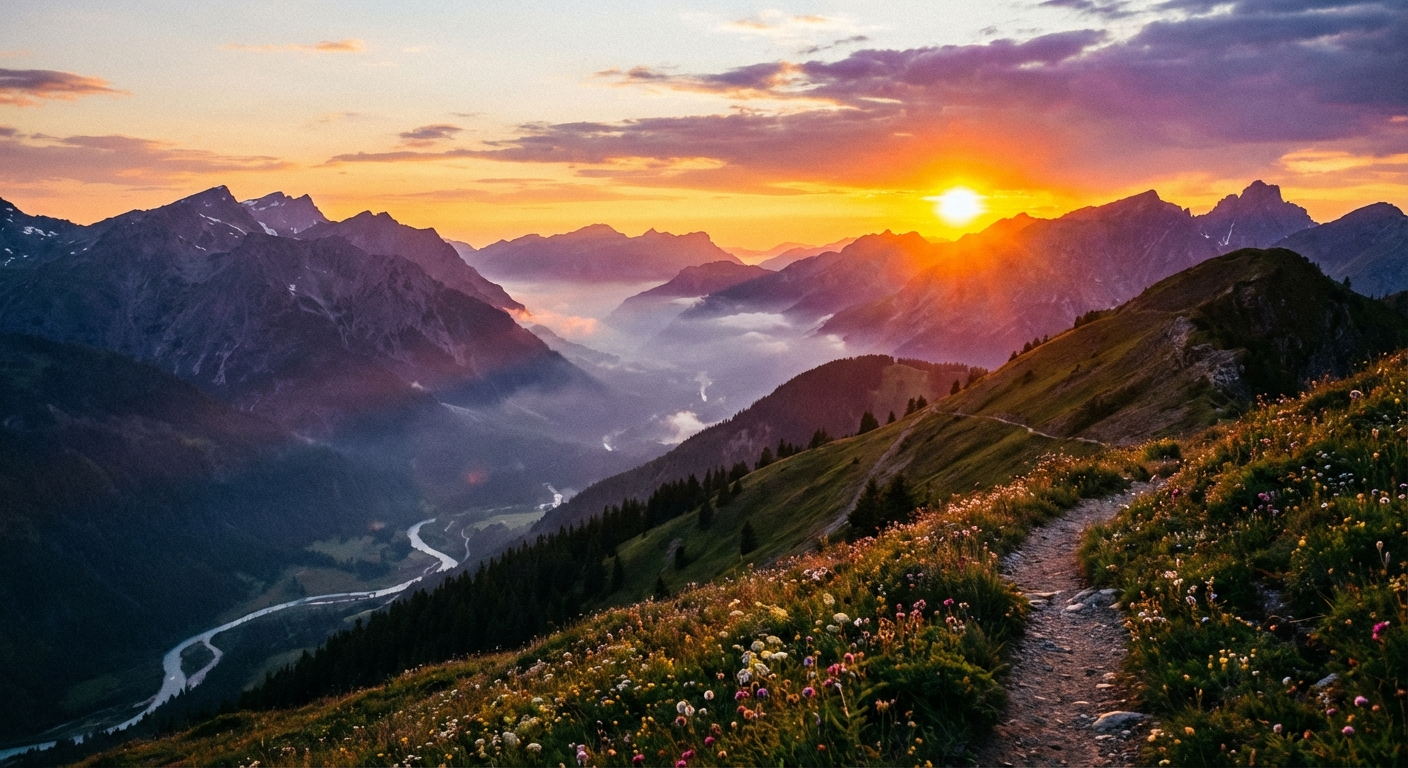

In [42]:
from IPython.display import Image, display

display(Image(url=image_url))

&emsp;&emsp;我们将 `model` 参数设为了 `google/gemini-3-pro-image-preview`，也就是 `Google Gemini 3 Pro` 的图像模型。
在 `messages` 中，我们给模型一个用户指令，描述希望生成的图像场景。由于图像模型的回复是图片数据，所以 `response.choices[0].message.content` 将包含图像的编码数据（通常为 `Base64` 字符串）。我们将其提取到 `image_base64` 变量中。

&emsp;&emsp;如何使用返回的图片？ 我们可以将得到的 `Base64` 字符串转换为图片文件保存下来，或在前端页面将其显示为图片。具体而言，在`Python`中可以用 `base64` 库解码字符串并保存为 `.png` 文件。在网页端则可直接将 `Base64` 数据前缀为 `data:image/png;base64`, 后用于展示。通过 `OpenRouter` 这个统一接口，我们成功地让 `Google` 的 `Gemini` 模型根据中文描述生成了图像。这对于需要多模态内容生成的应用来说非常方便强大！

&emsp;&emsp;国内在多模态领域（Multimodal）已经形成了“视觉理解（让 AI 看懂）”与“视觉生成（让 AI 绘画）”两大核心流派。比如目前Qwen-VL (阿里通义)的多模态模型、GLM-4V & CogView (智谱 AI)的模型、以及我们今天介绍的 Gemini 3 Pro等模型，都是属于“视觉生成”这一流派。


#### 4.3.4 多模态应用场景

&emsp;&emsp;多模态能力开辟了许多新的应用场景：

- **电商**：上传商品图片，AI 自动生成商品描述、提取卖点

- **教育**：拍摄数学题照片，AI 解题并给出步骤

- **医疗**：分析医学影像，辅助诊断（需专业模型）

- **内容审核**：检测图片中的违规内容

- **辅助工具**：帮助视障人士"看"图片，描述场景

- **代码理解**：分析 UI 截图，生成对应的 HTML/CSS 代码

&emsp;&emsp;掌握多模态输入后，你的 AI 应用将从"只能聊天"进化到"能看会说"，大大拓展了应用边界。

### 4.4 提示词工程：写出高质量 Prompt

&emsp;&emsp;同样的问题，不同的提示词（Prompt）会得到截然不同的回答质量。<font color=red>提示词工程（Prompt Engineering）是一门让 AI 更准确理解你意图的艺术</font>。这里分享四个实用技巧。

&emsp;&emsp;**技巧1：明确角色与行为规范**

&emsp;&emsp;System Prompt（系统提示词）中的"角色与行为规范"是提升大模型输出质量的核心技巧之一。它的核心逻辑是：通过明确告诉模型"你是谁"以及"你应该怎么做"，来约束和引导模型的行为。

&emsp;&emsp;具体来说，我们可以在 System Prompt 中定义模型的身份（比如"你是一位资深的 Python 技术导师"）、输出风格（比如"解释简洁易懂，避免术语堆砌"）、以及具体的行为规范（比如"必须提供可运行的代码示例"）。这些规则会在整个对话过程中持续生效，成为模型回答的"行为准则"。

&emsp;&emsp;为什么这个技巧有效？因为大模型本质上是一个"角色扮演者"，它会根据你赋予的角色来调整语气、专业度和回答深度。如果你不定义角色，模型就会用默认的通用风格回答，可能过于笼统或不符合预期。而一旦你明确了角色，模型就会"入戏"，输出更加专业、风格一致的内容。

好的角色定义通常包含三个要素：身份定位、专业领域、以及输出约束。这三者缺一不可，共同构成了一个清晰的"人设"。

In [ ]:
import os
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv(override=True)

client = OpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

# ❌ 糟糕的提示词
bad_prompt = {"role": "user", "content": "解释一下装饰器"}

# ✅ 优秀的提示词（明确角色）
good_system = """你是一个专业的Python技术导师。
特点：
- 解释简洁易懂，避免术语堆砌
- 提供可运行的代码示例
- 指出常见错误和注意事项
- 语气友好，鼓励学习"""

good_prompt = {"role": "user", "content": "请解释Python装饰器的原理"}

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "system", "content": good_system},
        good_prompt
    ]
)

print(response.choices[0].message.content)

装饰器是Python中一个强大且优雅的特性，它允许你在不修改原函数代码的情况下，动态地扩展函数的功能。

## 核心原理

装饰器本质上是一个**高阶函数**，它：
1. 接受一个函数作为参数
2. 返回一个新的函数
3. 在新函数中调用原函数，并添加额外功能

## 简单示例

```python
# 1. 基础装饰器
def my_decorator(func):
    def wrapper():
        print("函数执行前...")
        func()  # 调用原函数
        print("函数执行后...")
    return wrapper

@my_decorator
def say_hello():
    print("Hello!")

say_hello()
# 输出：
# 函数执行前...
# Hello!
# 函数执行后...
```

## 语法糖解析

`@my_decorator` 实际上等价于：
```python
def say_hello():
    print("Hello!")

say_hello = my_decorator(say_hello)  # 手动装饰
```

## 带参数的函数

```python
def timer_decorator(func):
    import time
    
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)  # 执行原函数
        end = time.time()
        print(f"函数 {func.__name__} 执行耗时: {end-start:.2f}秒")
        return result  # 返回原函数的结果
    return wrapper

@timer_decorator
def calculate_sum(n):
    return sum(range(n))

print(calculate_sum(1000000))
```

## 保留原函数信息

```python
from functools import

&emsp;&emsp;**技巧2：要求格式化输出**

&emsp;&emsp;格式化输出是让大模型返回结构化数据的核心技巧。它的核心逻辑是：通过在 System Prompt 中明确指定输出格式（如 JSON、Markdown 表格等），让模型的回答变得可预测、可解析。

&emsp;&emsp;为什么需要格式化输出？因为大模型默认会生成自然语言文本，虽然读起来流畅，但很难被程序自动处理。想象一下，如果你让模型"分析这段代码的问题"，它可能会返回一大段散文式的描述。但如果你要求它返回 JSON 格式，包含 error_type、location、suggestion 等字段，你的程序就能直接解析并执行后续操作。

&emsp;&emsp;实现格式化输出的关键在于两点：第一是提供清晰的格式模板，让模型知道期望的结构；第二是给出一个具体的输出示例，这比纯文字描述更能让模型"理解"你的意图。

&emsp;&emsp;常见的格式包括 JSON（最适合程序解析）、Markdown（适合文档生成）、以及自定义分隔符格式（适合简单场景）。选择哪种格式取决于你的下游需求：如果要接入自动化流程，优先选 JSON；如果是给人看的报告，Markdown 更合适。

In [ ]:
# 要求JSON格式输出
system_prompt = """请以JSON格式返回结果，严格遵循以下格式：
{
    "summary": "核心要点（一句话）",
    "steps": ["步骤1", "步骤2", "步骤3"],
    "code_example": "代码示例",
    "common_mistakes": ["常见错误1", "常见错误2"]
}"""

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": "如何使用Python读取CSV文件？"}
    ],
    temperature=0  # 确定性输出
)

print(response.choices[0].message.content)

```json
{
    "summary": "使用Python内置的csv模块或pandas库可以高效读取CSV文件。",
    "steps": ["导入csv模块或pandas库", "使用open()函数打开CSV文件", "通过csv.reader()读取数据或使用pandas.read_csv()", "遍历数据或直接处理DataFrame"],
    "code_example": "import csv\nwith open('data.csv', 'r', encoding='utf-8') as file:\n    reader = csv.reader(file)\n    for row in reader:\n        print(row)\n\n# 使用pandas\nimport pandas as pd\ndata = pd.read_csv('data.csv')\nprint(data.head())",
    "common_mistakes": ["未指定文件编码导致乱码", "忘记关闭文件（推荐使用with语句）", "路径错误或文件不存在", "未处理CSV中的特殊字符或分隔符"]
}
```


&emsp;&emsp;**技巧3：少样本学习（Few-Shot Learning）**

&emsp;&emsp;Few-Shot Learning（少样本学习）是一种通过在提示中嵌入少量示例，让大模型"临时学会"特定任务的技术。它的核心逻辑可以用"先示范、再提问"来概括。

&emsp;&emsp;具体来说，我们不是直接把问题抛给模型，而是先在对话历史中构造几组"用户提问 → 助手回答"的示例对话。这些示例就像是给模型看的"参考答案"，模型会从中推断出输入和输出之间的映射规则——比如输入是一段文本，输出应该是"正面"或"负面"这样的固定格式。

&emsp;&emsp;当模型看到最后一个真正需要回答的新问题时，它会模仿前面示例的模式来生成答案。这就是"少样本"的精髓：我们不需要对模型进行任何微调或额外训练，只需要在提示词中提供几个高质量的示例，就能让模型按照期望的格式和风格输出。

&emsp;&emsp;示例的数量通常在 2-5 个之间，太少可能让模型"学不会"，太多则会消耗过多 Token 并增加成本。选择具有代表性、边界清晰的示例，是 Few-Shot 成功的关键。

* Few-Shot 的核心逻辑

| 角色                                | 作用                                                         |
| :---------------------------------- | :----------------------------------------------------------- |
| `system`                            | 定义任务，告诉模型"你要做什么"                               |
| `user` + `assistant` 对（重复多次） | **这就是 few-shot 的关键**——通过示例让模型"学习"输入输出的映射关系 |
| 最后一个 `user`                     | 真正需要模型回答的新问题                                     |

In [76]:
import os
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv(override=True)

client = OpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

# ============ Few-Shot Learning 示例 ============
# 任务：情感分类（正面/负面/中性）

messages = [
    # 系统角色定义任务
    {"role": "system", "content": "你是一个情感分析助手。请根据用户输入的文本，判断情感倾向，只输出：正面、负面 或 中性。"},
    
    # ========== Few-Shot 示例开始 ==========
    # 示例 1：正面
    {"role": "user", "content": "这家餐厅的服务太棒了，菜品也很美味！"},
    {"role": "assistant", "content": "正面"},
    
    # 示例 2：负面
    {"role": "user", "content": "等了一个小时外卖还没到，客服态度也很差。"},
    {"role": "assistant", "content": "负面"},
    
    # 示例 3：中性
    {"role": "user", "content": "今天天气一般，不冷也不热。"},
    {"role": "assistant", "content": "中性"},
    # ========== Few-Shot 示例结束 ==========
    
    # 真正需要模型处理的新问题
    {"role": "user", "content": "这个产品质量不错，但是价格有点贵。"}
]

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=messages,
    temperature=0  # 降低随机性，让分类更稳定
)

print("情感分析结果：", response.choices[0].message.content)

情感分析结果： 中性


&emsp;&emsp;**技巧4：链式思考（Chain of Thought）**

&emsp;&emsp;链式思考（Chain of Thought，简称 CoT）是一种让大模型"逐步推理"的提示技术。它的核心逻辑是：通过要求模型先展示思考过程，再给出最终答案，从而提升复杂问题的回答准确率。

&emsp;&emsp;为什么需要链式思考？因为大模型在处理复杂问题时，如果直接跳跃到答案，容易出错。比如一道数学应用题，模型可能会"想当然"地给出一个错误结果。但如果你要求它"一步一步分析"，它就会被迫展开中间推理过程，每一步都基于前一步的结论，最终答案的准确性会大幅提升。

&emsp;&emsp;实现链式思考有两种方式：第一种是在提示词中直接加上"请一步一步思考"或"Let's think step by step"这样的指令；第二种是通过 Few-Shot 示例，给模型展示几个带有详细推理过程的样例，让它学会这种输出风格。

&emsp;&emsp;链式思考特别适合解决需要多步推理的问题，比如数学计算、逻辑推断、代码调试等。但对于简单问答类任务，使用 CoT 可能会增加不必要的 Token 消耗，因此需要根据具体场景权衡使用。

In [ ]:
# 让AI展示推理过程
prompt = """请一步步分析以下问题：
问题：一个班级有30名学生，其中60%是女生。如果再加入5名男生，女生占比是多少？

请按以下格式作答：
1. 理解题意：...
2. 计算原始数据：...
3. 计算新数据：...
4. 得出结论：...
"""

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[{"role": "user", "content": prompt}],
    temperature=0
)

print(response.choices[0].message.content)

1. 理解题意：  
   题目给出一个班级原有 30 名学生，其中 60% 是女生，即女生人数占班级总人数的 60%。然后加入 5 名男生，此时班级总人数增加，女生人数不变，需要求新的女生占比。

2. 计算原始数据：  
   原有学生总数：30 人  
   女生比例：60%  
   女生人数 = \( 30 \times 60\% = 30 \times 0.6 = 18 \) 人  
   男生人数 = \( 30 - 18 = 12 \) 人  

3. 计算新数据：  
   加入 5 名男生后：  
   新男生人数 = \( 12 + 5 = 17 \) 人  
   女生人数不变：18 人  
   新总人数 = \( 30 + 5 = 35 \) 人  
   女生占比 = \( \frac{18}{35} \approx 0.5142857 \)  

4. 得出结论：  
   加入 5 名男生后，女生占比约为 \( 51.43\% \)（保留两位小数）。


* **最佳实践总结**：

    * system 消息定义角色和行为规范

    * 明确要求输出格式（JSON/Markdown/表格）

    * 使用 Few-Shot 示例帮助 AI 理解模式
    
    * 对于复杂任务，要求展示推理过程

&emsp;&emsp;链式思考特别适合以下场景：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>链式思考适用场景</font></p>
<div class="center">

| 任务类型 | 示例 | CoT 提示词 |
|---------|------|-----------|
| **数学推理** | 应用题、代数题 | "请列出每一步计算过程" |
| **逻辑推理** | 脑筋急转弯、侦探题 | "请逐步分析每个线索" |
| **代码调试** | 找出 bug 原因 | "请逐行分析代码逻辑" |
| **决策分析** | 多方案对比 | "请列出各方案的优缺点" |
| **文本分析** | 长文摘要、观点提取 | "请先总结段落大意，再提炼观点" |

</div>



> &emsp;**进阶技巧**：可以在 Few-Shot 示例中同时展示"问题 + 逐步推理 + 答案"的完整流程，让 AI 学会这种思维模式。

### 4.5 异步批处理：并发提升效率

&emsp;&emsp;如果需要同时处理多个问题（如批量翻译、批量摘要），同步逐个调用会非常慢。<font color=red>使用 AsyncOpenAI 客户端配合 asyncio，可以并发执行多个请求</font>，大幅提升吞吐量。

In [ ]:
import os
import time
import asyncio
from openai import OpenAI, AsyncOpenAI
from dotenv import load_dotenv

load_dotenv(override=True)

# 同步客户端
sync_client = OpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

# 异步客户端
async_client = AsyncOpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

# 测试问题列表
questions = [
    "什么是Python？",
    "什么是JavaScript？",
    "什么是Go语言？",
    "什么是Rust？",
    "什么是TypeScript？"
]

# 方法1：同步调用（逐个执行）
def sync_batch():
    print("=" * 60)
    print("同步调用（逐个执行）")
    print("=" * 60)
    
    start_time = time.time()
    results = []
    
    for question in questions:
        response = sync_client.chat.completions.create(
            model="deepseek-chat",
            messages=[{"role": "user", "content": question}],
            max_tokens=50
        )
        results.append(response.choices[0].message.content)
    
    elapsed = time.time() - start_time
    print(f"完成 {len(questions)} 个请求")
    print(f"耗时：{elapsed:.2f} 秒\n")
    
    return results, elapsed

# 方法2：异步并发调用
async def ask_question_async(question):
    """异步调用单个问题"""
    response = await async_client.chat.completions.create(
        model="deepseek-chat",
        messages=[{"role": "user", "content": question}],
        max_tokens=50
    )
    return response.choices[0].message.content

async def async_batch():
    print("=" * 60)
    print("异步并发调用")
    print("=" * 60)
    
    start_time = time.time()
    
    # 使用 asyncio.gather 并发执行所有请求
    results = await asyncio.gather(*[ask_question_async(q) for q in questions])
    
    elapsed = time.time() - start_time
    print(f"完成 {len(questions)} 个请求")
    print(f"耗时：{elapsed:.2f} 秒\n")
    
    return results, elapsed

# 性能对比
print("开始性能测试...\n")

# 同步测试
sync_results, sync_time = sync_batch()

# 异步测试,Jupyter 专用
async_results, async_time = await async_batch()

# 普通python环境使用
# asyncio.run(async_batch())

# 性能提升
improvement = (sync_time - async_time) / sync_time * 100

print("=" * 60)
print("性能对比")
print("=" * 60)
print(f"同步调用耗时：{sync_time:.2f} 秒")
print(f"异步调用耗时：{async_time:.2f} 秒")
print(f"性能提升：{improvement:.1f}%")
print(f"\n异步调用使耗时减少了 {sync_time - async_time:.2f} 秒！")

开始性能测试...

同步调用（逐个执行）
完成 5 个请求
耗时：10.52 秒

异步并发调用
完成 5 个请求
耗时：2.30 秒

性能对比
同步调用耗时：10.52 秒
异步调用耗时：2.30 秒
性能提升：78.1%

异步调用使耗时减少了 8.22 秒！


* 在典型网络环境下，5个请求的异步调用可以比同步快 **60-80%**。这是因为：

    *  同步调用：请求1 → 等待 → 请求2 → 等待 → ...（串行）

    * 异步调用：请求1、2、3、4、5 同时发出 → 等待所有响应（并行）



**适用场景**：
* 批量翻译、批量摘要、批量分类

    * 多文档并发处理

    * Web应用中的高并发请求

* **注意事项**：

    * 仍需遵守速率限制（Rate Limit），不要无限并发
    
    * 建议配合信号量（`asyncio.Semaphore`）控制并发数

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>同步 vs 异步性能对比</font></p>
<div class="center">

| 对比维度 | 同步执行 | 异步执行 |
|---------|---------|---------|
| **总耗时** | N × 单次耗时 | ≈ 单次耗时 |
| **资源占用** | 低（单线程阻塞） | 中（事件循环） |
| **代码复杂度** | 低（易理解） | 中（需理解 async/await） |
| **适用场景** | 少量任务、顺序依赖 | 大量独立任务 |
| **风险** | 耗时长 | 可能触发速率限制 |

</div>

&emsp;&emsp;通过掌握异步批处理，你的 AI 应用将能够高效处理大规模任务，从"一个一个慢慢来"进化到"批量并发快速完成"。

&emsp;**最佳实践**：对于 100 个以上的大批量任务，建议分批执行（如每批 20 个），避免内存占用过高和网络不稳定的影响。

> &emsp;**重要提示**：虽然我们在本节演示了 Chat Completions API，但 OpenAI 在 2025年还推出了新的 Responses API，提供更多专属功能。不过<font color=red>对于跨平台开发，优先掌握通用的 Chat Completions API</font>，这样你的代码才能在所有模型间自由迁移。

### 4.6 Responses API

Responses API 是 OpenAI 2025年推出的新一代 agentic API，
* 主要差异点：

    1. 服务端状态管理 - 通过 previous_response_id 自动维护对话历史

    2. 内置工具支持 - Web搜索、文件搜索、计算机操作等

    3. 事件驱动架构 - 更可预测的流式响应

    4. 简化的 agentic 工作流 - 专为 AI Agent 设计

In [2]:
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv(override=True)

# 初始化客户端
client = OpenAI()  # 确保设置了 OPENAI_API_KEY 环境变量

# ============================================================
# 示例1: Chat Completions API (传统方式)
# 需要手动维护和传递完整的对话历史
# ============================================================
print("=" * 60)
print("【Chat Completions API - 传统方式】")
print("=" * 60)

# 第一轮对话
messages = [{"role": "user", "content": "我叫小明，请记住我的名字"}]
response1 = client.chat.completions.create(
    model="gpt-5-nano",
    messages=messages
)
print(f"用户: {messages[0]['content']}")
print(f"助手: {response1.choices[0].message.content}\n")

# 第二轮对话 - 必须手动维护历史
messages.append({"role": "assistant", "content": response1.choices[0].message.content})
messages.append({"role": "user", "content": "你还记得我叫什么名字吗？"})

response2 = client.chat.completions.create(
    model="gpt-5-nano",
    messages=messages  # 必须传入完整历史
)
print(f"用户: {messages[-1]['content']}")
print(f"助手: {response2.choices[0].message.content}")
print(f"\n⚠️  需手动管理的消息数: {len(messages)}")

【Chat Completions API - 传统方式】
用户: 我叫小明，请记住我的名字
助手: 好的，小明。我会在本次对话中记住你的名字。请告诉我你希望我怎么称呼你，或者还有其他偏好。

用户: 你还记得我叫什么名字吗？
助手: 当然记得，小明。现在就记住这个名字。如果你愿意，也可以告诉我你希望我怎么称呼你，或者还有其他偏好。

⚠️  需手动管理的消息数: 3


In [3]:
# ============================================================
# 示例2: Responses API (新方式)
# 服务端自动管理对话状态，通过 previous_response_id 引用
# ============================================================
print("\n" + "=" * 60)
print("【Responses API - 新方式】")
print("=" * 60)

# 第一轮对话 - 开启服务端存储
response1 = client.responses.create(
    model="gpt-5-nano",
    input="我叫小红，请记住我的名字",
    store=True  # 🔑 关键: 启用服务端状态存储
)
print(f"用户: 我叫小红，请记住我的名字")
print(f"助手: {response1.output_text}")
print(f"📦 Response ID: {response1.id}")  # 用于后续引用

# 第二轮对话 - 使用 previous_response_id 自动关联上下文
response2 = client.responses.create(
    model="gpt-5-nano",
    input="你还记得我叫什么名字吗？",
    previous_response_id=response1.id,  # 🔑 关键: 引用之前的响应
    store=True
)
print(f"\n用户: 你还记得我叫什么名字吗？")
print(f"助手: {response2.output_text}")
print(f"\n✅ 无需手动管理消息历史，服务端自动维护!")


【Responses API - 新方式】
用户: 我叫小红，请记住我的名字
助手: 好的，小红。我会在本次对话中记住你的名字，并在这次聊天里称呼你为小红。如果你结束对话或开启新会话，记忆可能不会自动保留，届时你可以再告诉我你的名字。有什么其他需要我记住的偏好吗？
📦 Response ID: resp_045be541d107f8f00069797637d92c81a287e7ee93daab8b62

用户: 你还记得我叫什么名字吗？
助手: 当然，你的名字是小红。这仅限于本次对话，结束后可能不会保留。如果你愿意，我会在本次对话里继续称呼你为小红。还有其他你想让我记住的偏好吗？

✅ 无需手动管理消息历史，服务端自动维护!


In [4]:
# ============================================================
# 示例3: Responses API 内置工具 (Web Search)
# Chat Completions API 不支持此功能
# ============================================================
print("\n" + "=" * 60)
print("【Responses API - 内置 Web Search 工具】")
print("=" * 60)

response_search = client.responses.create(
    model="gpt-5-nano",
    input="今天的比特币价格是多少？",
    tools=[{"type": "web_search_preview"}]  # 🔑 内置工具
)
print(f"用户: 今天的比特币价格是多少？")
print(f"助手: {response_search.output_text}")
print(f"\n🔍 Chat Completions API 需要手动实现搜索功能，")
print(f"   Responses API 直接内置 web_search_preview 工具!")


【Responses API - 内置 Web Search 工具】
用户: 今天的比特币价格是多少？
助手: 截至今天（2026-01-28），比特币对美元的实时价格约为 89,077 美元。日内交易区间大致在 87,271 美元 至 89,394 美元之间，波动约 2,123 美元。请注意，币价会持续快速波动，以上数据仅为当前行情的近似值。需要的话，我可以继续实时刷新价格或给你设定价格提醒。 ([coinmarketcap.com](https://coinmarketcap.com/currencies/bitcoin/?utm_source=openai))

🔍 Chat Completions API 需要手动实现搜索功能，
   Responses API 直接内置 web_search_preview 工具!


#### Responses API vs Chat Completions API 核心差异
<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>同步 vs 异步性能对比</font></p>
<div class="center">

| 特性         | Chat Completions API         | Responses API                               |
| :----------- | :--------------------------- | :------------------------------------------ |
| **状态管理** | 客户端手动维护 messages      | 服务端自动管理，使用 `previous_response_id` |
| **对话历史** | 每次请求需传完整历史         | 只需引用响应 ID                             |
| **内置工具** | ❌ 需手动实现                 | ✅ Web Search, File Search, Computer Use     |
| **请求结构** | `messages` 数组              | `input` 字符串                              |
| **响应获取** | `choices[0].message.content` | `output_text`                               |
| **适用场景** | 简单问答                     | Agentic 复杂工作流                          |

<div>



#### 代码中的三个关键演示：

1. **Chat Completions** - 需手动维护 messages数组

2. **Responses API** - 使用  store=True  +  previous_response_id自动关联上下文

3. **内置工具** - 直接使用  tools=[{"type": "web_search_preview"}] 进行网络搜索

## <center>5、综合实战 - LLM Playground 项目展示</center>

&emsp;&emsp;在过去的学习中，我们掌握了 `Token`、`API-Key`、`SDK` 等核心概念，了解了 `OpenRouter`、`DeepSeek`、阿里百炼、智谱 AI 等多个平台的接入方法，也学习了流式响应、多模态输入等高级功能。但这些知识如果仅停留在零散的代码片段上，很难转化为真正的工程能力。<font color=red>这一章我们要做的，就是把这些知识点串联起来，构建一个类似 OpenAI Playground 的实用工具</font>。

&emsp;&emsp;结合当前的学习需求，我们会重点解决三个问题：如何将多平台 API 调用整合到统一的界面中、如何实现流畅的用户交互体验、如何为后续的 Agent 开发课程做好技术铺垫。通过这个项目，我们不仅能巩固已学知识，还能建立起前后端协作、模块化设计等工程思维。更重要的是，<font color=red>这个 LLM Playground 是一个可以直接使用的工具</font>——你可以用它快速测试不同模型的效果、对比参数调整的影响、进行多模态实验，甚至作为自己项目的起点进行二次开发。

&emsp;&emsp;为了把这些内容讲清楚，接下来我们会按照"项目概览 → 界面设计 → 核心功能演示 → 技术实现要点 → 扩展方向"的主线展开。这个顺序是经过设计的：先从宏观上了解项目的定位和价值，再深入到界面交互细节，然后通过功能演示体会实际效果，最后揭示背后的技术原理和扩展可能性。这样的安排既符合认知规律，也能让我们在动手实践前建立起完整的技术全景图。

### 5.1 项目概览与价值定位

&emsp;&emsp;在进入具体功能介绍之前，我们需要先回答几个基本问题：什么是 `LLM Playground`？为什么要构建这样一个工具？它与市面上已有的产品有什么区别？通过这些问题的解答，我们可以明确项目的定位和学习价值，为后续的深入学习打下基础。

### 5.2 什么是 LLM Playground

&emsp;&emsp;`LLM Playground` 本质上是一个**大模型调用的可视化界面**。如果说前四章我们学习的是"用代码调用 API"，那么这一章就是"用图形界面调用 API"。它的核心功能是：<font color=red>让任何人都能通过点击和输入，而不是编写代码，来体验和测试各种大模型</font>。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123140533472.png" width=85%></div>

&emsp;&emsp;你可以把它理解为大模型的"万能遥控器"。就像电视遥控器让我们无需了解电路原理就能换台、调音量一样，`LLM Playground` 让我们无需每次都写代码就能切换模型、调整参数、查看结果。在这个界面中，你可以：

- 从右边筛选框中选择 `OpenAI`、`Qwen`、`DeepSeek` 等任意厂商与对应的模型

- 通过滑块实时调整 `Temperature`、`思考等级` 等参数

- 在输入框中输入文本或上传图片，立即看到模型的响应

- 查看完整的对话历史，随时回溯之前的问答

- 对比不同模型在相同输入下的表现差异

&emsp;&emsp;这种可视化界面的价值在于<font color=red>降低了使用门槛、提升了实验效率、增强了可理解性</font>。产品经理可以用它快速验证想法、设计师可以用它测试文案生成、开发者可以用它对比模型性能——所有这些场景都不需要写一行代码。

### 5.3 为什么需要这样的工具

&emsp;&emsp;你可能会问：`OpenAI` 官方不是已经有 Playground 了吗？为什么还要自己做一个？<font color=red>核心原因有三个：突破访问限制、实现多平台整合、掌握技术主动权</font>。

&emsp;&emsp;**第一，突破访问限制**。正如第一章提到的，`OpenAI`、`Anthropic` 等平台对中国大陆用户有封锁。即使通过技术手段访问了官方 Playground，也面临支付障碍、速率限制等问题。而我们自己构建的 Playground 可以接入 `OpenRouter`、`DeepSeek`、阿里百炼等国内可用的平台，<font color=red>彻底解决"用不了"的问题</font>。

&emsp;&emsp;**第二，实现多平台整合**。市面上的 Playground 通常只支持自家平台的模型——OpenAI Playground 只能用 GPT、Claude.ai 只能用 Claude。但实际场景中，我们经常需要对比不同模型的效果。我们的 Playground 通过统一的接口封装，<font color=red>可以在一个界面中无缝切换所有平台的模型</font>，这是任何单一厂商做不到的。

&emsp;&emsp;**第三，掌握技术主动权**。使用官方工具意味着受限于它的功能边界——你不能定制界面、不能添加新功能、不能集成到自己的系统中。而自己构建的 Playground 是完全开源和可控的，你可以根据需求任意扩展。比如，添加成本监控、批量处理、自定义提示词模板等功能，甚至将它嵌入到企业内部系统中。

&emsp;&emsp;从学习的角度看，这个项目还有一个隐藏价值：<font color=red>它是前端、后端、API 集成的完整练习场</font>。通过这个项目，我们可以理解前后端分离架构、状态管理、流式数据处理等工程概念，这些都是成为合格开发者的必备技能。

### 5.4 技术架构简介

&emsp;&emsp;在深入功能细节之前，我们先从宏观层面了解这个项目的技术架构。<font color=red>我们的 LLM Playground 采用前后端分离的架构</font>，这是目前 Web 应用的主流设计模式。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123142003301.png" width=60%></div>

&emsp;&emsp;**前端部分**使用 `React` + `TypeScript` + `Shadcn UI` 技术栈。`React` 负责构建用户界面和管理交互逻辑，`TypeScript` 提供类型安全保障，`Shadcn UI` 提供美观且一致的 UI 组件。前端的职责是：渲染界面、接收用户输入、展示模型响应、管理本地状态（如对话历史、参数配置）。

&emsp;&emsp;**后端部分**使用 `FastAPI` + `OpenAI SDK`。`FastAPI` 是一个高性能的 Python Web 框架，特别擅长处理异步请求和流式响应。后端的职责是：接收前端请求、调用各平台的大模型 API、处理响应数据、返回结果给前端。关键的是，<font color=red>后端通过统一的接口封装，让前端无需关心底层是调用 OpenRouter 还是 DeepSeek，只需传入模型名称即可</font>。

&emsp;&emsp;**通信方式**使用 `RESTful API` + `SSE`（Server-Sent Events）。常规的请求-响应使用 RESTful API，而流式响应（如打字机效果）则使用 SSE 技术。这种组合既保证了接口的简洁性，又实现了实时数据推送。

&emsp;&emsp;关于技术选型，你可能会问：为什么用 `FastAPI` 而不是 `Flask`？为什么用 `React` 而不是 `Vue`？这些问题我们会在第6章的 FAQ 中详细讨论。现在只需要知道：<font color=red>这套技术栈的核心优势是开发效率高、性能好、社区活跃、易于扩展</font>。

### 5.5 界面布局与交互设计

&emsp;&emsp;在了解了项目的定位和架构后，现在我们深入到用户实际看到和操作的界面层面。一个优秀的界面设计不仅要美观，更重要的是要符合用户的认知习惯、提升操作效率。我们的 Playground 采用经典的**三栏式布局**，这种设计在 IDE（如 VSCode）、聊天应用（如 Discord）中被广泛采用，已经被证明非常适合复杂交互场景。

**三栏式布局设计理念**

&emsp;&emsp;打开我们的 `LLM Playground`，你会看到界面被清晰地划分为三个区域：<font color=red>左侧边栏、中间主区域、右侧控制面板</font>。这种设计遵循了"功能分离、视觉聚焦"的原则。

&emsp;&emsp;**左侧边栏**负责"历史管理"——显示所有对话会话的列表，类似聊天软件的会话列表。你可以在这里创建新对话、切换历史对话、搜索特定会话。这个区域通常是固定宽度的，占据屏幕左侧约 20-25% 的空间。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123140533185.png
" width=30%></div>

&emsp;&emsp;**中间主区域**是"内容展示与交互核心"——这里显示当前对话的所有消息，包括你的输入和 AI 的回复。底部是输入框，用于编写新的提示词或上传图片。这个区域占据最大比例（约 50-60%），因为它是用户的主要注意力焦点。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123140533179.png" width=50%></div>

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123140533180.png" width=50%></div>

&emsp;&emsp;**右侧控制面板**负责"参数配置"——在这里选择模型、调整 Temperature、设置 System Message 等。这个区域类似于软件的"设置面板"，占据约 20-25% 的空间。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123140533181.png" width=30%></div>

&emsp;&emsp;这种布局的优势在于：<font color=red>功能清晰、操作高效、信息密度合理</font>。用户的视线可以自然地从左（选择对话）→ 中（查看内容）→ 右（调整参数），形成流畅的操作流。而且三个区域可以独立滚动，互不干扰——比如你可以在右侧调整参数的同时，中间区域仍然显示着对话内容。

### 5.6 多平台模型切换演示

&emsp;&emsp;这个功能展示了 Playground 最核心的价值：<font color=red>在一个界面中无缝切换不同平台的模型</font>。回顾第一章关于"OpenAI SDK 兼容格式"的内容，我们了解到大部分平台都支持统一的调用接口，现在我们来看看这个设计在实际应用中的威力。

&emsp;&emsp;**操作演示**：

1. 在右侧控制面板的模型选择器中，先选择 `第三方平台 → openai/gpt-5`

2. 在输入框中输入："用一句话解释什么是机器学习"，点击发送

3. 等待 gpt-5 的回复完成后，再次点击模型选择器，切换到 `DeepSeek`

4. 点击输入框上方的"重新生成"按钮（使用相同的输入，但用新模型）

5. 继续切换到 `Qwen（通义千问） → qwen-max`，再次重新生成

6. 最后切换到 `智谱 AI → glm-4`，完成四个模型的对比

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260123140533186.png" width=55%></div>

&emsp;&emsp;**结果分析**：

你会发现，四个模型对同一个问题给出了不同风格的回答：

- **gpt-5** 的回答通常更简洁、更学术化

- **DeepSeek** 的回答可能会包含更多技术细节

- **Qwen-Max** 的回答倾向于通俗易懂的表达

- **GLM-4** 的回答可能更注重结构化

&emsp;&emsp;这种差异正是我们需要 Playground 的原因——<font color=red>不同模型有不同的训练数据和优化目标，适合不同的应用场景</font>。通过快速对比，我们可以为具体任务选择最合适的模型。

&emsp;&emsp;从技术角度看，这个功能的实现依赖于第二章介绍的"统一接口封装"。后端代码维护了一个配置字典，记录每个模型的 `base_url` 和 `api_key`：

```python
    # 简化的配置示例（实际代码在后端）
    PLATFORM_CONFIGS = {
        "openai/gpt-5.2": {
            "base_url": "https://openrouter.ai/api/v1",
            "api_key": os.getenv("OPENROUTER_API_KEY")
        },
        "deepseek-chat": {
            "base_url": "https://api.deepseek.com",
            "api_key": os.getenv("DEEPSEEK_API_KEY")
        },
        # ... 其他模型配置
    }
```

&emsp;&emsp;当用户在前端切换模型时，前端只需把新的模型名称传给后端，后端自动查找对应的配置并调用相应的 API。<font color=red>这就是为什么所有平台都兼容 OpenAI 格式的好处——我们只需要改两个配置项，就能接入任何平台</font>。

## 6. 项目总结与反思

&emsp;&emsp;经过完整的项目展示，现在我们回到起点，系统性地回顾所学知识、总结项目价值、解答常见疑问、并规划后续学习路径。

&emsp;&emsp;这个 Playground 项目将前四章的所有核心知识点串联了起来。让我们通过一个映射表清晰地看到这种对应关系：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>前四章知识点在项目中的应用</font></p>
<div class="center">

| 章节知识点 | 在 Playground 中的应用 | 对应功能模块 |
|-----------|---------------------|------------|
| **第1章：Token** | 输入框实时显示 Token 计数，预估成本 | 输入组件 |
| **第1章：API-Key** | 后端环境变量管理，前端不可见 | 安全架构 |
| **第1章：OpenAI SDK 兼容** | 统一接口封装，动态切换 base_url | 多平台集成 |
| **第2章：OpenRouter** | 接入 GPT、Claude 等顶级模型 | 模型选择器 |
| **第2章：DeepSeek** | 接入高性价比的国产模型 | 模型选择器 |
| **第2章：阿里百炼** | 接入通义千问系列模型 | 模型选择器 |
| **第3章：流式响应** | 打字机效果，SSE 技术实现 | 消息展示区 |
| **第3章：多轮对话** | messages 列表管理，上下文窗口 | 对话历史 |
| **第3章：参数调整** | Temperature、Max Tokens 滑块 | 控制面板 |
| **第4章：多模态输入** | 图片上传、Base64 编码 | 输入组件 |
| **第4章：思考过程** | 推理链展示，可折叠面板 | 消息展示区 |

</div>

&emsp;&emsp;这个映射表清晰地展示了<font color=red>理论知识如何转化为实际功能</font>。每一个你在 Playground 中看到的按钮、滑块、输入框，背后都对应着我们在前面章节学到的某个技术点。

### 6.1 项目价值总结

&emsp;&emsp;回顾整个第五章的学习，这个 Playground 项目的价值体现在三个层面：

#### 1. **学习价值：知识整合与工程实践**

这不仅仅是"会调用 API"，而是<font color=red>理解如何将零散的技术点整合成一个完整系统</font>。我们学到了：

- 前后端分离的架构设计

- 状态管理的工程实践

- 用户体验优化的思路（如流式响应、实时反馈）

- 安全性的基础考量

#### 2. **实用价值：可直接使用的工具**

这个 Playground 不是玩具项目，而是可以直接投入使用的工具：

- 快速测试不同模型的效果，为项目选型提供依据

- 对比参数调整的影响，优化提示词策略

- 进行多模态实验，验证想法的可行性

- 作为团队的内部工具，降低非技术人员使用 AI 的门槛

#### 3. **扩展价值：为 Agent 开发铺路**

这个项目的架构设计已经考虑了未来的扩展需求：

- 预留了 Function Calling 的可视化接口

- 思考过程展示为 Agent 的推理链路追踪打下基础

- 模块化设计允许灵活添加新功能（如工具库、批量处理）

&emsp;&emsp;<font color=red>项目的最大价值在于"授人以渔"</font>——不仅给了你一个工具，更重要的是展示了构建这类工具的完整思路和方法。

## 附录：术语表

&emsp;&emsp;在学习大模型 API 调用的过程中，我们接触了许多专业术语。为了方便大家随时查阅和巩固理解，这里将本课程中涉及的核心术语整理成表格，按字母顺序排列。每个术语都包含中文名称、英文全称以及面向初学者的简洁定义，帮助大家建立清晰的概念体系。

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>大模型 API 核心术语对照表</font></p>
<div class="center">

| 术语 | 中文名称 | 定义 |
|------|---------|------|
| **API** (Application Programming Interface) | 应用程序编程接口 | 一组预定义的函数和协议，允许不同软件系统之间进行通信和数据交换。在大模型场景中，API 是我们调用模型能力的标准入口。 |
| **API Key** | API 密钥 | 用于身份验证的唯一字符串，证明调用者有权限访问 API 服务。它类似于"数字钥匙"，需要妥善保管，不能泄露给他人。 |
| **Base URL** | 基础地址 | API 服务的根网址，所有具体的 API 请求都会在这个地址基础上构建完整路径。例如 `https://api.openai.com/v1` 就是 OpenAI 的 Base URL。 |
| **Chat Completions** | 对话补全 | 大模型 API 中最核心的接口类型，用于实现多轮对话功能。它接收消息列表作为输入，返回模型生成的回复内容。 |
| **Function Calling** | 函数调用 | 大模型的一种高级能力，允许模型在对话过程中主动调用外部工具或函数，从而实现查询数据库、调用 API 等复杂操作。 |
| **JSON** (JavaScript Object Notation) | JSON 格式 | 一种轻量级的数据交换格式，使用键值对结构组织数据。API 请求和响应通常都采用 JSON 格式，因为它易于人类阅读，也便于程序解析。 |
| **LLM** (Large Language Model) | 大语言模型 | 基于深度学习技术训练的大规模神经网络模型，能够理解和生成自然语言文本。代表性产品包括 GPT-5、Claude、文心一言等。 |
| **Max Tokens** | 最大令牌数 | 限制模型单次生成内容的最大长度。这个参数既影响响应的完整性，也直接关系到 API 调用的成本和响应时间。 |
| **Messages** | 消息列表 | Chat Completions API 的核心输入参数，是一个包含多条消息的数组。每条消息都有 `role`（角色）和 `content`（内容）两个字段，用于构建完整的对话上下文。 |
| **Model** | 模型名称 | 指定要调用的具体模型版本，例如 `gpt-5`、`gpt-5-nano`。不同模型在能力、速度和成本上存在差异，需要根据实际场景选择。 |
| **Prompt** | 提示词 | 发送给大模型的输入文本，用于引导模型生成期望的输出。高质量的 Prompt 设计是获得理想结果的关键，这也是"提示工程"的核心内容。 |
| **Rate Limit** | 速率限制 | API 服务商对调用频率的限制，通常以"每分钟请求数"或"每天令牌数"来衡量。超过限制会导致请求被拒绝，需要合理控制调用频率。 |
| **SDK** (Software Development Kit) | 软件开发工具包 | 官方或第三方提供的代码库，封装了 API 调用的底层细节，提供更友好的编程接口。例如 `openai` Python 库就是 OpenAI 的官方 SDK。 |
| **Stream** | 流式输出 | 一种实时返回模型生成内容的方式，不需要等待全部内容生成完毕。用户可以逐字逐句看到模型的输出过程，显著提升交互体验。 |
| **System Message** | 系统消息 | 消息列表中 `role` 为 `system` 的特殊消息，用于设定模型的行为规则、角色定位或回答风格。它对整个对话的走向有全局性影响。 |
| **Temperature** | 温度参数 | 控制模型输出随机性的参数，取值范围通常是 0 到 2。值越低输出越确定和保守，值越高输出越多样和创造性。默认值一般为 1。 |
| **Token** | 令牌 | 大模型处理文本的基本单位，一个 Token 大约对应 0.75 个英文单词或 0.5 个中文字符。API 计费和长度限制都基于 Token 数量而非字符数。 |
| **Usage** | 用量统计 | API 响应中返回的统计信息，包含 `prompt_tokens`（输入令牌数）、`completion_tokens`（输出令牌数）和 `total_tokens`（总令牌数），用于成本核算和性能监控。 |

</div>

&emsp;&emsp;这些术语构成了大模型 API 调用的基础知识体系。在实际开发中，我们会反复使用这些概念，建议大家在遇到不熟悉的术语时随时回到这个表格进行查阅。随着学习的深入，这些术语会逐渐内化为我们的技术语言，成为与大模型高效交互的基础。